### Cell 1 — setup + load the validated tract-year panel for the new cluster-time workflow


In [174]:
# Cell 1 — setup + load the validated tract-year panel for the new cluster-time workflow

from pathlib import Path
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# -----------------------------
# Paths / core settings
# -----------------------------
DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "raw"
OUT_DIR = DATA_DIR / "processed"

LOW_IGS_THRESHOLD = 45
ANALYSIS_YEARS = list(range(2017, 2025))   # ACS-aligned years only
PRE_COVID_YEARS = [2017, 2018, 2019]
COVID_YEARS = [2020, 2021]
RECOVERY_YEARS = [2022, 2023, 2024]

ECON_VARS = [
    "igs_economy",
    "poverty_rate",
    "unemp_rate",
    "median_household_income",
    "lfpr_16p",
]

CLUSTER_CORE_VARS = [
    "igs_total",
    "igs_economy",
    "poverty_rate",
    "unemp_rate",
    "median_household_income",
    "lfpr_16p",
    "pop_total",
]

DISPLAY_COLS = [
    "display_state",
    "display_county",
    "display_name",
]

REQUIRED_COLS = [
    "geoid",
    "year",
    "igs_total",
    "igs_economy",
    "poverty_rate",
    "unemp_rate",
    "median_household_income",
    "lfpr_16p",
    "pop_total",
]

PANEL_CANDIDATES = [
    OUT_DIR / "eda_panel_clean.parquet",
    OUT_DIR / "igs_x_acs_full.parquet",
]

def normalize_geoid_series(series: pd.Series) -> pd.Series:
    s = series.astype("string").str.strip()
    numeric = pd.to_numeric(s, errors="coerce")
    numeric_mask = numeric.notna()
    s = s.copy()
    s.loc[numeric_mask] = numeric.loc[numeric_mask].astype("Int64").astype("string")
    s = s.str.replace(r"\.0$", "", regex=True)
    s = s.str.replace(r"\D", "", regex=True)
    s = s.str.zfill(11)
    return s.where(s.str.fullmatch(r"\d{11}"), pd.NA)

def add_display_fields(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    if "display_state" not in out.columns:
        if "State" in out.columns or "state" in out.columns:
            out["display_state"] = out.get("State", pd.Series(index=out.index)).fillna(
                out.get("state", pd.Series(index=out.index))
            )
        else:
            out["display_state"] = pd.NA

    if "display_county" not in out.columns:
        if "County" in out.columns or "county" in out.columns:
            out["display_county"] = out.get("County", pd.Series(index=out.index)).fillna(
                out.get("county", pd.Series(index=out.index))
            )
        else:
            out["display_county"] = pd.NA

    if "display_name" not in out.columns:
        if "NAME" in out.columns:
            out["display_name"] = out["NAME"].astype("string")
        elif "Census Tract FIPS code" in out.columns:
            out["display_name"] = "Census Tract " + out["Census Tract FIPS code"].astype("string")
        else:
            out["display_name"] = out["geoid"].astype("string")

    return out

def assign_period(year: int) -> str:
    if year in PRE_COVID_YEARS:
        return "pre_covid"
    if year in COVID_YEARS:
        return "covid"
    if year in RECOVERY_YEARS:
        return "recovery"
    return "outside_scope"

def load_analysis_panel() -> tuple[pd.DataFrame, str]:
    # Prefer in-memory validated objects if they already exist in the notebook.
    if "eda_df" in globals():
        df = eda_df.copy()
        source = "existing global: eda_df"
    elif "model_df_full" in globals():
        df = model_df_full.copy()
        source = "existing global: model_df_full"
    else:
        df = None
        source = None
        for p in PANEL_CANDIDATES:
            if p.exists():
                df = pd.read_parquet(p)
                source = f"file: {p}"
                break
        if df is None:
            searched = ", ".join(str(p) for p in PANEL_CANDIDATES)
            raise FileNotFoundError(
                "Could not find a processed merged panel. "
                f"Expected one of: {searched}"
            )

    # Standardize core keys
    df = df.copy()
    df["geoid"] = normalize_geoid_series(df["geoid"])
    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")

    # Restrict to ACS-aligned period only
    df = df[df["year"].isin(ANALYSIS_YEARS)].copy()
    df["year"] = df["year"].astype(int)

    # Add consistent display fields
    df = add_display_fields(df)

    # Remove duplicate tract-year rows if any slipped in
    df = (
        df.sort_values(["geoid", "year"])
          .drop_duplicates(["geoid", "year"])
          .reset_index(drop=True)
    )

    # Validate required columns
    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns for new workflow: {missing}")

    # Add time-period labels for the new method
    df["analysis_period"] = df["year"].map(assign_period)

    return df, source

panel_df, PANEL_SOURCE = load_analysis_panel()

analysis_cols = (
    ["geoid", "year", "analysis_period"] +
    DISPLAY_COLS +
    CLUSTER_CORE_VARS
)

analysis_panel = panel_df[analysis_cols].copy()

print("Loaded panel from:", PANEL_SOURCE)
print("Analysis panel shape:", analysis_panel.shape)
print("Unique tracts:", analysis_panel["geoid"].nunique())
print("Years:", sorted(analysis_panel["year"].unique().tolist()))
print("Periods:", analysis_panel["analysis_period"].value_counts(dropna=False).to_dict())
print()
print("Missingness in core vars:")
print(analysis_panel[CLUSTER_CORE_VARS].isna().mean().sort_values(ascending=False))
print()
print(analysis_panel.head())

Loaded panel from: file: data\processed\eda_panel_clean.parquet
Analysis panel shape: (680256, 13)
Unique tracts: 85032
Years: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Periods: {'pre_covid': 255096, 'recovery': 255096, 'covid': 170064}

Missingness in core vars:
median_household_income    0.116411
poverty_rate               0.111802
unemp_rate                 0.111357
lfpr_16p                   0.109857
pop_total                  0.104783
igs_total                  0.008863
igs_economy                0.001313
dtype: float64

         geoid  year analysis_period display_state  display_county                               display_name  igs_total  igs_economy  poverty_rate  unemp_rate  median_household_income  lfpr_16p  \
0  01001020100  2017       pre_covid       Alabama  Autauga County  Census Tract 201, Autauga County, Alabama       47.0         34.0      0.106775    0.045504                  67826.0  0.622387   
1  01001020100  2018       pre_covid       Alabama  Autauga Count

### Cell 2 — reuse or rebuild tract -> cluster mapping from the validated adjacency work

In [175]:
# Cell 2 — broadened rebuild of tract -> cluster mapping
# Goal:
# 1) keep the same vulnerability logic
# 2) broaden the actual candidate universe upstream
# 3) prevent the seed-county stage from collapsing into only one geography
# 4) keep adjacency clustering as the foundation

from pathlib import Path
from collections import defaultdict, deque
import zipfile
import requests
import geopandas as gpd
import numpy as np
import pandas as pd

# --------------------------------------------------
# Settings
# --------------------------------------------------
MIN_CLUSTER_TRACTS = 3
MIN_CLUSTER_POP = 5000

# Larger national pool used only to identify where strong signals exist
COUNTY_SIGNAL_POOL_N = 1500

# Diversified county selection
TARGET_SEED_COUNTIES_N = 40
PER_STATE_BASE_COUNTIES = 1
PER_STATE_MAX_COUNTIES = 3
MIN_SIGNAL_TRACTS_PER_COUNTY = 2

# County expansion after seed selection
BROADER_MAX_PER_COUNTY = 35

# Add one-hop tract connectors so communities do not fragment
CONNECTOR_HOPS = 1

TRACT_BASE_URL = "https://www2.census.gov/geo/tiger/TIGER2024/TRACT/"
TRACT_ROOT_DIR = RAW_DIR / "tl_2024_state_tracts"
TRACT_ROOT_DIR.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Helpers
# --------------------------------------------------
def bad_when_high(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    return s.rank(pct=True, method="average")

def bad_when_low(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    return (-s).rank(pct=True, method="average")

def load_state_tract_geometry(state_fips_list):
    tract_gdf_list = []

    for st in state_fips_list:
        zip_name = f"tl_2024_{st}_tract.zip"
        shp_name = f"tl_2024_{st}_tract.shp"
        zip_path = TRACT_ROOT_DIR / zip_name
        extract_dir = TRACT_ROOT_DIR / f"tl_2024_{st}_tract"
        shp_path = extract_dir / shp_name

        if not shp_path.exists():
            extract_dir.mkdir(parents=True, exist_ok=True)

            if not zip_path.exists():
                url = f"{TRACT_BASE_URL}{zip_name}"
                print(f"Downloading {url}")
                r = requests.get(url, timeout=120)
                r.raise_for_status()
                with open(zip_path, "wb") as f:
                    f.write(r.content)

            print(f"Extracting {zip_name}")
            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall(extract_dir)

        if not shp_path.exists():
            raise FileNotFoundError(f"Missing shapefile after extraction: {shp_path}")

        gdf_state = gpd.read_file(shp_path)
        tract_gdf_list.append(gdf_state)

    tract_gdf = pd.concat(tract_gdf_list, ignore_index=True)
    tract_gdf = gpd.GeoDataFrame(
        tract_gdf,
        geometry="geometry",
        crs=tract_gdf_list[0].crs if tract_gdf_list else None
    )

    tract_gdf["geoid"] = normalize_geoid_series(tract_gdf["GEOID"])
    tract_gdf = tract_gdf.dropna(subset=["geoid", "geometry"]).copy()
    tract_gdf = tract_gdf[tract_gdf.geometry.notna()].copy()
    tract_gdf = tract_gdf[~tract_gdf.geometry.is_empty].copy()
    tract_gdf = tract_gdf.drop_duplicates(subset=["geoid"]).copy()

    return tract_gdf

def build_adjacency_edges_fast(gdf: gpd.GeoDataFrame) -> pd.DataFrame:
    """
    Build tract-touching edges within each county.
    """
    edge_frames = []

    for (state_name, county_name), grp in gdf.groupby(
        ["display_state", "display_county"],
        dropna=False
    ):
        grp = grp[["geoid", "display_state", "display_county", "geometry"]].copy()
        grp = grp.dropna(subset=["geoid", "geometry"]).copy()

        if len(grp) < 2:
            continue

        left = grp[["geoid", "geometry"]].copy()
        right = grp[["geoid", "geometry"]].copy()

        joined = gpd.sjoin(left, right, how="inner", predicate="touches")
        if joined.empty:
            continue

        joined = joined.reset_index(drop=True)
        joined = joined.rename(columns={"geoid_left": "geoid_1", "geoid_right": "geoid_2"})
        joined = joined[joined["geoid_1"] != joined["geoid_2"]].copy()
        if joined.empty:
            continue

        joined["a"] = joined[["geoid_1", "geoid_2"]].min(axis=1)
        joined["b"] = joined[["geoid_1", "geoid_2"]].max(axis=1)
        joined = joined.drop_duplicates(subset=["a", "b"]).copy()

        out = joined[["a", "b"]].rename(columns={"a": "geoid_1", "b": "geoid_2"})
        out["display_state"] = state_name
        out["display_county"] = county_name
        edge_frames.append(out)

    if not edge_frames:
        return pd.DataFrame(columns=["display_state", "display_county", "geoid_1", "geoid_2"])

    return pd.concat(edge_frames, ignore_index=True)

def connected_components_from_edges(nodes, edges_df):
    neighbors = defaultdict(set)

    for n in nodes:
        neighbors[n] = set()

    if edges_df is not None and len(edges_df) > 0:
        for _, row in edges_df.iterrows():
            a = str(row["geoid_1"])
            b = str(row["geoid_2"])
            neighbors[a].add(b)
            neighbors[b].add(a)

    visited = set()
    node_to_cluster_num = {}
    cluster_num = 0

    for n in nodes:
        if n in visited:
            continue

        cluster_num += 1
        q = deque([n])
        visited.add(n)

        while q:
            cur = q.popleft()
            node_to_cluster_num[cur] = cluster_num

            for nxt in neighbors[cur]:
                if nxt not in visited:
                    visited.add(nxt)
                    q.append(nxt)

    return node_to_cluster_num

def diversified_seed_counties(
    county_signal_df: pd.DataFrame,
    target_n: int,
    per_state_base: int,
    per_state_max: int,
) -> pd.DataFrame:
    """
    Step 1: take a base number of strong counties per state/territory.
    Step 2: backfill nationally until target_n, while respecting state caps.
    """
    county_signal_df = county_signal_df.copy()

    county_signal_df = county_signal_df.sort_values(
        ["display_state", "county_seed_score", "n_signal_tracts", "mean_scope_score", "mean_igs_total"],
        ascending=[True, False, False, False, True]
    ).reset_index(drop=True)

    county_signal_df["state_rank"] = (
        county_signal_df.groupby("display_state").cumcount() + 1
    )

    base = county_signal_df.loc[county_signal_df["state_rank"] <= per_state_base].copy()

    selected = base[
        ["display_state", "display_county"]
    ].drop_duplicates()

    selected_state_counts = (
        selected.groupby("display_state").size().to_dict()
        if len(selected) > 0 else {}
    )

    remaining = county_signal_df.merge(
        selected,
        on=["display_state", "display_county"],
        how="left",
        indicator=True
    )
    remaining = remaining.loc[remaining["_merge"] == "left_only"].drop(columns="_merge")
    remaining = remaining.sort_values(
        ["county_seed_score", "n_signal_tracts", "mean_scope_score", "mean_igs_total"],
        ascending=[False, False, False, True]
    ).reset_index(drop=True)

    chosen_rows = [selected.copy()] if len(selected) > 0 else []

    for _, row in remaining.iterrows():
        state_name = row["display_state"]

        current_ct = selected_state_counts.get(state_name, 0)
        if current_ct >= per_state_max:
            continue

        candidate = pd.DataFrame([{
            "display_state": row["display_state"],
            "display_county": row["display_county"]
        }])

        chosen_rows.append(candidate)
        selected_state_counts[state_name] = current_ct + 1

        total_selected = sum(selected_state_counts.values())
        if total_selected >= target_n:
            break

    if len(chosen_rows) == 0:
        return pd.DataFrame(columns=["display_state", "display_county"])

    out = (
        pd.concat(chosen_rows, ignore_index=True)
        .drop_duplicates(subset=["display_state", "display_county"])
        .reset_index(drop=True)
    )

    return out

# --------------------------------------------------
# A. Build recovery-period tract scoring base
# --------------------------------------------------
tract_recovery = (
    analysis_panel.loc[analysis_panel["analysis_period"] == "recovery"]
    .groupby(
        ["geoid", "display_state", "display_county", "display_name"],
        as_index=False
    )
    .agg({
        "igs_total": "mean",
        "igs_economy": "mean",
        "poverty_rate": "mean",
        "unemp_rate": "mean",
        "median_household_income": "mean",
        "lfpr_16p": "mean",
        "pop_total": "mean",
    })
    .copy()
)

tract_recovery["score_low_igs"] = (
    bad_when_low(tract_recovery["igs_total"]) +
    bad_when_low(tract_recovery["igs_economy"])
) / 2

tract_recovery["score_econ_vulnerability"] = (
    bad_when_low(tract_recovery["igs_economy"]) +
    bad_when_high(tract_recovery["poverty_rate"]) +
    bad_when_high(tract_recovery["unemp_rate"]) +
    bad_when_low(tract_recovery["median_household_income"]) +
    bad_when_low(tract_recovery["lfpr_16p"])
) / 5

tract_recovery["scope_score"] = 100 * (
    0.50 * tract_recovery["score_low_igs"] +
    0.50 * tract_recovery["score_econ_vulnerability"]
)

tract_recovery = tract_recovery.sort_values(
    ["scope_score", "igs_total"],
    ascending=[False, True]
).reset_index(drop=True)

# --------------------------------------------------
# B. Use a much larger signal pool to identify strong counties
# --------------------------------------------------
signal_pool = tract_recovery.head(COUNTY_SIGNAL_POOL_N).copy()

county_signal = (
    signal_pool
    .groupby(["display_state", "display_county"], as_index=False)
    .agg(
        n_signal_tracts=("geoid", "nunique"),
        mean_scope_score=("scope_score", "mean"),
        median_scope_score=("scope_score", "median"),
        mean_igs_total=("igs_total", "mean"),
        min_igs_total=("igs_total", "min"),
        total_signal_pop=("pop_total", "sum"),
    )
    .copy()
)

county_signal = county_signal.loc[
    county_signal["n_signal_tracts"] >= MIN_SIGNAL_TRACTS_PER_COUNTY
].copy()

county_signal["county_seed_score"] = (
    0.40 * bad_when_high(county_signal["n_signal_tracts"]) +
    0.35 * bad_when_high(county_signal["mean_scope_score"]) +
    0.15 * bad_when_low(county_signal["mean_igs_total"]) +
    0.10 * bad_when_low(county_signal["min_igs_total"])
)

county_signal = county_signal.sort_values(
    ["county_seed_score", "n_signal_tracts", "mean_scope_score", "mean_igs_total"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

seed_counties = diversified_seed_counties(
    county_signal_df=county_signal,
    target_n=TARGET_SEED_COUNTIES_N,
    per_state_base=PER_STATE_BASE_COUNTIES,
    per_state_max=PER_STATE_MAX_COUNTIES,
)

seed_counties = (
    seed_counties
    .merge(
        county_signal[
            ["display_state", "display_county", "n_signal_tracts", "mean_scope_score", "mean_igs_total", "county_seed_score"]
        ],
        on=["display_state", "display_county"],
        how="left",
        validate="1:1"
    )
    .sort_values(["county_seed_score", "n_signal_tracts", "mean_scope_score"], ascending=[False, False, False])
    .reset_index(drop=True)
)

# --------------------------------------------------
# C. Expand within selected counties
# --------------------------------------------------
broader_county_pool = (
    tract_recovery
    .merge(
        seed_counties[["display_state", "display_county"]],
        on=["display_state", "display_county"],
        how="inner"
    )
    .copy()
)

broader_county_pool["county_rank_by_score"] = (
    broader_county_pool
    .groupby(["display_state", "display_county"])["scope_score"]
    .rank(method="first", ascending=False)
)

core_scope_df = (
    broader_county_pool
    .loc[broader_county_pool["county_rank_by_score"] <= BROADER_MAX_PER_COUNTY]
    .drop(columns=["county_rank_by_score"])
    .drop_duplicates(subset=["geoid"])
    .sort_values(["display_state", "display_county", "scope_score"], ascending=[True, True, False])
    .reset_index(drop=True)
)

# --------------------------------------------------
# D. Load geometry only for selected states
# --------------------------------------------------
needed_state_fips = sorted(
    core_scope_df["geoid"].astype(str).str[:2].dropna().unique().tolist()
)

tract_gdf = load_state_tract_geometry(needed_state_fips)

tract_geo_scored = tract_gdf.merge(
    tract_recovery,
    on="geoid",
    how="inner",
    validate="1:1"
)

seed_county_gdf = (
    tract_geo_scored
    .merge(
        seed_counties[["display_state", "display_county"]],
        on=["display_state", "display_county"],
        how="inner"
    )
    .copy()
)

seed_county_gdf = seed_county_gdf[seed_county_gdf.geometry.notna()].copy()
seed_county_gdf = seed_county_gdf[~seed_county_gdf.geometry.is_empty].copy()

# --------------------------------------------------
# E. Add one-hop geographic connector tracts
# --------------------------------------------------
full_seed_edges = build_adjacency_edges_fast(seed_county_gdf)

core_nodes = set(core_scope_df["geoid"].astype(str).tolist())
expanded_nodes = set(core_nodes)

for _ in range(CONNECTOR_HOPS):
    if full_seed_edges.empty:
        break

    touching_core = full_seed_edges[
        full_seed_edges["geoid_1"].astype(str).isin(expanded_nodes) |
        full_seed_edges["geoid_2"].astype(str).isin(expanded_nodes)
    ].copy()

    neighbor_nodes = set(touching_core["geoid_1"].astype(str).tolist()) | set(
        touching_core["geoid_2"].astype(str).tolist()
    )

    expanded_nodes = expanded_nodes | neighbor_nodes

CLUSTER_SCOPE_DF = (
    seed_county_gdf.loc[seed_county_gdf["geoid"].astype(str).isin(expanded_nodes)]
    .drop_duplicates(subset=["geoid"])
    .sort_values(["display_state", "display_county", "scope_score"], ascending=[True, True, False])
    .reset_index(drop=True)
)

adjacency_gdf = CLUSTER_SCOPE_DF.copy()

adjacency_edges = full_seed_edges.loc[
    full_seed_edges["geoid_1"].astype(str).isin(set(adjacency_gdf["geoid"].astype(str))) &
    full_seed_edges["geoid_2"].astype(str).isin(set(adjacency_gdf["geoid"].astype(str)))
].copy()

# --------------------------------------------------
# F. Connected components on broadened scope
# --------------------------------------------------
all_candidate_nodes = adjacency_gdf["geoid"].astype(str).unique().tolist()
node_to_cluster_num = connected_components_from_edges(all_candidate_nodes, adjacency_edges)

adjacency_gdf["cluster_id_num"] = adjacency_gdf["geoid"].astype(str).map(node_to_cluster_num)
adjacency_gdf["cluster_id"] = (
    adjacency_gdf["display_state"].astype(str)
    + " | "
    + adjacency_gdf["display_county"].astype(str)
    + " | cluster_"
    + adjacency_gdf["cluster_id_num"].astype(str)
)

tract_cluster_map = (
    adjacency_gdf[
        ["geoid", "cluster_id", "display_state", "display_county", "display_name"]
    ]
    .drop_duplicates(subset=["geoid"])
    .copy()
)

tract_cluster_map["n_cluster_tracts"] = (
    tract_cluster_map.groupby("cluster_id")["geoid"].transform("nunique")
)

# --------------------------------------------------
# G. Save outputs
# --------------------------------------------------
OUT_DIR.mkdir(parents=True, exist_ok=True)

tract_cluster_map.to_parquet(OUT_DIR / "tract_cluster_map.parquet", index=False)
CLUSTER_SCOPE_DF.drop(columns="geometry").to_parquet(OUT_DIR / "cluster_scope_df.parquet", index=False)
adjacency_gdf.drop(columns="geometry").to_parquet(OUT_DIR / "adjacency_cluster_scope.parquet", index=False)
seed_counties.to_parquet(OUT_DIR / "seed_counties.parquet", index=False)
county_signal.to_parquet(OUT_DIR / "county_signal.parquet", index=False)

# --------------------------------------------------
# H. Diagnostics
# --------------------------------------------------
print("Recovery tract universe:", tract_recovery.shape)
print("Signal pool shape:", signal_pool.shape)
print("County signal shape:", county_signal.shape)
print("Seed counties selected:", seed_counties.shape[0])
print("Needed state FIPS:", needed_state_fips)
print()

print("Seed counties by state:")
print(seed_counties["display_state"].value_counts(dropna=False).sort_values(ascending=False))
print()

print("County-expanded core scope:", core_scope_df.shape)
print("Seed-county tract universe:", seed_county_gdf.shape)
print("Connector hops:", CONNECTOR_HOPS)
print("Final CLUSTER_SCOPE_DF shape:", CLUSTER_SCOPE_DF.shape)
print("Connector tracts added:", len(set(CLUSTER_SCOPE_DF["geoid"]) - set(core_scope_df["geoid"])))
print()

print("Adjacency merge shape:", adjacency_gdf.shape)
print("Adjacency edges shape:", adjacency_edges.shape)
print()

print("tract_cluster_map shape:", tract_cluster_map.shape)
print("Unique tracts mapped:", tract_cluster_map["geoid"].nunique())
print("Unique clusters:", tract_cluster_map["cluster_id"].nunique())
print("Unique states in cluster universe:", tract_cluster_map["display_state"].nunique())
print("Unique counties in cluster universe:", tract_cluster_map["display_county"].nunique())
print()

print("Top 25 seed counties:")
print(
    seed_counties[
        ["display_state", "display_county", "n_signal_tracts", "mean_scope_score", "mean_igs_total", "county_seed_score"]
    ].head(25)
)

print()
print("Top 25 clusters by size:")
print(
    tract_cluster_map.groupby(["cluster_id", "display_state", "display_county"], as_index=False)
    .agg(n_cluster_tracts=("geoid", "nunique"))
    .sort_values(["n_cluster_tracts", "cluster_id"], ascending=[False, True])
    .head(25)
)

Recovery tract universe: (84153, 14)
Signal pool shape: (1500, 14)
County signal shape: (190, 9)
Seed counties selected: 40
Needed state FIPS: ['01', '04', '05', '06', '11', '12', '13', '17', '18', '20', '21', '22', '24', '25', '26', '28', '29', '32', '34', '35', '36', '37', '39', '40', '42', '45', '47', '48', '51', '54', '55', '72']

Seed counties by state:
display_state
Puerto Rico             3
Arizona                 3
New Mexico              2
Ohio                    2
Michigan                2
New York                2
Georgia                 1
Indiana                 1
Pennsylvania            1
Illinois                1
Tennessee               1
Wisconsin               1
California              1
Maryland                1
Louisiana               1
Alabama                 1
Missouri                1
Kentucky                1
West Virginia           1
Mississippi             1
New Jersey              1
District of Columbia    1
South Carolina          1
Florida                 1
N

### Cell 3 — join tract panel to clusters and build a cluster-year panel

In [176]:
# Cell 3 — join tract panel to clusters and build a cluster-year panel

def safe_weighted_mean(values: pd.Series, weights: pd.Series):
    values = pd.to_numeric(values, errors="coerce")
    weights = pd.to_numeric(weights, errors="coerce")

    mask = values.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        valid = values.notna()
        if valid.sum() == 0:
            return np.nan
        return values.loc[valid].mean()

    return np.average(values.loc[mask], weights=weights.loc[mask])

clustered_panel = (
    analysis_panel
    .merge(
        tract_cluster_map[
            ["geoid", "cluster_id", "display_state", "display_county", "n_cluster_tracts"]
        ],
        on="geoid",
        how="inner",
        validate="many_to_one",
        suffixes=("", "_cluster")
    )
    .copy()
)

# Prefer cluster metadata from the tract_cluster_map
clustered_panel["cluster_display_state"] = clustered_panel["display_state_cluster"]
clustered_panel["cluster_display_county"] = clustered_panel["display_county_cluster"]

# Keep only true cluster aggregation vars here
cluster_core_vars = [
    "igs_total",
    "igs_economy",
    "poverty_rate",
    "unemp_rate",
    "median_household_income",
    "lfpr_16p",
]

cluster_year_rows = []

for (cluster_id, year, period), grp in clustered_panel.groupby(
    ["cluster_id", "year", "analysis_period"],
    dropna=False
):
    igs_vals = pd.to_numeric(grp["igs_total"], errors="coerce")
    valid_igs = igs_vals.notna()

    row = {
        "cluster_id": cluster_id,
        "year": int(year),
        "analysis_period": period,
        "display_state": grp["cluster_display_state"].dropna().iloc[0] if grp["cluster_display_state"].notna().any() else pd.NA,
        "display_county": grp["cluster_display_county"].dropna().iloc[0] if grp["cluster_display_county"].notna().any() else pd.NA,
        "n_cluster_tracts": grp["n_cluster_tracts"].dropna().iloc[0] if grp["n_cluster_tracts"].notna().any() else grp["geoid"].nunique(),
        "n_observed_tracts_year": grp["geoid"].nunique(),
        "cluster_pop_total": pd.to_numeric(grp["pop_total"], errors="coerce").sum(min_count=1),
        "low_igs_tract_share": (
            igs_vals.loc[valid_igs].lt(LOW_IGS_THRESHOLD).mean()
            if valid_igs.any() else np.nan
        ),
    }

    weights = pd.to_numeric(grp["pop_total"], errors="coerce")

    for col in cluster_core_vars:
        row[col] = safe_weighted_mean(grp[col], weights)

    cluster_year_rows.append(row)

cluster_year_panel = (
    pd.DataFrame(cluster_year_rows)
    .sort_values(["cluster_id", "year"])
    .reset_index(drop=True)
)

print("clustered_panel shape:", clustered_panel.shape)
print("cluster_year_panel shape:", cluster_year_panel.shape)
print("Unique clusters in panel:", cluster_year_panel["cluster_id"].nunique())
print("Years in cluster panel:", sorted(cluster_year_panel["year"].unique().tolist()))
print()
print(cluster_year_panel.head(15))

clustered_panel shape: (23536, 19)
cluster_year_panel shape: (688, 15)
Unique clusters in panel: 86
Years in cluster panel: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

                             cluster_id  year analysis_period display_state display_county  n_cluster_tracts  n_observed_tracts_year  cluster_pop_total  low_igs_tract_share  igs_total  igs_economy  \
0   Alabama | Mobile County | cluster_1  2017       pre_covid       Alabama  Mobile County                81                      81           174074.0             0.777778  38.670840    40.815976   
1   Alabama | Mobile County | cluster_1  2018       pre_covid       Alabama  Mobile County                81                      81           171909.0             0.753086  37.426682    39.276507   
2   Alabama | Mobile County | cluster_1  2019       pre_covid       Alabama  Mobile County                81                      81           171726.0             0.814815  38.016493    40.396335   
3   Alabama | Mobile Count

### Cell 4 — build period-level summaries and transparent trajectory features

In [177]:
# Cell 4 — build period-level summaries and transparent trajectory features

PERIOD_ORDER = ["pre_covid", "covid", "recovery"]

# -----------------------------
# Period-level aggregation
# -----------------------------
period_metric_cols = [
    "cluster_pop_total",
    "low_igs_tract_share",
    "igs_total",
    "igs_economy",
    "poverty_rate",
    "unemp_rate",
    "median_household_income",
    "lfpr_16p",
]

agg_dict = {
    "display_state": "first",
    "display_county": "first",
    "n_cluster_tracts": "max",
    "cluster_pop_total": "mean",
    "low_igs_tract_share": "mean",
    "igs_total": "mean",
    "igs_economy": "mean",
    "poverty_rate": "mean",
    "unemp_rate": "mean",
    "median_household_income": "mean",
    "lfpr_16p": "mean",
}

# optional diagnostic if Cell 3 includes this column
if "n_observed_tracts_year" in cluster_year_panel.columns:
    agg_dict["n_observed_tracts_year"] = "min"

cluster_period_panel = (
    cluster_year_panel
    .groupby(["cluster_id", "analysis_period"], as_index=False)
    .agg(agg_dict)
    .copy()
)

cluster_period_panel["analysis_period"] = pd.Categorical(
    cluster_period_panel["analysis_period"],
    categories=PERIOD_ORDER,
    ordered=True
)

cluster_period_panel = cluster_period_panel.sort_values(
    ["cluster_id", "analysis_period"]
).reset_index(drop=True)

# -----------------------------
# Stable cluster metadata
# -----------------------------
latest_cluster_meta = (
    cluster_year_panel
    .sort_values(["cluster_id", "year"])
    .groupby("cluster_id", as_index=False)
    .tail(1)[["cluster_id", "display_state", "display_county", "n_cluster_tracts", "cluster_pop_total"]]
    .rename(columns={"cluster_pop_total": "latest_cluster_pop_total"})
    .copy()
)

# -----------------------------
# Wide period summary
# Only pivot true period-varying metrics
# -----------------------------
cluster_period_wide = (
    cluster_period_panel
    .pivot(index="cluster_id", columns="analysis_period", values=period_metric_cols)
)

expected_cols = pd.MultiIndex.from_product(
    [period_metric_cols, PERIOD_ORDER],
    names=["metric", "analysis_period"]
)
cluster_period_wide = cluster_period_wide.reindex(columns=expected_cols)

cluster_period_wide.columns = [
    f"{metric}_{period}" for metric, period in cluster_period_wide.columns
]
cluster_period_wide = cluster_period_wide.reset_index()

cluster_period_summary = (
    latest_cluster_meta
    .merge(cluster_period_wide, on="cluster_id", how="left", validate="1:1")
    .copy()
)

# -----------------------------
# Period completeness diagnostics
# -----------------------------
cluster_period_summary["has_pre_covid"] = cluster_period_summary["igs_total_pre_covid"].notna()
cluster_period_summary["has_covid"] = cluster_period_summary["igs_total_covid"].notna()
cluster_period_summary["has_recovery"] = cluster_period_summary["igs_total_recovery"].notna()

cluster_period_summary["complete_periods_flag"] = (
    cluster_period_summary["has_pre_covid"] &
    cluster_period_summary["has_covid"] &
    cluster_period_summary["has_recovery"]
)

# -----------------------------
# Trajectory deltas
# Positive shock metrics = worse COVID hit
# Positive rebound metrics = stronger recovery
# -----------------------------

# Lower is worse: igs_total, igs_economy
cluster_period_summary["igs_total_drop_pre_to_covid"] = (
    cluster_period_summary["igs_total_pre_covid"] - cluster_period_summary["igs_total_covid"]
)
cluster_period_summary["igs_economy_drop_pre_to_covid"] = (
    cluster_period_summary["igs_economy_pre_covid"] - cluster_period_summary["igs_economy_covid"]
)
cluster_period_summary["igs_total_rebound_covid_to_recovery"] = (
    cluster_period_summary["igs_total_recovery"] - cluster_period_summary["igs_total_covid"]
)
cluster_period_summary["igs_economy_rebound_covid_to_recovery"] = (
    cluster_period_summary["igs_economy_recovery"] - cluster_period_summary["igs_economy_covid"]
)

# Higher is worse: poverty_rate, unemp_rate
cluster_period_summary["poverty_increase_pre_to_covid"] = (
    cluster_period_summary["poverty_rate_covid"] - cluster_period_summary["poverty_rate_pre_covid"]
)
cluster_period_summary["unemp_increase_pre_to_covid"] = (
    cluster_period_summary["unemp_rate_covid"] - cluster_period_summary["unemp_rate_pre_covid"]
)
cluster_period_summary["poverty_improve_covid_to_recovery"] = (
    cluster_period_summary["poverty_rate_covid"] - cluster_period_summary["poverty_rate_recovery"]
)
cluster_period_summary["unemp_improve_covid_to_recovery"] = (
    cluster_period_summary["unemp_rate_covid"] - cluster_period_summary["unemp_rate_recovery"]
)

# Higher is better: income, labor-force participation
cluster_period_summary["income_drop_pre_to_covid"] = (
    cluster_period_summary["median_household_income_pre_covid"] - cluster_period_summary["median_household_income_covid"]
)
cluster_period_summary["lfpr_drop_pre_to_covid"] = (
    cluster_period_summary["lfpr_16p_pre_covid"] - cluster_period_summary["lfpr_16p_covid"]
)
cluster_period_summary["income_rebound_covid_to_recovery"] = (
    cluster_period_summary["median_household_income_recovery"] - cluster_period_summary["median_household_income_covid"]
)
cluster_period_summary["lfpr_rebound_covid_to_recovery"] = (
    cluster_period_summary["lfpr_16p_recovery"] - cluster_period_summary["lfpr_16p_covid"]
)

# -----------------------------
# Structural filters
# -----------------------------
cluster_period_summary["serious_cluster_flag"] = (
    cluster_period_summary["complete_periods_flag"] &
    (cluster_period_summary["n_cluster_tracts"] >= MIN_CLUSTER_TRACTS) &
    (cluster_period_summary["latest_cluster_pop_total"] >= MIN_CLUSTER_POP)
)

cluster_period_summary["low_igs_recovery_flag"] = (
    cluster_period_summary["igs_total_recovery"] < LOW_IGS_THRESHOLD
)

cluster_period_summary["low_igs_economy_recovery_flag"] = (
    cluster_period_summary["igs_economy_recovery"] < LOW_IGS_THRESHOLD
)

# -----------------------------
# Diagnostics
# -----------------------------
print("cluster_period_panel shape:", cluster_period_panel.shape)
print("cluster_period_summary shape:", cluster_period_summary.shape)
print()
print("Complete-period cluster count:", int(cluster_period_summary["complete_periods_flag"].sum()))
print("Serious cluster count:", int(cluster_period_summary["serious_cluster_flag"].sum()))
print("Recovery low-IGS cluster count:", int(cluster_period_summary["low_igs_recovery_flag"].sum()))
print()
print(
    cluster_period_summary[
        [
            "cluster_id",
            "display_state",
            "display_county",
            "n_cluster_tracts",
            "latest_cluster_pop_total",
            "igs_total_pre_covid",
            "igs_total_covid",
            "igs_total_recovery",
            "poverty_rate_pre_covid",
            "poverty_rate_covid",
            "poverty_rate_recovery",
            "complete_periods_flag",
            "serious_cluster_flag",
            "low_igs_recovery_flag",
        ]
    ].head(15)
)

cluster_period_panel shape: (258, 14)
cluster_period_summary shape: (86, 48)

Complete-period cluster count: 86
Serious cluster count: 86
Recovery low-IGS cluster count: 67

                                      cluster_id display_state      display_county  n_cluster_tracts  latest_cluster_pop_total  igs_total_pre_covid  igs_total_covid  igs_total_recovery  \
0            Alabama | Mobile County | cluster_1       Alabama       Mobile County                81                  210593.0            38.038005        40.705012           39.938532   
1            Alabama | Mobile County | cluster_2       Alabama       Mobile County                 6                   21037.0            45.178083        47.033454           44.644035   
2            Arizona | Apache County | cluster_3       Arizona       Apache County                18                   65341.0            31.620153        34.649302           34.156029   
3          Arizona | Coconino County | cluster_4       Arizona     Coconin

### Cell 5 — practical shortlist logic for the new method

In [178]:
# Cell 5 — practical shortlist logic for the new method

def bad_when_high(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    return s.rank(pct=True, method="average")

def bad_when_low(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    return (-s).rank(pct=True, method="average")

cluster_scored = cluster_period_summary.copy()

# -----------------------------------
# Scoring universe
# Score only clusters that are structurally usable
# Then apply final low-IGS shortlist filter afterward
# -----------------------------------
cluster_scored["eligible_for_scoring"] = (
    cluster_scored["complete_periods_flag"].fillna(False) &
    cluster_scored["serious_cluster_flag"].fillna(False)
)

score_mask = cluster_scored["eligible_for_scoring"]
score_df = cluster_scored.loc[score_mask].copy()

# -----------------------------------
# Shock variables:
# Positive values = adverse COVID shock
# Negative values are clipped to 0 so they do not behave like "anti-shock"
# -----------------------------------
shock_cols = [
    "igs_total_drop_pre_to_covid",
    "igs_economy_drop_pre_to_covid",
    "poverty_increase_pre_to_covid",
    "unemp_increase_pre_to_covid",
    "income_drop_pre_to_covid",
    "lfpr_drop_pre_to_covid",
]

for col in shock_cols:
    score_df[f"{col}_shock_only"] = pd.to_numeric(score_df[col], errors="coerce").clip(lower=0)

# -----------------------------------
# Weak-recovery shortfall variables:
# Higher = weaker recovery
# -----------------------------------
score_df["weakrec_igs_total"] = -pd.to_numeric(score_df["igs_total_rebound_covid_to_recovery"], errors="coerce")
score_df["weakrec_igs_economy"] = -pd.to_numeric(score_df["igs_economy_rebound_covid_to_recovery"], errors="coerce")
score_df["weakrec_poverty"] = -pd.to_numeric(score_df["poverty_improve_covid_to_recovery"], errors="coerce")
score_df["weakrec_unemp"] = -pd.to_numeric(score_df["unemp_improve_covid_to_recovery"], errors="coerce")
score_df["weakrec_income"] = -pd.to_numeric(score_df["income_rebound_covid_to_recovery"], errors="coerce")
score_df["weakrec_lfpr"] = -pd.to_numeric(score_df["lfpr_rebound_covid_to_recovery"], errors="coerce")

# -----------------------------------
# 1) Still low on IGS in recovery
# Use overall IGS + share of tracts below the IGS threshold
# This avoids double-counting igs_economy here
# -----------------------------------
score_df["score_low_igs_recovery"] = (
    bad_when_low(score_df["igs_total_recovery"]) +
    bad_when_high(score_df["low_igs_tract_share_recovery"])
) / 2

# -----------------------------------
# 2) Economically vulnerable in recovery
# Keep igs_economy only here, as the economy anchor + ACS support
# -----------------------------------
score_df["score_econ_vulnerability_recovery"] = (
    bad_when_low(score_df["igs_economy_recovery"]) +
    bad_when_high(score_df["poverty_rate_recovery"]) +
    bad_when_high(score_df["unemp_rate_recovery"]) +
    bad_when_low(score_df["median_household_income_recovery"]) +
    bad_when_low(score_df["lfpr_16p_recovery"])
) / 5

# -----------------------------------
# 3) Harder COVID shock relative to pre-COVID baseline
# -----------------------------------
score_df["score_covid_shock"] = (
    bad_when_high(score_df["igs_total_drop_pre_to_covid_shock_only"]) +
    bad_when_high(score_df["igs_economy_drop_pre_to_covid_shock_only"]) +
    bad_when_high(score_df["poverty_increase_pre_to_covid_shock_only"]) +
    bad_when_high(score_df["unemp_increase_pre_to_covid_shock_only"]) +
    bad_when_high(score_df["income_drop_pre_to_covid_shock_only"]) +
    bad_when_high(score_df["lfpr_drop_pre_to_covid_shock_only"])
) / 6

# -----------------------------------
# 4) Weak recovery since COVID
# -----------------------------------
score_df["score_weak_recovery"] = (
    bad_when_high(score_df["weakrec_igs_total"]) +
    bad_when_high(score_df["weakrec_igs_economy"]) +
    bad_when_high(score_df["weakrec_poverty"]) +
    bad_when_high(score_df["weakrec_unemp"]) +
    bad_when_high(score_df["weakrec_income"]) +
    bad_when_high(score_df["weakrec_lfpr"])
) / 6

# -----------------------------------
# Transparent final score
# Recovery status + recovery vulnerability remain the foundation
# -----------------------------------
score_df["cluster_shortlist_score"] = (
    0.35 * score_df["score_low_igs_recovery"] +
    0.35 * score_df["score_econ_vulnerability_recovery"] +
    0.15 * score_df["score_covid_shock"] +
    0.15 * score_df["score_weak_recovery"]
)

# Write scores back into the full cluster frame
score_cols = [
    "score_low_igs_recovery",
    "score_econ_vulnerability_recovery",
    "score_covid_shock",
    "score_weak_recovery",
    "cluster_shortlist_score",
]
cluster_scored = cluster_scored.merge(
    score_df[["cluster_id"] + score_cols],
    on="cluster_id",
    how="left",
    validate="1:1",
)

# -----------------------------------
# Final practical screen for enrichment candidates
# -----------------------------------
cluster_shortlist = (
    cluster_scored
    .loc[
        cluster_scored["eligible_for_scoring"] &
        cluster_scored["low_igs_recovery_flag"]
    ]
    .sort_values(
        [
            "cluster_shortlist_score",
            "igs_total_recovery",
            "igs_economy_recovery",
            "latest_cluster_pop_total",
        ],
        ascending=[False, True, True, False]
    )
    .reset_index(drop=True)
)

cluster_shortlist["rank"] = np.arange(1, len(cluster_shortlist) + 1)

shortlist_view_cols = [
    "rank",
    "cluster_id",
    "display_state",
    "display_county",
    "n_cluster_tracts",
    "latest_cluster_pop_total",
    "igs_total_pre_covid",
    "igs_total_covid",
    "igs_total_recovery",
    "low_igs_tract_share_recovery",
    "igs_economy_recovery",
    "poverty_rate_recovery",
    "unemp_rate_recovery",
    "median_household_income_recovery",
    "lfpr_16p_recovery",
    "score_low_igs_recovery",
    "score_econ_vulnerability_recovery",
    "score_covid_shock",
    "score_weak_recovery",
    "cluster_shortlist_score",
]

print("Scoring universe shape:", score_df.shape)
print("Final shortlist shape:", cluster_shortlist.shape)
print()
print(cluster_shortlist[shortlist_view_cols].head(20))

# Optional: persist key outputs for later healthcare + business enrichment
OUT_DIR.mkdir(parents=True, exist_ok=True)
cluster_year_panel.to_parquet(OUT_DIR / "cluster_year_panel.parquet", index=False)
cluster_period_summary.to_parquet(OUT_DIR / "cluster_period_summary.parquet", index=False)
cluster_shortlist.to_parquet(OUT_DIR / "cluster_shortlist.parquet", index=False)

print()
print("Saved:")
print("-", OUT_DIR / "cluster_year_panel.parquet")
print("-", OUT_DIR / "cluster_period_summary.parquet")
print("-", OUT_DIR / "cluster_shortlist.parquet")

Scoring universe shape: (86, 66)
Final shortlist shape: (67, 55)

    rank                                       cluster_id   display_state        display_county  n_cluster_tracts  latest_cluster_pop_total  igs_total_pre_covid  igs_total_covid  igs_total_recovery  \
0      1      Puerto Rico | Utuado Municipio | cluster_75     Puerto Rico      Utuado Municipio                 8                   27621.0            27.537654        28.321111           25.035923   
1      2    Puerto Rico | Mayagüez Municipio | cluster_73     Puerto Rico    Mayagüez Municipio                25                   70828.0            32.572527        33.746456           31.136263   
2      3  Puerto Rico | Río Grande Municipio | cluster_74     Puerto Rico  Río Grande Municipio                12                   46051.0            27.542052        25.692985           25.284481   
3      4              Ohio | Cuyahoga County | cluster_64            Ohio       Cuyahoga County                13                 

### Cell 6 — prepare enrichment-ready outputs for healthcare + business data


In [179]:
# Cell 6 — prepare enrichment-ready outputs from the main shortlist
# IMPORTANT:
# This cell stays source-agnostic.
# It packages the shortlist for later healthcare + business enrichment only.

ENRICHMENT_TOP_K = min(15, len(cluster_shortlist))

# -----------------------------
# A. pick the top clusters to enrich next
# -----------------------------
enrichment_clusters = (
    cluster_shortlist
    .head(ENRICHMENT_TOP_K)
    .copy()
    .reset_index(drop=True)
)

enrichment_clusters["enrichment_rank"] = np.arange(1, len(enrichment_clusters) + 1)
enrichment_cluster_ids = enrichment_clusters["cluster_id"].astype(str).tolist()

print(f"Selected top {len(enrichment_clusters)} clusters for next-step enrichment.")
print(
    enrichment_clusters[
        [
            "enrichment_rank",
            "rank",
            "cluster_id",
            "display_state",
            "display_county",
            "n_cluster_tracts",
            "latest_cluster_pop_total",
            "igs_total_recovery",
            "igs_economy_recovery",
            "poverty_rate_recovery",
            "unemp_rate_recovery",
            "median_household_income_recovery",
            "lfpr_16p_recovery",
            "cluster_shortlist_score",
        ]
    ].head(15)
)

# useful lookup for downstream merges
enrichment_rank_lookup = enrichment_clusters[
    ["cluster_id", "enrichment_rank", "rank", "cluster_shortlist_score"]
].drop_duplicates().copy()

# -----------------------------
# B. tract-level lookup table for external joins
# -----------------------------
enrichment_cluster_tracts = (
    tract_cluster_map
    .loc[tract_cluster_map["cluster_id"].astype(str).isin(enrichment_cluster_ids)]
    .copy()
)

enrichment_cluster_tracts["geoid"] = normalize_geoid_series(enrichment_cluster_tracts["geoid"])
enrichment_cluster_tracts = enrichment_cluster_tracts.dropna(subset=["geoid"]).copy()

enrichment_cluster_tracts["state_fips"] = enrichment_cluster_tracts["geoid"].astype(str).str[:2]
enrichment_cluster_tracts["county_fips"] = enrichment_cluster_tracts["geoid"].astype(str).str[:5]
enrichment_cluster_tracts["tract_code"] = enrichment_cluster_tracts["geoid"].astype(str).str[5:]

enrichment_cluster_tracts = (
    enrichment_cluster_tracts
    .merge(enrichment_rank_lookup, on="cluster_id", how="left", validate="many_to_one")
    .sort_values(["enrichment_rank", "cluster_id", "geoid"])
    .drop_duplicates(subset=["cluster_id", "geoid"])
    .reset_index(drop=True)
)

# -----------------------------
# C. county-level lookup table for external county joins
# -----------------------------
enrichment_cluster_counties = (
    enrichment_cluster_tracts
    .groupby(
        ["cluster_id", "enrichment_rank", "display_state", "display_county", "county_fips"],
        as_index=False
    )
    .agg(
        n_cluster_tracts_in_county=("geoid", "nunique"),
        tract_list=("geoid", lambda s: sorted(set(s.astype(str))))
    )
    .sort_values(["enrichment_rank", "cluster_id", "county_fips"])
    .reset_index(drop=True)
)

cluster_county_counts = (
    enrichment_cluster_counties
    .groupby("cluster_id", as_index=False)
    .agg(n_cluster_counties=("county_fips", "nunique"))
)

# -----------------------------
# D. keep the full year-by-year history for shortlisted clusters
# -----------------------------
enrichment_cluster_year_panel = (
    cluster_year_panel
    .loc[cluster_year_panel["cluster_id"].astype(str).isin(enrichment_cluster_ids)]
    .copy()
    .merge(enrichment_rank_lookup, on="cluster_id", how="left", validate="many_to_one")
    .sort_values(["enrichment_rank", "cluster_id", "year"])
    .reset_index(drop=True)
)

# -----------------------------
# E. tract-year panel for later tract/county joins
# -----------------------------
enrichment_tract_year_panel = (
    clustered_panel
    .loc[clustered_panel["cluster_id"].astype(str).isin(enrichment_cluster_ids)]
    .copy()
)

enrichment_tract_year_panel["geoid"] = normalize_geoid_series(enrichment_tract_year_panel["geoid"])
enrichment_tract_year_panel = enrichment_tract_year_panel.dropna(subset=["geoid"]).copy()

enrichment_tract_year_panel["state_fips"] = enrichment_tract_year_panel["geoid"].astype(str).str[:2]
enrichment_tract_year_panel["county_fips"] = enrichment_tract_year_panel["geoid"].astype(str).str[:5]
enrichment_tract_year_panel["tract_code"] = enrichment_tract_year_panel["geoid"].astype(str).str[5:]

enrichment_tract_year_panel = (
    enrichment_tract_year_panel
    .merge(enrichment_rank_lookup, on="cluster_id", how="left", validate="many_to_one")
    .sort_values(["enrichment_rank", "cluster_id", "geoid", "year"])
    .drop_duplicates(subset=["cluster_id", "geoid", "year"])
    .reset_index(drop=True)
)

# -----------------------------
# F. profile table
# -----------------------------
enrichment_cluster_profiles = (
    enrichment_clusters[
        [
            "enrichment_rank",
            "rank",
            "cluster_id",
            "display_state",
            "display_county",
            "n_cluster_tracts",
            "latest_cluster_pop_total",
            "igs_total_pre_covid",
            "igs_total_covid",
            "igs_total_recovery",
            "low_igs_tract_share_recovery",
            "igs_economy_recovery",
            "poverty_rate_recovery",
            "unemp_rate_recovery",
            "median_household_income_recovery",
            "lfpr_16p_recovery",
            "score_low_igs_recovery",
            "score_econ_vulnerability_recovery",
            "score_covid_shock",
            "score_weak_recovery",
            "cluster_shortlist_score",
        ]
    ]
    .merge(cluster_county_counts, on="cluster_id", how="left", validate="1:1")
    .copy()
)

# -----------------------------
# G. validation checks
# -----------------------------
expected_cluster_ids = set(enrichment_cluster_ids)
tract_cluster_ids = set(enrichment_cluster_tracts["cluster_id"].astype(str).unique())
county_cluster_ids = set(enrichment_cluster_counties["cluster_id"].astype(str).unique())
year_cluster_ids = set(enrichment_cluster_year_panel["cluster_id"].astype(str).unique())
tract_year_cluster_ids = set(enrichment_tract_year_panel["cluster_id"].astype(str).unique())
profile_cluster_ids = set(enrichment_cluster_profiles["cluster_id"].astype(str).unique())

assert tract_cluster_ids == expected_cluster_ids, "Mismatch between enrichment_clusters and enrichment_cluster_tracts"
assert county_cluster_ids == expected_cluster_ids, "Mismatch between enrichment_clusters and enrichment_cluster_counties"
assert year_cluster_ids == expected_cluster_ids, "Mismatch between enrichment_clusters and enrichment_cluster_year_panel"
assert tract_year_cluster_ids == expected_cluster_ids, "Mismatch between enrichment_clusters and enrichment_tract_year_panel"
assert profile_cluster_ids == expected_cluster_ids, "Mismatch between enrichment_clusters and enrichment_cluster_profiles"

expected_cluster_year_rows = len(expected_cluster_ids) * len(sorted(cluster_year_panel["year"].dropna().unique()))
if len(enrichment_cluster_year_panel) != expected_cluster_year_rows:
    print(
        f"Warning: enrichment_cluster_year_panel has {len(enrichment_cluster_year_panel)} rows; "
        f"expected about {expected_cluster_year_rows} if all selected clusters have all years."
    )

# optional tract-year completeness check
tract_counts = enrichment_cluster_tracts.groupby("cluster_id")["geoid"].nunique()
tract_year_counts = enrichment_tract_year_panel.groupby("cluster_id").size()
expected_years = len(sorted(enrichment_tract_year_panel["year"].dropna().unique()))
tract_year_check = pd.DataFrame({
    "n_cluster_tracts_lookup": tract_counts,
    "tract_year_rows": tract_year_counts
}).reset_index()
tract_year_check["expected_rows_if_full"] = tract_year_check["n_cluster_tracts_lookup"] * expected_years
tract_year_check["full_8yr_panel_flag"] = (
    tract_year_check["tract_year_rows"] == tract_year_check["expected_rows_if_full"]
)

# -----------------------------
# H. save outputs
# -----------------------------
OUT_DIR.mkdir(parents=True, exist_ok=True)

enrichment_clusters.to_parquet(OUT_DIR / "enrichment_clusters.parquet", index=False)
enrichment_cluster_profiles.to_parquet(OUT_DIR / "enrichment_cluster_profiles.parquet", index=False)
enrichment_cluster_tracts.to_parquet(OUT_DIR / "enrichment_cluster_tracts.parquet", index=False)
enrichment_cluster_counties.to_parquet(OUT_DIR / "enrichment_cluster_counties.parquet", index=False)
enrichment_cluster_year_panel.to_parquet(OUT_DIR / "enrichment_cluster_year_panel.parquet", index=False)
enrichment_tract_year_panel.to_parquet(OUT_DIR / "enrichment_tract_year_panel.parquet", index=False)
tract_year_check.to_parquet(OUT_DIR / "enrichment_tract_year_completeness.parquet", index=False)

enrichment_cluster_profiles.to_csv(OUT_DIR / "enrichment_cluster_profiles.csv", index=False)
enrichment_cluster_tracts.to_csv(OUT_DIR / "enrichment_cluster_tracts.csv", index=False)
enrichment_cluster_counties.to_csv(OUT_DIR / "enrichment_cluster_counties.csv", index=False)
tract_year_check.to_csv(OUT_DIR / "enrichment_tract_year_completeness.csv", index=False)

print("\nSaved enrichment package.")
print("enrichment_clusters shape:", enrichment_clusters.shape)
print("enrichment_cluster_profiles shape:", enrichment_cluster_profiles.shape)
print("enrichment_cluster_tracts shape:", enrichment_cluster_tracts.shape)
print("enrichment_cluster_counties shape:", enrichment_cluster_counties.shape)
print("enrichment_cluster_year_panel shape:", enrichment_cluster_year_panel.shape)
print("enrichment_tract_year_panel shape:", enrichment_tract_year_panel.shape)
print("tract_year_check shape:", tract_year_check.shape)
print()
print("Tract-year completeness check:")
print(
    tract_year_check.sort_values(["full_8yr_panel_flag", "cluster_id"], ascending=[True, True]).head(20)
)

Selected top 15 clusters for next-step enrichment.
    enrichment_rank  rank                                       cluster_id display_state        display_county  n_cluster_tracts  latest_cluster_pop_total  igs_total_recovery  igs_economy_recovery  \
0                 1     1      Puerto Rico | Utuado Municipio | cluster_75   Puerto Rico      Utuado Municipio                 8                   27621.0           25.035923             15.289723   
1                 2     2    Puerto Rico | Mayagüez Municipio | cluster_73   Puerto Rico    Mayagüez Municipio                25                   70828.0           31.136263             19.475426   
2                 3     3  Puerto Rico | Río Grande Municipio | cluster_74   Puerto Rico  Río Grande Municipio                12                   46051.0           25.284481             17.443243   
3                 4     4              Ohio | Cuyahoga County | cluster_64          Ohio       Cuyahoga County                13                   31

### Cell 7 — load County Health Rankings 2023 healthcare data from analytic_data2023_0.csv


In [180]:
# Cell 7 — load and join multi-year County Health Rankings healthcare data (2017–2023)

from pathlib import Path
import pandas as pd
import numpy as np

HEALTHCARE_DIR = RAW_DIR / "healthcare"
HEALTHCARE_DIR.mkdir(parents=True, exist_ok=True)

# Only load actual County Health Rankings analytic files
healthcare_files = sorted(HEALTHCARE_DIR.glob("analytic_data*.csv"))

if len(healthcare_files) == 0:
    raise FileNotFoundError(
        f"No County Health Rankings analytic_data*.csv files found in {HEALTHCARE_DIR}"
    )

print("Healthcare files found:")
for p in healthcare_files:
    print("-", p.name)

# --------------------------------------------------
# A. Helpers
# --------------------------------------------------
def normalize_county_fips(series):
    s = series.astype("string").str.strip()
    s = s.str.replace(r"\.0$", "", regex=True)
    s = s.str.replace(r"\D", "", regex=True)
    s = s.str.zfill(5)
    return s.where(s.str.fullmatch(r"\d{5}"), pd.NA)

def find_first_matching_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def find_first_startswith_column(df, prefixes):
    lowered = {str(c).strip().lower(): c for c in df.columns}
    for prefix in prefixes:
        prefix_l = str(prefix).strip().lower()
        for col_l, original_col in lowered.items():
            if col_l.startswith(prefix_l):
                return original_col
    return None

def standardize_chr_file(chr_raw, source_name):
    chr_df = chr_raw.copy()

    fips_col = find_first_matching_column(chr_df, [
        "5-digit FIPS Code",
        "5 digit FIPS Code",
        "5-digit FIPS code",
        "FIPS Code",
    ])
    if fips_col is None:
        raise ValueError(f"{source_name}: could not find county FIPS column")

    year_col = find_first_matching_column(chr_df, [
        "Release Year",
        "release year",
        "Year",
    ])

    state_col = find_first_matching_column(chr_df, [
        "State Abbreviation",
        "State",
    ])

    name_col = find_first_matching_column(chr_df, [
        "Name",
        "County",
    ])

    chr_df["county_fips"] = normalize_county_fips(chr_df[fips_col])

    if year_col is not None:
        chr_df["year"] = pd.to_numeric(chr_df[year_col], errors="coerce").astype("Int64")
    else:
        chr_df["year"] = pd.NA

    chr_df["chr_state"] = chr_df[state_col].astype("string") if state_col is not None else pd.NA
    chr_df["chr_county"] = chr_df[name_col].astype("string") if name_col is not None else pd.NA

    health_measure_candidates = {
        "uninsured_rate": ["Uninsured raw value"],
        "uninsured_adults_rate": ["Uninsured Adults raw value"],
        "uninsured_children_rate": ["Uninsured Children raw value"],
        "primary_care_physicians_rate": ["Primary Care Physicians raw value"],
        "dentists_rate": ["Dentists raw value"],
        "mental_health_providers_rate": ["Mental Health Providers raw value"],
        "other_primary_care_providers_rate": ["Other Primary Care Providers raw value"],
        "preventable_hospital_stays_rate": ["Preventable Hospital Stays raw value"],
        "mammography_screening_rate": ["Mammography Screening raw value"],
        "flu_vaccinations_rate": ["Flu Vaccinations raw value"],
    }

    resolved_measure_cols = {}

    for clean_name, candidates in health_measure_candidates.items():
        exact_col = find_first_matching_column(chr_df, candidates)
        if exact_col is not None:
            resolved_measure_cols[exact_col] = clean_name
            continue

        prefix_col = find_first_startswith_column(chr_df, candidates)
        if prefix_col is not None:
            resolved_measure_cols[prefix_col] = clean_name

    if len(resolved_measure_cols) == 0:
        possible_cols = [c for c in chr_df.columns if "raw value" in str(c).lower()]
        raise ValueError(
            f"{source_name}: could not find expected healthcare measure columns.\n"
            f"Example raw-value columns: {possible_cols[:25]}"
        )

    keep_cols = ["county_fips", "year", "chr_state", "chr_county"] + list(resolved_measure_cols.keys())

    out = (
        chr_df[keep_cols]
        .copy()
        .rename(columns=resolved_measure_cols)
    )

    for col in out.columns:
        if col in ["county_fips", "year", "chr_state", "chr_county"]:
            continue
        out[col] = pd.to_numeric(out[col], errors="coerce")

    out["source_file"] = source_name

    out = (
        out
        .dropna(subset=["county_fips", "year"])
        .reset_index(drop=True)
    )

    return out

# --------------------------------------------------
# B. Load and standardize all CHR files
# --------------------------------------------------
healthcare_frames = []

for fp in healthcare_files:
    try:
        df_raw = pd.read_csv(fp, low_memory=False)
        # print (df_raw)
        df_std = standardize_chr_file(df_raw, fp.name)
        healthcare_frames.append(df_std)
        print(f"Loaded {fp.name}: {df_std.shape}")
    except Exception as e:
        print(f"Skipped {fp.name}: {e}")

if len(healthcare_frames) == 0:
    raise RuntimeError("No healthcare CSVs could be standardized successfully.")

healthcare_standardized = pd.concat(healthcare_frames, ignore_index=True)

# Drop U.S. total and state rollup rows
healthcare_standardized = healthcare_standardized.loc[
    healthcare_standardized["county_fips"].notna()
    & (healthcare_standardized["county_fips"] != "00000")
    & (~healthcare_standardized["county_fips"].astype(str).str.endswith("000"))
].copy()

# Keep the last-loaded version if a county-year repeats
healthcare_standardized = (
    healthcare_standardized
    .sort_values(["county_fips", "year", "source_file"])
    .drop_duplicates(subset=["county_fips", "year"], keep="last")
    .reset_index(drop=True)
)

healthcare_join_level = "county"

healthcare_metric_cols = [
    c for c in healthcare_standardized.columns
    if c not in ["county_fips", "year", "chr_state", "chr_county", "source_file"]
]

available_healthcare_years = sorted(
    healthcare_standardized["year"].dropna().astype(int).unique().tolist()
)

print("\nCombined healthcare shape:", healthcare_standardized.shape)
print("Available healthcare years:", available_healthcare_years)
print("Healthcare metric cols:", healthcare_metric_cols)

# --------------------------------------------------
# C. Validate enrichment inputs from Cell 6
# --------------------------------------------------
if "enrichment_clusters" not in globals() or len(enrichment_clusters) == 0:
    raise ValueError("enrichment_clusters is empty or missing. Rerun Cell 6 first.")

if "enrichment_tract_year_panel" not in globals() or len(enrichment_tract_year_panel) == 0:
    raise ValueError("enrichment_tract_year_panel is empty or missing. Rerun Cell 6 first.")

if "enrichment_cluster_year_panel" not in globals() or len(enrichment_cluster_year_panel) == 0:
    raise ValueError("enrichment_cluster_year_panel is empty or missing. Rerun Cell 6 first.")

# --------------------------------------------------
# D. Build YEAR-SPECIFIC county weights from shortlisted clusters
# FIX:
# - use actual year-specific tract populations
# - sum tract populations to county-year totals
# - compute county share within cluster-year
# --------------------------------------------------
cluster_county_weights = (
    enrichment_tract_year_panel[
        ["cluster_id", "year", "geoid", "pop_total"]
    ]
    .copy()
)

cluster_county_weights["geoid"] = cluster_county_weights["geoid"].astype("string")
cluster_county_weights["county_fips"] = normalize_county_fips(
    cluster_county_weights["geoid"].str[:5]
)
cluster_county_weights["pop_total"] = pd.to_numeric(
    cluster_county_weights["pop_total"], errors="coerce"
)

cluster_county_weights = cluster_county_weights.loc[
    cluster_county_weights["year"].isin(available_healthcare_years)
].copy()

if len(cluster_county_weights) == 0:
    raise ValueError("No tract-year rows remain after restricting to healthcare years.")

cluster_county_weights = (
    cluster_county_weights
    .dropna(subset=["cluster_id", "year", "county_fips", "pop_total"])
    .groupby(["cluster_id", "year", "county_fips"], as_index=False)
    .agg(cluster_county_pop=("pop_total", "sum"))
)

cluster_county_weights["cluster_total_pop_for_weights"] = (
    cluster_county_weights.groupby(["cluster_id", "year"])["cluster_county_pop"].transform("sum")
)

cluster_county_weights["cluster_county_weight"] = np.where(
    cluster_county_weights["cluster_total_pop_for_weights"] > 0,
    cluster_county_weights["cluster_county_pop"] / cluster_county_weights["cluster_total_pop_for_weights"],
    np.nan
)

cluster_county_weight_panel = cluster_county_weights.copy()

if len(cluster_county_weight_panel) == 0:
    raise ValueError("cluster_county_weight_panel is empty after building year-specific weights.")

# --------------------------------------------------
# E. Coverage audit before join
# --------------------------------------------------
shortlist_fips = set(cluster_county_weight_panel["county_fips"].dropna().astype(str).unique())
healthcare_fips = set(healthcare_standardized["county_fips"].dropna().astype(str).unique())
overlap_fips = shortlist_fips & healthcare_fips

print("\nCoverage audit:")
print("Shortlist county_fips:", len(shortlist_fips))
print("Healthcare county_fips:", len(healthcare_fips))
print("Overlap county_fips:", len(overlap_fips))

missing_fips = sorted(list(shortlist_fips - healthcare_fips))
print("\nSample missing shortlist county_fips:")
print(missing_fips[:25])

healthcare_overlap_audit = pd.DataFrame({
    "metric": [
        "shortlist_county_fips",
        "healthcare_county_fips",
        "overlap_county_fips"
    ],
    "value": [
        len(shortlist_fips),
        len(healthcare_fips),
        len(overlap_fips)
    ]
})

# --------------------------------------------------
# F. Join county healthcare into shortlisted clusters
# --------------------------------------------------
healthcare_county_joined = (
    cluster_county_weight_panel
    .merge(
        healthcare_standardized,
        on=["county_fips", "year"],
        how="left",
        indicator=True
    )
    .copy()
)

healthcare_county_joined["matched_chr_county_flag"] = healthcare_county_joined["_merge"].eq("both")
healthcare_county_joined["county_has_any_healthcare_metric"] = (
    healthcare_county_joined[healthcare_metric_cols].notna().any(axis=1)
)

print("\nJoin result:")
print(healthcare_county_joined["_merge"].value_counts(dropna=False))

unmatched_counties = (
    healthcare_county_joined.loc[
        healthcare_county_joined["_merge"] == "left_only",
        ["cluster_id", "year", "county_fips"]
    ]
    .drop_duplicates()
    .sort_values(["cluster_id", "year", "county_fips"])
    .reset_index(drop=True)
)

print("\nUnmatched county-year examples:")
print(unmatched_counties.head(25))

# --------------------------------------------------
# G. Aggregate county healthcare to cluster-year
# --------------------------------------------------
cluster_year_meta = (
    enrichment_cluster_year_panel[
        ["cluster_id", "year", "display_state", "display_county", "n_cluster_tracts", "cluster_pop_total"]
    ]
    .drop_duplicates(subset=["cluster_id", "year"])
    .copy()
)

cluster_rows = []

for (cluster_id, year), grp in healthcare_county_joined.groupby(["cluster_id", "year"], dropna=False):
    row = {
        "cluster_id": cluster_id,
        "year": int(year) if pd.notna(year) else pd.NA,
    }

    meta = cluster_year_meta.loc[
        (cluster_year_meta["cluster_id"] == cluster_id) &
        (cluster_year_meta["year"] == year)
    ]

    if len(meta) > 0:
        row["display_state"] = meta["display_state"].iloc[0]
        row["display_county"] = meta["display_county"].iloc[0]
        row["n_cluster_tracts"] = meta["n_cluster_tracts"].iloc[0]
        row["cluster_pop_total"] = meta["cluster_pop_total"].iloc[0]
    else:
        row["display_state"] = pd.NA
        row["display_county"] = pd.NA
        row["n_cluster_tracts"] = pd.NA
        row["cluster_pop_total"] = pd.NA

    weights = pd.to_numeric(grp["cluster_county_weight"], errors="coerce")

    row["cluster_county_count"] = grp["county_fips"].nunique()
    row["matched_chr_county_count"] = grp.loc[grp["matched_chr_county_flag"], "county_fips"].nunique()
    row["matched_chr_weight_share"] = grp.loc[
        grp["matched_chr_county_flag"] & weights.notna(),
        "cluster_county_weight"
    ].sum()

    row["any_metric_weight_share"] = grp.loc[
        grp["county_has_any_healthcare_metric"] & weights.notna(),
        "cluster_county_weight"
    ].sum()

    for col in healthcare_metric_cols:
        values = pd.to_numeric(grp[col], errors="coerce")
        mask = values.notna() & weights.notna() & (weights > 0)

        if mask.sum() > 0:
            row[col] = np.average(values.loc[mask], weights=weights.loc[mask])
        elif values.notna().sum() > 0:
            row[col] = values.mean()
        else:
            row[col] = np.nan

    row["healthcare_any_data_flag"] = pd.Series(
        [row.get(col, np.nan) for col in healthcare_metric_cols]
    ).notna().any()

    cluster_rows.append(row)

if len(cluster_rows) == 0:
    raise ValueError("No cluster-year rows were produced for healthcare aggregation.")

healthcare_cluster_panel = (
    pd.DataFrame(cluster_rows)
    .sort_values(["cluster_id", "year"])
    .reset_index(drop=True)
)

# Keep only clusters with actual healthcare data in summary
if healthcare_cluster_panel["healthcare_any_data_flag"].any():
    healthcare_cluster_summary = (
        healthcare_cluster_panel
        .loc[healthcare_cluster_panel["healthcare_any_data_flag"] == True]
        .groupby("cluster_id", as_index=False)
        .agg({
            "display_state": "first",
            "display_county": "first",
            "n_cluster_tracts": "max",
            "cluster_pop_total": "mean",
            "cluster_county_count": "max",
            "matched_chr_county_count": "max",
            "matched_chr_weight_share": "mean",
            "any_metric_weight_share": "mean",
            "year": "nunique",
            **{col: "mean" for col in healthcare_metric_cols}
        })
        .rename(columns={"year": "n_healthcare_years_with_any_data"})
    )
else:
    healthcare_cluster_summary = pd.DataFrame(
        columns=[
            "cluster_id",
            "display_state",
            "display_county",
            "n_cluster_tracts",
            "cluster_pop_total",
            "cluster_county_count",
            "matched_chr_county_count",
            "matched_chr_weight_share",
            "any_metric_weight_share",
            "n_healthcare_years_with_any_data",
        ] + healthcare_metric_cols
    )

print("\nHealthcare cluster panel rows with any data:")
print(healthcare_cluster_panel["healthcare_any_data_flag"].value_counts(dropna=False))
print("Healthcare cluster summary shape:", healthcare_cluster_summary.shape)

# --------------------------------------------------
# H. Save outputs
# --------------------------------------------------
OUT_DIR.mkdir(parents=True, exist_ok=True)

healthcare_standardized.to_parquet(OUT_DIR / "healthcare_standardized.parquet", index=False)
healthcare_county_joined.to_parquet(OUT_DIR / "healthcare_county_joined.parquet", index=False)
healthcare_cluster_panel.to_parquet(OUT_DIR / "healthcare_cluster_panel.parquet", index=False)
healthcare_cluster_summary.to_parquet(OUT_DIR / "healthcare_cluster_summary.parquet", index=False)
unmatched_counties.to_parquet(OUT_DIR / "healthcare_unmatched_counties.parquet", index=False)
healthcare_overlap_audit.to_csv(OUT_DIR / "healthcare_overlap_audit.csv", index=False)

healthcare_standardized.to_csv(OUT_DIR / "healthcare_standardized.csv", index=False)
healthcare_cluster_summary.to_csv(OUT_DIR / "healthcare_cluster_summary.csv", index=False)
unmatched_counties.to_csv(OUT_DIR / "healthcare_unmatched_counties.csv", index=False)

print("\nSaved:")
print("-", OUT_DIR / "healthcare_standardized.parquet")
print("-", OUT_DIR / "healthcare_county_joined.parquet")
print("-", OUT_DIR / "healthcare_cluster_panel.parquet")
print("-", OUT_DIR / "healthcare_cluster_summary.parquet")
print("-", OUT_DIR / "healthcare_unmatched_counties.parquet")
print("-", OUT_DIR / "healthcare_overlap_audit.csv")
print("-", OUT_DIR / "healthcare_standardized.csv")
print("-", OUT_DIR / "healthcare_cluster_summary.csv")
print("-", OUT_DIR / "healthcare_unmatched_counties.csv")

print("\nHealthcare cluster panel preview:")
print(
    healthcare_cluster_panel[
        [
            "cluster_id",
            "year",
            "display_state",
            "display_county",
            "cluster_pop_total",
            "cluster_county_count",
            "matched_chr_county_count",
            "matched_chr_weight_share",
            "any_metric_weight_share",
            "healthcare_any_data_flag",
        ] + healthcare_metric_cols[:5]
    ].head(20)
)

Healthcare files found:
- analytic_data2017.csv
- analytic_data2018.csv
- analytic_data2019.csv
- analytic_data2020.csv
- analytic_data2021.csv
- analytic_data2022.csv
- analytic_data2023.csv
Loaded analytic_data2017.csv: (3187, 14)
Loaded analytic_data2018.csv: (3194, 14)
Loaded analytic_data2019.csv: (3194, 15)
Loaded analytic_data2020.csv: (3194, 15)
Loaded analytic_data2021.csv: (3194, 15)
Loaded analytic_data2022.csv: (3194, 15)
Loaded analytic_data2023.csv: (3194, 15)

Combined healthcare shape: (21987, 15)
Available healthcare years: [2017, 2018, 2019, 2020, 2021, 2022, 2023]
Healthcare metric cols: ['uninsured_rate', 'uninsured_adults_rate', 'uninsured_children_rate', 'primary_care_physicians_rate', 'dentists_rate', 'mental_health_providers_rate', 'other_primary_care_providers_rate', 'preventable_hospital_stays_rate', 'mammography_screening_rate', 'flu_vaccinations_rate']

Coverage audit:
Shortlist county_fips: 11
Healthcare county_fips: 3142
Overlap county_fips: 8

Sample miss

In [181]:
### Cell 7.5 — healthcare feasibility decision checkpoint

In [182]:
# Cell 7.5 — healthcare feasibility decision checkpoint
# Purpose:
# make the healthcare-source mismatch explicit before any healthcare scoring

# -----------------------------------
# A. cluster-level healthcare feasibility summary
# -----------------------------------
healthcare_feasibility = (
    healthcare_cluster_panel
    .groupby("cluster_id", as_index=False)
    .agg(
        display_state=("display_state", "first"),
        display_county=("display_county", "first"),
        n_cluster_tracts=("n_cluster_tracts", "max"),
        cluster_pop_latest_proxy=("cluster_pop_total", "max"),
        n_years_in_panel=("year", "nunique"),
        n_years_with_any_healthcare_data=("healthcare_any_data_flag", lambda s: int(pd.Series(s).fillna(False).sum())),
        mean_matched_chr_weight_share=("matched_chr_weight_share", "mean"),
        mean_any_metric_weight_share=("any_metric_weight_share", "mean"),
    )
    .copy()
)

healthcare_feasibility["healthcare_usable_flag"] = (
    (healthcare_feasibility["n_years_with_any_healthcare_data"] >= 2) &
    (healthcare_feasibility["mean_any_metric_weight_share"] > 0)
)

healthcare_feasibility = (
    healthcare_feasibility
    .merge(
        enrichment_clusters[
            ["cluster_id", "enrichment_rank", "rank", "cluster_shortlist_score"]
        ].drop_duplicates(),
        on="cluster_id",
        how="left",
        validate="1:1"
    )
    .sort_values(["enrichment_rank", "cluster_id"])
    .reset_index(drop=True)
)

# -----------------------------------
# B. overall decision stats
# -----------------------------------
n_shortlisted_clusters = len(enrichment_clusters)
n_usable_healthcare_clusters = int(healthcare_feasibility["healthcare_usable_flag"].sum())

decision_summary = pd.DataFrame({
    "metric": [
        "shortlisted_clusters",
        "clusters_with_usable_healthcare_data",
        "clusters_without_usable_healthcare_data",
        "share_usable"
    ],
    "value": [
        n_shortlisted_clusters,
        n_usable_healthcare_clusters,
        n_shortlisted_clusters - n_usable_healthcare_clusters,
        (n_usable_healthcare_clusters / n_shortlisted_clusters) if n_shortlisted_clusters > 0 else np.nan
    ]
})

# -----------------------------------
# C. explicit notebook decision
# -----------------------------------
if n_usable_healthcare_clusters <= 1:
    healthcare_decision_message = (
        "County Health Rankings is not sufficient for cross-cluster healthcare comparison "
        "on the current shortlist. The shortlist is mostly Puerto Rico, while CHR only "
        "matches one shortlisted cluster. Do NOT build the final healthcare ranking from "
        "this source as-is."
    )
    recommended_next_step = (
        "Choose one of two branches: "
        "(1) keep the current shortlist and switch to a healthcare source that covers Puerto Rico, or "
        "(2) keep CHR and create a mainland-compatible healthcare branch for comparison."
    )
else:
    healthcare_decision_message = (
        "County Health Rankings has enough overlap to support preliminary healthcare comparison "
        "across multiple shortlisted clusters."
    )
    recommended_next_step = (
        "Proceed to Cell 8 using recovery-period healthcare metrics only, with coverage filters."
    )

print("Healthcare decision checkpoint")
print("-" * 60)
print(healthcare_decision_message)
print()
print("Recommended next step:")
print(recommended_next_step)

print("\nDecision summary:")
print(decision_summary)

print("\nCluster-level healthcare feasibility:")
print(
    healthcare_feasibility[
        [
            "enrichment_rank",
            "cluster_id",
            "display_state",
            "display_county",
            "n_years_in_panel",
            "n_years_with_any_healthcare_data",
            "mean_matched_chr_weight_share",
            "mean_any_metric_weight_share",
            "healthcare_usable_flag",
        ]
    ]
)

# -----------------------------------
# D. Save outputs
# -----------------------------------
OUT_DIR.mkdir(parents=True, exist_ok=True)

healthcare_feasibility.to_parquet(OUT_DIR / "healthcare_feasibility.parquet", index=False)
healthcare_feasibility.to_csv(OUT_DIR / "healthcare_feasibility.csv", index=False)
decision_summary.to_csv(OUT_DIR / "healthcare_decision_summary.csv", index=False)

print("\nSaved:")
print("-", OUT_DIR / "healthcare_feasibility.parquet")
print("-", OUT_DIR / "healthcare_feasibility.csv")
print("-", OUT_DIR / "healthcare_decision_summary.csv")

Healthcare decision checkpoint
------------------------------------------------------------
County Health Rankings has enough overlap to support preliminary healthcare comparison across multiple shortlisted clusters.

Recommended next step:
Proceed to Cell 8 using recovery-period healthcare metrics only, with coverage filters.

Decision summary:
                                    metric  value
0                     shortlisted_clusters   15.0
1     clusters_with_usable_healthcare_data   12.0
2  clusters_without_usable_healthcare_data    3.0
3                             share_usable    0.8

Cluster-level healthcare feasibility:
    enrichment_rank                                       cluster_id display_state        display_county  n_years_in_panel  n_years_with_any_healthcare_data  mean_matched_chr_weight_share  \
0                 1      Puerto Rico | Utuado Municipio | cluster_75   Puerto Rico      Utuado Municipio                 7                                 0                

In [183]:
# Cell 8 — score healthcare need on the healthcare-covered subset (recovery years only)
# IMPORTANT:
# - Uses County Health Rankings only where coverage is actually usable
# - Uses recovery-period overlap years only (given CHR availability, this should be 2022–2023)
# - Scores metrics within-year, then averages across recovery years
#   so cross-year raw-value scale changes do not distort the comparison

import pandas as pd
import numpy as np

# --------------------------------------------------
# A. Helpers
# --------------------------------------------------
def bad_when_high(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    return s.rank(pct=True, method="average")

def bad_when_low(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    return (-s).rank(pct=True, method="average")

# --------------------------------------------------
# B. Basic validation
# --------------------------------------------------
if "healthcare_cluster_panel" not in globals() or len(healthcare_cluster_panel) == 0:
    raise ValueError("healthcare_cluster_panel is empty or missing. Rerun Cell 7 first.")

if "cluster_shortlist" not in globals() or len(cluster_shortlist) == 0:
    raise ValueError("cluster_shortlist is empty or missing. Rerun Cell 5 first.")

if "healthcare_metric_cols" not in globals() or len(healthcare_metric_cols) == 0:
    raise ValueError("healthcare_metric_cols is empty or missing. Rerun Cell 7 first.")

# --------------------------------------------------
# C. Determine usable recovery years for healthcare scoring
# --------------------------------------------------
recovery_years_from_main = sorted(
    cluster_year_panel.loc[
        cluster_year_panel["analysis_period"] == "recovery",
        "year"
    ].dropna().astype(int).unique().tolist()
)

healthcare_years_available = sorted(
    healthcare_cluster_panel["year"].dropna().astype(int).unique().tolist()
)

healthcare_recovery_years = sorted(set(recovery_years_from_main) & set(healthcare_years_available))

if len(healthcare_recovery_years) == 0:
    raise ValueError(
        "No overlap between recovery years in the main panel and available healthcare years."
    )

# With CHR through 2023 and recovery = 2022–2024, this should usually be [2022, 2023]
print("Main recovery years:", recovery_years_from_main)
print("Healthcare years available:", healthcare_years_available)
print("Healthcare recovery years used for scoring:", healthcare_recovery_years)

# --------------------------------------------------
# D. Metric directions
# higher is worse vs lower is worse
# --------------------------------------------------
healthcare_metric_direction_map = {
    "uninsured_rate": "high_is_bad",
    "uninsured_adults_rate": "high_is_bad",
    "uninsured_children_rate": "high_is_bad",
    "primary_care_physicians_rate": "low_is_bad",
    "dentists_rate": "low_is_bad",
    "mental_health_providers_rate": "low_is_bad",
    "other_primary_care_providers_rate": "low_is_bad",
    "preventable_hospital_stays_rate": "high_is_bad",
    "mammography_screening_rate": "low_is_bad",
    "flu_vaccinations_rate": "low_is_bad",
}

healthcare_scoring_metrics = [
    c for c in healthcare_metric_cols
    if c in healthcare_metric_direction_map
]

if len(healthcare_scoring_metrics) == 0:
    raise ValueError("No healthcare scoring metrics were found in healthcare_metric_cols.")

healthcare_metric_directions = pd.DataFrame({
    "metric": healthcare_scoring_metrics,
    "direction": [healthcare_metric_direction_map[c] for c in healthcare_scoring_metrics]
})

# --------------------------------------------------
# E. Build recovery-period healthcare base
# --------------------------------------------------
MIN_MATCHED_WEIGHT_SHARE = 0.50
MIN_ANY_METRIC_WEIGHT_SHARE = 0.50
MIN_METRICS_PRESENT_PER_YEAR = 4
MIN_RECOVERY_HEALTHCARE_YEARS = min(2, len(healthcare_recovery_years))

healthcare_recovery_panel = (
    healthcare_cluster_panel.loc[
        healthcare_cluster_panel["year"].isin(healthcare_recovery_years)
    ]
    .copy()
    .sort_values(["cluster_id", "year"])
    .reset_index(drop=True)
)

healthcare_recovery_panel["n_nonmissing_healthcare_metrics"] = (
    healthcare_recovery_panel[healthcare_scoring_metrics].notna().sum(axis=1)
)

healthcare_recovery_panel["recovery_healthcare_row_usable_flag"] = (
    healthcare_recovery_panel["healthcare_any_data_flag"].fillna(False)
    & (pd.to_numeric(healthcare_recovery_panel["matched_chr_weight_share"], errors="coerce") >= MIN_MATCHED_WEIGHT_SHARE)
    & (pd.to_numeric(healthcare_recovery_panel["any_metric_weight_share"], errors="coerce") >= MIN_ANY_METRIC_WEIGHT_SHARE)
    & (pd.to_numeric(healthcare_recovery_panel["n_nonmissing_healthcare_metrics"], errors="coerce") >= MIN_METRICS_PRESENT_PER_YEAR)
)

# cluster-level coverage summary over recovery years
healthcare_recovery_coverage = (
    healthcare_recovery_panel
    .groupby("cluster_id", as_index=False)
    .agg(
        display_state=("display_state", "first"),
        display_county=("display_county", "first"),
        n_cluster_tracts=("n_cluster_tracts", "max"),
        n_recovery_healthcare_years=("year", "nunique"),
        n_usable_recovery_healthcare_years=("recovery_healthcare_row_usable_flag", lambda s: int(pd.Series(s).fillna(False).sum())),
        mean_matched_chr_weight_share=("matched_chr_weight_share", "mean"),
        mean_any_metric_weight_share=("any_metric_weight_share", "mean"),
        mean_nonmissing_healthcare_metrics=("n_nonmissing_healthcare_metrics", "mean"),
    )
    .copy()
)

healthcare_recovery_coverage["healthcare_eligible_flag"] = (
    (healthcare_recovery_coverage["n_usable_recovery_healthcare_years"] >= MIN_RECOVERY_HEALTHCARE_YEARS)
    & (healthcare_recovery_coverage["mean_any_metric_weight_share"] >= MIN_ANY_METRIC_WEIGHT_SHARE)
)

eligible_healthcare_cluster_ids = set(
    healthcare_recovery_coverage.loc[
        healthcare_recovery_coverage["healthcare_eligible_flag"],
        "cluster_id"
    ].astype(str).tolist()
)

print("\nHealthcare recovery coverage summary:")
print("Recovery healthcare rows:", healthcare_recovery_panel.shape[0])
print("Eligible healthcare clusters:", len(eligible_healthcare_cluster_ids))
print("Min usable recovery years required:", MIN_RECOVERY_HEALTHCARE_YEARS)
print()

print(
    healthcare_recovery_coverage.sort_values(
        ["healthcare_eligible_flag", "n_usable_recovery_healthcare_years", "mean_any_metric_weight_share", "cluster_id"],
        ascending=[False, False, False, True]
    )
)

# --------------------------------------------------
# F. Score healthcare need within each year
#    (rank within year, then average across years)
# --------------------------------------------------
healthcare_scored_yearly = (
    healthcare_recovery_panel.loc[
        healthcare_recovery_panel["cluster_id"].astype(str).isin(eligible_healthcare_cluster_ids)
        & healthcare_recovery_panel["recovery_healthcare_row_usable_flag"]
    ]
    .copy()
)

if len(healthcare_scored_yearly) == 0:
    print("\nNo clusters met healthcare eligibility for scoring.")
    healthcare_cluster_scored = pd.DataFrame(columns=[
        "cluster_id",
        "display_state",
        "display_county",
        "n_cluster_tracts",
        "n_recovery_healthcare_years_scored",
        "mean_matched_chr_weight_share",
        "mean_any_metric_weight_share",
        "mean_nonmissing_healthcare_metrics",
        "healthcare_need_score",
        "healthcare_need_rank",
    ] + healthcare_scoring_metrics)
else:
    metric_score_cols = []

    for metric in healthcare_scoring_metrics:
        direction = healthcare_metric_direction_map[metric]
        score_col = f"{metric}_need_score"
        metric_score_cols.append(score_col)

        if direction == "high_is_bad":
            healthcare_scored_yearly[score_col] = (
                healthcare_scored_yearly
                .groupby("year")[metric]
                .transform(bad_when_high)
            )
        elif direction == "low_is_bad":
            healthcare_scored_yearly[score_col] = (
                healthcare_scored_yearly
                .groupby("year")[metric]
                .transform(bad_when_low)
            )
        else:
            raise ValueError(f"Unexpected direction for {metric}: {direction}")

    healthcare_scored_yearly["healthcare_need_score_year"] = (
        healthcare_scored_yearly[metric_score_cols].mean(axis=1, skipna=True)
    )

    # --------------------------------------------------
    # G. Aggregate to cluster-level healthcare score
    # --------------------------------------------------
    healthcare_cluster_scored = (
        healthcare_scored_yearly
        .groupby("cluster_id", as_index=False)
        .agg(
            display_state=("display_state", "first"),
            display_county=("display_county", "first"),
            n_cluster_tracts=("n_cluster_tracts", "max"),
            n_recovery_healthcare_years_scored=("year", "nunique"),
            mean_matched_chr_weight_share=("matched_chr_weight_share", "mean"),
            mean_any_metric_weight_share=("any_metric_weight_share", "mean"),
            mean_nonmissing_healthcare_metrics=("n_nonmissing_healthcare_metrics", "mean"),
            healthcare_need_score=("healthcare_need_score_year", "mean"),
            **{metric: (metric, "mean") for metric in healthcare_scoring_metrics}
        )
        .copy()
    )

    healthcare_cluster_scored["healthcare_need_rank"] = (
        healthcare_cluster_scored["healthcare_need_score"]
        .rank(method="first", ascending=False)
        .astype(int)
    )

    healthcare_cluster_scored = healthcare_cluster_scored.sort_values(
        ["healthcare_need_score", "cluster_id"],
        ascending=[False, True]
    ).reset_index(drop=True)

# --------------------------------------------------
# H. Merge healthcare back into the shortlist
# --------------------------------------------------
cluster_shortlist_with_healthcare = (
    cluster_shortlist
    .merge(
        healthcare_recovery_coverage[
            [
                "cluster_id",
                "n_recovery_healthcare_years",
                "n_usable_recovery_healthcare_years",
                "mean_matched_chr_weight_share",
                "mean_any_metric_weight_share",
                "mean_nonmissing_healthcare_metrics",
                "healthcare_eligible_flag",
            ]
        ],
        on="cluster_id",
        how="left",
        validate="1:1"
    )
    .merge(
        healthcare_cluster_scored[
            ["cluster_id", "healthcare_need_score", "healthcare_need_rank"] + healthcare_scoring_metrics
        ] if len(healthcare_cluster_scored) > 0 else pd.DataFrame(columns=["cluster_id", "healthcare_need_score", "healthcare_need_rank"] + healthcare_scoring_metrics),
        on="cluster_id",
        how="left",
        validate="1:1"
    )
    .copy()
)

cluster_shortlist_with_healthcare["healthcare_eligible_flag"] = (
    cluster_shortlist_with_healthcare["healthcare_eligible_flag"].fillna(False)
)

# preliminary combined score before business enrichment
# keep the shortlist foundation primary, then let healthcare refine among covered clusters
SHORTLIST_WEIGHT = 0.70
HEALTHCARE_WEIGHT = 0.30

cluster_shortlist_with_healthcare["preliminary_combined_score"] = np.where(
    cluster_shortlist_with_healthcare["healthcare_eligible_flag"]
    & cluster_shortlist_with_healthcare["healthcare_need_score"].notna(),
    (SHORTLIST_WEIGHT * cluster_shortlist_with_healthcare["cluster_shortlist_score"])
    + (HEALTHCARE_WEIGHT * cluster_shortlist_with_healthcare["healthcare_need_score"]),
    np.nan
)

healthcare_comparison_set = (
    cluster_shortlist_with_healthcare
    .loc[cluster_shortlist_with_healthcare["healthcare_eligible_flag"]]
    .sort_values(
        [
            "preliminary_combined_score",
            "healthcare_need_score",
            "cluster_shortlist_score",
            "latest_cluster_pop_total",
        ],
        ascending=[False, False, False, False]
    )
    .reset_index(drop=True)
)

if len(healthcare_comparison_set) > 0:
    healthcare_comparison_set["healthcare_comparison_rank"] = np.arange(1, len(healthcare_comparison_set) + 1)

# --------------------------------------------------
# I. Diagnostics
# --------------------------------------------------
print("\nHealthcare metric directions:")
print(healthcare_metric_directions)

print("\nHealthcare-scored yearly panel shape:", healthcare_scored_yearly.shape)
print("Healthcare cluster scored shape:", healthcare_cluster_scored.shape if len(healthcare_cluster_scored) > 0 else (0, 0))
print("Shortlist with healthcare shape:", cluster_shortlist_with_healthcare.shape)
print("Healthcare comparison set shape:", healthcare_comparison_set.shape)

print("\nTop healthcare-covered clusters:")
view_cols = [
    "rank",
    "cluster_id",
    "display_state",
    "display_county",
    "n_cluster_tracts",
    "latest_cluster_pop_total",
    "cluster_shortlist_score",
    "n_usable_recovery_healthcare_years",
    "mean_matched_chr_weight_share",
    "mean_any_metric_weight_share",
    "healthcare_need_score",
    "preliminary_combined_score",
]

if len(healthcare_comparison_set) > 0:
    print(healthcare_comparison_set[view_cols].head(20))
else:
    print("No healthcare-eligible clusters were available for comparison.")

print("\nShortlist clusters without usable healthcare coverage:")
print(
    cluster_shortlist_with_healthcare.loc[
        ~cluster_shortlist_with_healthcare["healthcare_eligible_flag"],
        ["rank", "cluster_id", "display_state", "display_county", "cluster_shortlist_score"]
    ].sort_values(["rank", "cluster_id"]).reset_index(drop=True)
)

# --------------------------------------------------
# J. Save outputs
# --------------------------------------------------
OUT_DIR.mkdir(parents=True, exist_ok=True)

healthcare_metric_directions.to_csv(OUT_DIR / "healthcare_metric_directions.csv", index=False)
healthcare_recovery_panel.to_parquet(OUT_DIR / "healthcare_recovery_panel.parquet", index=False)
healthcare_recovery_coverage.to_parquet(OUT_DIR / "healthcare_recovery_coverage.parquet", index=False)
healthcare_scored_yearly.to_parquet(OUT_DIR / "healthcare_scored_yearly.parquet", index=False)
healthcare_cluster_scored.to_parquet(OUT_DIR / "healthcare_cluster_scored.parquet", index=False)
cluster_shortlist_with_healthcare.to_parquet(OUT_DIR / "cluster_shortlist_with_healthcare.parquet", index=False)
healthcare_comparison_set.to_parquet(OUT_DIR / "healthcare_comparison_set.parquet", index=False)

cluster_shortlist_with_healthcare.to_csv(OUT_DIR / "cluster_shortlist_with_healthcare.csv", index=False)
healthcare_comparison_set.to_csv(OUT_DIR / "healthcare_comparison_set.csv", index=False)

print("\nSaved:")
print("-", OUT_DIR / "healthcare_metric_directions.csv")
print("-", OUT_DIR / "healthcare_recovery_panel.parquet")
print("-", OUT_DIR / "healthcare_recovery_coverage.parquet")
print("-", OUT_DIR / "healthcare_scored_yearly.parquet")
print("-", OUT_DIR / "healthcare_cluster_scored.parquet")
print("-", OUT_DIR / "cluster_shortlist_with_healthcare.parquet")
print("-", OUT_DIR / "healthcare_comparison_set.parquet")
print("-", OUT_DIR / "cluster_shortlist_with_healthcare.csv")
print("-", OUT_DIR / "healthcare_comparison_set.csv")

#12 eligible out of the 15 enrichment clusters 
# not “12 eligible out of the full 67 shortlist clusters”

Main recovery years: [2022, 2023, 2024]
Healthcare years available: [2017, 2018, 2019, 2020, 2021, 2022, 2023]
Healthcare recovery years used for scoring: [2022, 2023]

Healthcare recovery coverage summary:
Recovery healthcare rows: 30
Eligible healthcare clusters: 12
Min usable recovery years required: 2

                                         cluster_id display_state        display_county  n_cluster_tracts  n_recovery_healthcare_years  n_usable_recovery_healthcare_years  \
0               Arizona | Apache County | cluster_3       Arizona         Apache County                18                            2                                   2   
1      California | Los Angeles County | cluster_11    California    Los Angeles County                 5                            2                                   2   
2               Illinois | Cook County | cluster_24      Illinois           Cook County                85                            2                                   2

C:\Users\jabba\AppData\Local\Temp\ipykernel_15884\1322174038.py:277: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cluster_shortlist_with_healthcare["healthcare_eligible_flag"].fillna(False)


### Cell 9A — first storytelling visual:

Healthcare-covered finalist overview:


,story_rank,healthcare_comparison_rank,rank,cluster_label_short,n_cluster_tracts,latest_cluster_pop_total,cluster_shortlist_score,healthcare_need_score,preliminary_combined_score
0,1,1,7,"Apache County, Arizona | cluster_3",18,65341.0,0.742122,0.879167,0.783235
1,2,2,12,"McKinley County, New Mexico | cluster_49",33,70431.0,0.705959,0.822917,0.741047
2,3,3,5,"Wayne County, Michigan | cluster_38",152,319984.0,0.772703,0.550000,0.705892
3,4,4,11,"Shelby County, Tennessee | cluster_77",96,268298.0,0.712122,0.645833,0.692235
4,5,5,6,"Cook County, Illinois | cluster_29",9,27412.0,0.752267,0.510417,0.679712
5,6,6,13,"Los Angeles County, California | cluster_11",5,19914.0,0.705523,0.616667,0.678866
6,7,7,9,"Wayne County, Michigan | cluster_39",9,19947.0,0.733314,0.550000,0.678320
7,8,8,8,"Cook County, Illinois | cluster_25",33,81348.0,0.734564,0.510417,0.667320
8,9,9,10,"Cook County, Illinois | cluster_24",85,187702.0,0.712355,0.510417,0.651773
9,10,10,4,"Cuyahoga County, Ohio | cluster_64",13,31886.0,0.811047,0.260417,0.645858


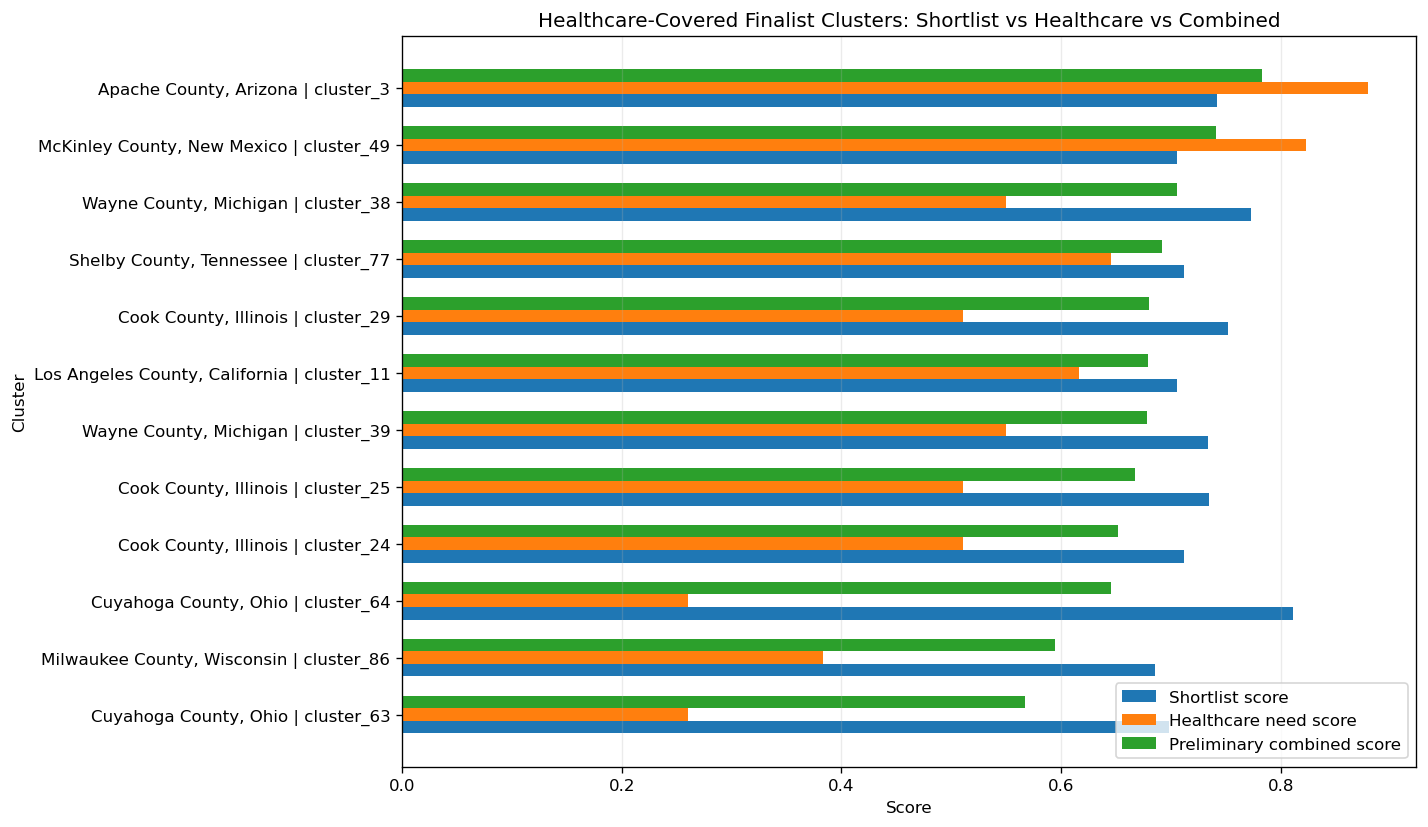


Saved:
- data\processed\storytelling_overview_finalists.csv


In [184]:
# Cell 9A — first storytelling visual:
# ranked comparison of the healthcare-covered finalist clusters

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# A. Validate inputs
# --------------------------------------------------
if "healthcare_comparison_set" not in globals() or len(healthcare_comparison_set) == 0:
    raise ValueError(
        "healthcare_comparison_set is empty or missing. Run Cell 8 first."
    )

# --------------------------------------------------
# B. Build a compact plotting table
# --------------------------------------------------
storytelling_overview = (
    healthcare_comparison_set[
        [
            "healthcare_comparison_rank",
            "rank",
            "cluster_id",
            "display_state",
            "display_county",
            "n_cluster_tracts",
            "latest_cluster_pop_total",
            "cluster_shortlist_score",
            "healthcare_need_score",
            "preliminary_combined_score",
        ]
    ]
    .copy()
    .sort_values(
        ["preliminary_combined_score", "healthcare_need_score", "cluster_shortlist_score"],
        ascending=[False, False, False]
    )
    .reset_index(drop=True)
)

storytelling_overview["story_rank"] = np.arange(1, len(storytelling_overview) + 1)

storytelling_overview["cluster_label"] = (
    storytelling_overview["display_county"].astype(str)
    + ", "
    + storytelling_overview["display_state"].astype(str)
)

# shorter label if you want cluster number visible too
storytelling_overview["cluster_label_short"] = (
    storytelling_overview["cluster_label"]
    + " | "
    + storytelling_overview["cluster_id"].astype(str).str.extract(r"(cluster_\d+)")[0].fillna("")
)

# --------------------------------------------------
# C. Show the table you will use for storytelling
# --------------------------------------------------
storytelling_view_cols = [
    "story_rank",
    "healthcare_comparison_rank",
    "rank",
    "cluster_label_short",
    "n_cluster_tracts",
    "latest_cluster_pop_total",
    "cluster_shortlist_score",
    "healthcare_need_score",
    "preliminary_combined_score",
]

print("Healthcare-covered finalist overview:")
display(storytelling_overview[storytelling_view_cols])

# --------------------------------------------------
# D. Plot the first comparison visual
# --------------------------------------------------
plot_df = storytelling_overview.sort_values("preliminary_combined_score", ascending=True).copy()
y = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(12, max(7, len(plot_df) * 0.55)))

bar_h = 0.22

ax.barh(
    y - bar_h,
    plot_df["cluster_shortlist_score"],
    height=bar_h,
    label="Shortlist score"
)

ax.barh(
    y,
    plot_df["healthcare_need_score"],
    height=bar_h,
    label="Healthcare need score"
)

ax.barh(
    y + bar_h,
    plot_df["preliminary_combined_score"],
    height=bar_h,
    label="Preliminary combined score"
)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["cluster_label_short"])
ax.set_xlabel("Score")
ax.set_ylabel("Cluster")
ax.set_title("Healthcare-Covered Finalist Clusters: Shortlist vs Healthcare vs Combined")
ax.legend()
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

# --------------------------------------------------
# E. Optional save for later slide/table use
# --------------------------------------------------
OUT_DIR.mkdir(parents=True, exist_ok=True)
storytelling_overview.to_csv(OUT_DIR / "storytelling_overview_finalists.csv", index=False)

print("\nSaved:")
print("-", OUT_DIR / "storytelling_overview_finalists.csv")

### Cell 9C — national overview map with U.S. basemap + cluster locator dots

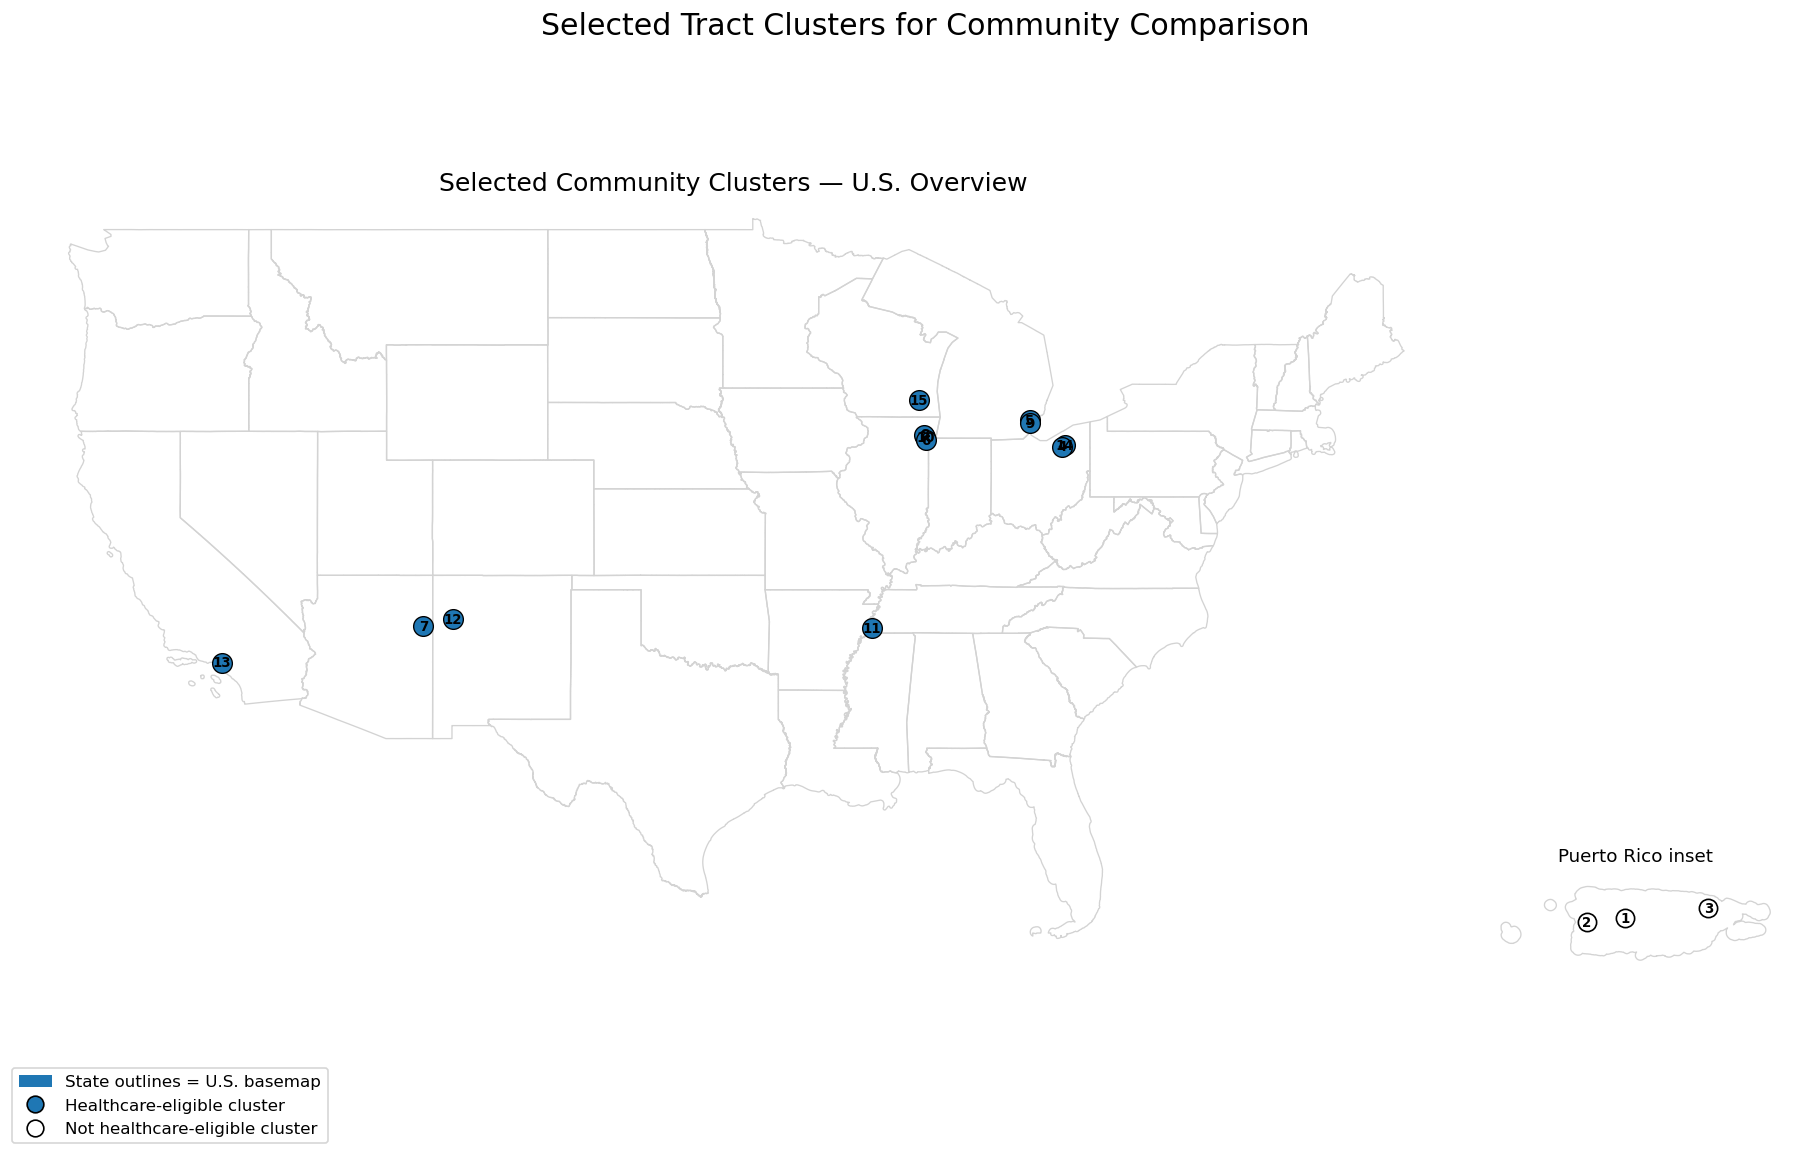

Mapped cluster lookup:


,enrichment_rank,cluster_id,display_state,display_county,healthcare_eligible_flag,cluster_shortlist_score
0,1,Puerto Rico | Utuado Municipio | cluster_75,Puerto Rico,Utuado Municipio,False,0.869855
1,2,Puerto Rico | Mayagüez Municipio | cluster_73,Puerto Rico,Mayagüez Municipio,False,0.848576
2,3,Puerto Rico | Río Grande Municipio | cluster_74,Puerto Rico,Río Grande Municipio,False,0.821570
3,4,Ohio | Cuyahoga County | cluster_64,Ohio,Cuyahoga County,True,0.811047
4,5,Michigan | Wayne County | cluster_38,Michigan,Wayne County,True,0.772703
5,6,Illinois | Cook County | cluster_29,Illinois,Cook County,True,0.752267
6,7,Arizona | Apache County | cluster_3,Arizona,Apache County,True,0.742122
7,8,Illinois | Cook County | cluster_25,Illinois,Cook County,True,0.734564
8,9,Michigan | Wayne County | cluster_39,Michigan,Wayne County,True,0.733314
9,10,Illinois | Cook County | cluster_24,Illinois,Cook County,True,0.712355


In [185]:
# Cell 9C — national overview map with U.S. basemap + cluster locator dots
# Purpose:
# show where the selected clusters are in the U.S. in a presentation-friendly way

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import zipfile
import requests
from pathlib import Path

# --------------------------------------------------
# A. Validate inputs
# --------------------------------------------------
if "adjacency_gdf" not in globals() or len(adjacency_gdf) == 0:
    raise ValueError("adjacency_gdf is missing or empty. Rerun Cell 2 first.")

if "enrichment_clusters" not in globals() or len(enrichment_clusters) == 0:
    raise ValueError("enrichment_clusters is missing or empty. Rerun Cell 6 first.")

# --------------------------------------------------
# B. Choose which cluster set to show
# --------------------------------------------------
MAP_CLUSTER_SOURCE = "enrichment_clusters"
# MAP_CLUSTER_SOURCE = "healthcare_comparison_set"

if MAP_CLUSTER_SOURCE == "healthcare_comparison_set":
    if "healthcare_comparison_set" not in globals() or len(healthcare_comparison_set) == 0:
        raise ValueError("healthcare_comparison_set is missing or empty. Run Cell 8 first.")
    map_clusters_df = healthcare_comparison_set.copy()
else:
    map_clusters_df = enrichment_clusters.copy()

map_cluster_ids = set(map_clusters_df["cluster_id"].astype(str).tolist())

# --------------------------------------------------
# C. Build dissolved cluster geometries
# --------------------------------------------------
map_gdf = adjacency_gdf.loc[
    adjacency_gdf["cluster_id"].astype(str).isin(map_cluster_ids)
].copy()

if len(map_gdf) == 0:
    raise ValueError("No geometries found for selected clusters.")

map_gdf = gpd.GeoDataFrame(map_gdf, geometry="geometry", crs=adjacency_gdf.crs).to_crs(4326)

cluster_boundaries = (
    map_gdf[["cluster_id", "geometry"]]
    .dissolve(by="cluster_id", as_index=False)
)

cluster_meta_cols = ["cluster_id", "display_state", "display_county"]
for c in ["enrichment_rank", "rank", "cluster_shortlist_score"]:
    if c in map_clusters_df.columns:
        cluster_meta_cols.append(c)

cluster_meta = (
    map_clusters_df[cluster_meta_cols]
    .drop_duplicates(subset=["cluster_id"])
    .copy()
)

cluster_boundaries = cluster_boundaries.merge(
    cluster_meta,
    on="cluster_id",
    how="left",
    validate="1:1"
)

# healthcare eligibility if available
if "cluster_shortlist_with_healthcare" in globals() and len(cluster_shortlist_with_healthcare) > 0:
    eligibility_df = (
        cluster_shortlist_with_healthcare[["cluster_id", "healthcare_eligible_flag"]]
        .drop_duplicates(subset=["cluster_id"])
        .copy()
    )
    cluster_boundaries = cluster_boundaries.merge(
        eligibility_df,
        on="cluster_id",
        how="left",
        validate="1:1"
    )
else:
    cluster_boundaries["healthcare_eligible_flag"] = False

cluster_boundaries["healthcare_eligible_flag"] = (
    cluster_boundaries["healthcare_eligible_flag"].fillna(False).astype(bool)
)

cluster_boundaries["label_point"] = cluster_boundaries.geometry.representative_point()
cluster_boundaries["lon"] = cluster_boundaries["label_point"].x
cluster_boundaries["lat"] = cluster_boundaries["label_point"].y

# --------------------------------------------------
# D. Load U.S. state basemap (Census TIGER states)
# --------------------------------------------------
STATE_BASE_URL = "https://www2.census.gov/geo/tiger/TIGER2024/STATE/"
STATE_ROOT_DIR = RAW_DIR / "tl_2024_us_state"
STATE_ROOT_DIR.mkdir(parents=True, exist_ok=True)

state_zip_name = "tl_2024_us_state.zip"
state_shp_name = "tl_2024_us_state.shp"
state_zip_path = STATE_ROOT_DIR / state_zip_name
state_extract_dir = STATE_ROOT_DIR / "tl_2024_us_state"
state_shp_path = state_extract_dir / state_shp_name

if not state_shp_path.exists():
    state_extract_dir.mkdir(parents=True, exist_ok=True)

    if not state_zip_path.exists():
        url = f"{STATE_BASE_URL}{state_zip_name}"
        print(f"Downloading {url}")
        r = requests.get(url, timeout=120)
        r.raise_for_status()
        with open(state_zip_path, "wb") as f:
            f.write(r.content)

    print(f"Extracting {state_zip_name}")
    with zipfile.ZipFile(state_zip_path, "r") as zf:
        zf.extractall(state_extract_dir)

states_gdf = gpd.read_file(state_shp_path).to_crs(4326)

# Keep only states / DC / PR, drop territories not needed for this slide
drop_names = {
    "Alaska", "Hawaii", "Guam", "American Samoa",
    "Commonwealth of the Northern Mariana Islands",
    "United States Virgin Islands"
}
states_gdf = states_gdf.loc[~states_gdf["NAME"].isin(drop_names)].copy()

conus_states = states_gdf.loc[states_gdf["NAME"] != "Puerto Rico"].copy()
pr_state = states_gdf.loc[states_gdf["NAME"] == "Puerto Rico"].copy()

# --------------------------------------------------
# E. Split points into CONUS vs Puerto Rico
# --------------------------------------------------
conus_points = cluster_boundaries.loc[cluster_boundaries["display_state"] != "Puerto Rico"].copy()
pr_points = cluster_boundaries.loc[cluster_boundaries["display_state"] == "Puerto Rico"].copy()

# --------------------------------------------------
# F. Plot
# --------------------------------------------------
fig = plt.figure(figsize=(16, 10))

# Main U.S. panel
ax_main = fig.add_axes([0.04, 0.08, 0.72, 0.84])
conus_states.boundary.plot(ax=ax_main, linewidth=0.8, color="lightgray")

# Healthcare-eligible vs not
conus_yes = conus_points.loc[conus_points["healthcare_eligible_flag"]].copy()
conus_no = conus_points.loc[~conus_points["healthcare_eligible_flag"]].copy()

if len(conus_yes) > 0:
    ax_main.scatter(
        conus_yes["lon"], conus_yes["lat"],
        s=140, zorder=3, edgecolor="black", linewidth=0.8,
        label="Healthcare-eligible"
    )

if len(conus_no) > 0:
    ax_main.scatter(
        conus_no["lon"], conus_no["lat"],
        s=140, zorder=3, edgecolor="black", linewidth=1.0,
        facecolors="white", label="Not healthcare-eligible"
    )

for _, row in conus_points.iterrows():
    label_txt = ""
    if "enrichment_rank" in row and pd.notna(row["enrichment_rank"]):
        label_txt = str(int(row["enrichment_rank"]))

    if label_txt:
        ax_main.text(
            row["lon"], row["lat"], label_txt,
            ha="center", va="center",
            fontsize=8, fontweight="bold",
            zorder=4
        )

ax_main.set_title("Selected Community Clusters — U.S. Overview", fontsize=15)
ax_main.set_xlim(-126, -66)
ax_main.set_ylim(24, 50)
ax_main.set_axis_off()

# Puerto Rico inset
ax_pr = fig.add_axes([0.79, 0.12, 0.16, 0.18])
if len(pr_state) > 0:
    pr_state.boundary.plot(ax=ax_pr, linewidth=0.8, color="lightgray")

pr_yes = pr_points.loc[pr_points["healthcare_eligible_flag"]].copy()
pr_no = pr_points.loc[~pr_points["healthcare_eligible_flag"]].copy()

if len(pr_yes) > 0:
    ax_pr.scatter(
        pr_yes["lon"], pr_yes["lat"],
        s=120, zorder=3, edgecolor="black", linewidth=0.8
    )

if len(pr_no) > 0:
    ax_pr.scatter(
        pr_no["lon"], pr_no["lat"],
        s=120, zorder=3, edgecolor="black", linewidth=1.0,
        facecolors="white"
    )

for _, row in pr_points.iterrows():
    label_txt = ""
    if "enrichment_rank" in row and pd.notna(row["enrichment_rank"]):
        label_txt = str(int(row["enrichment_rank"]))

    if label_txt:
        ax_pr.text(
            row["lon"], row["lat"], label_txt,
            ha="center", va="center",
            fontsize=8, fontweight="bold",
            zorder=4
        )

if len(pr_state) > 0:
    minx, miny, maxx, maxy = pr_state.total_bounds
    ax_pr.set_xlim(minx - 0.2, maxx + 0.2)
    ax_pr.set_ylim(miny - 0.15, maxy + 0.15)

ax_pr.set_title("Puerto Rico inset", fontsize=11)
ax_pr.set_axis_off()

fig.suptitle("Selected Tract Clusters for Community Comparison", fontsize=18, y=0.97)

# Legend
legend_handles = [
    mpatches.Patch(label="State outlines = U.S. basemap"),
]

if len(conus_yes) + len(pr_yes) > 0:
    legend_handles.append(
        plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor='C0', markeredgecolor='black',
                   markersize=10, label='Healthcare-eligible cluster')
    )

if len(conus_no) + len(pr_no) > 0:
    legend_handles.append(
        plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor='white', markeredgecolor='black',
                   markersize=10, label='Not healthcare-eligible cluster')
    )

fig.legend(
    handles=legend_handles,
    loc="lower left",
    bbox_to_anchor=(0.02, 0.02),
    frameon=True
)

plt.show()

# --------------------------------------------------
# G. Printed lookup table
# --------------------------------------------------
lookup_cols = [
    c for c in [
        "enrichment_rank",
        "cluster_id",
        "display_state",
        "display_county",
        "healthcare_eligible_flag",
        "cluster_shortlist_score"
    ]
    if c in cluster_boundaries.columns
]

print("Mapped cluster lookup:")
display(
    cluster_boundaries[lookup_cols]
    .sort_values(
        ["enrichment_rank", "cluster_id"] if "enrichment_rank" in cluster_boundaries.columns else ["cluster_id"]
    )
    .reset_index(drop=True)
)

### Cell 9D — ranked score comparison chart for healthcare-covered finalist clusters

Ranked healthcare-covered comparison set:


,final_rank,rank,healthcare_comparison_rank,display_county,display_state,n_cluster_tracts,latest_cluster_pop_total,cluster_shortlist_score,healthcare_need_score,preliminary_combined_score
0,1,7,1,Apache County,Arizona,18,65341.0,0.742122,0.879167,0.783235
1,2,12,2,McKinley County,New Mexico,33,70431.0,0.705959,0.822917,0.741047
2,3,5,3,Wayne County,Michigan,152,319984.0,0.772703,0.550000,0.705892
3,4,11,4,Shelby County,Tennessee,96,268298.0,0.712122,0.645833,0.692235
4,5,6,5,Cook County,Illinois,9,27412.0,0.752267,0.510417,0.679712
5,6,13,6,Los Angeles County,California,5,19914.0,0.705523,0.616667,0.678866
6,7,9,7,Wayne County,Michigan,9,19947.0,0.733314,0.550000,0.678320
7,8,8,8,Cook County,Illinois,33,81348.0,0.734564,0.510417,0.667320
8,9,10,9,Cook County,Illinois,85,187702.0,0.712355,0.510417,0.651773
9,10,4,10,Cuyahoga County,Ohio,13,31886.0,0.811047,0.260417,0.645858


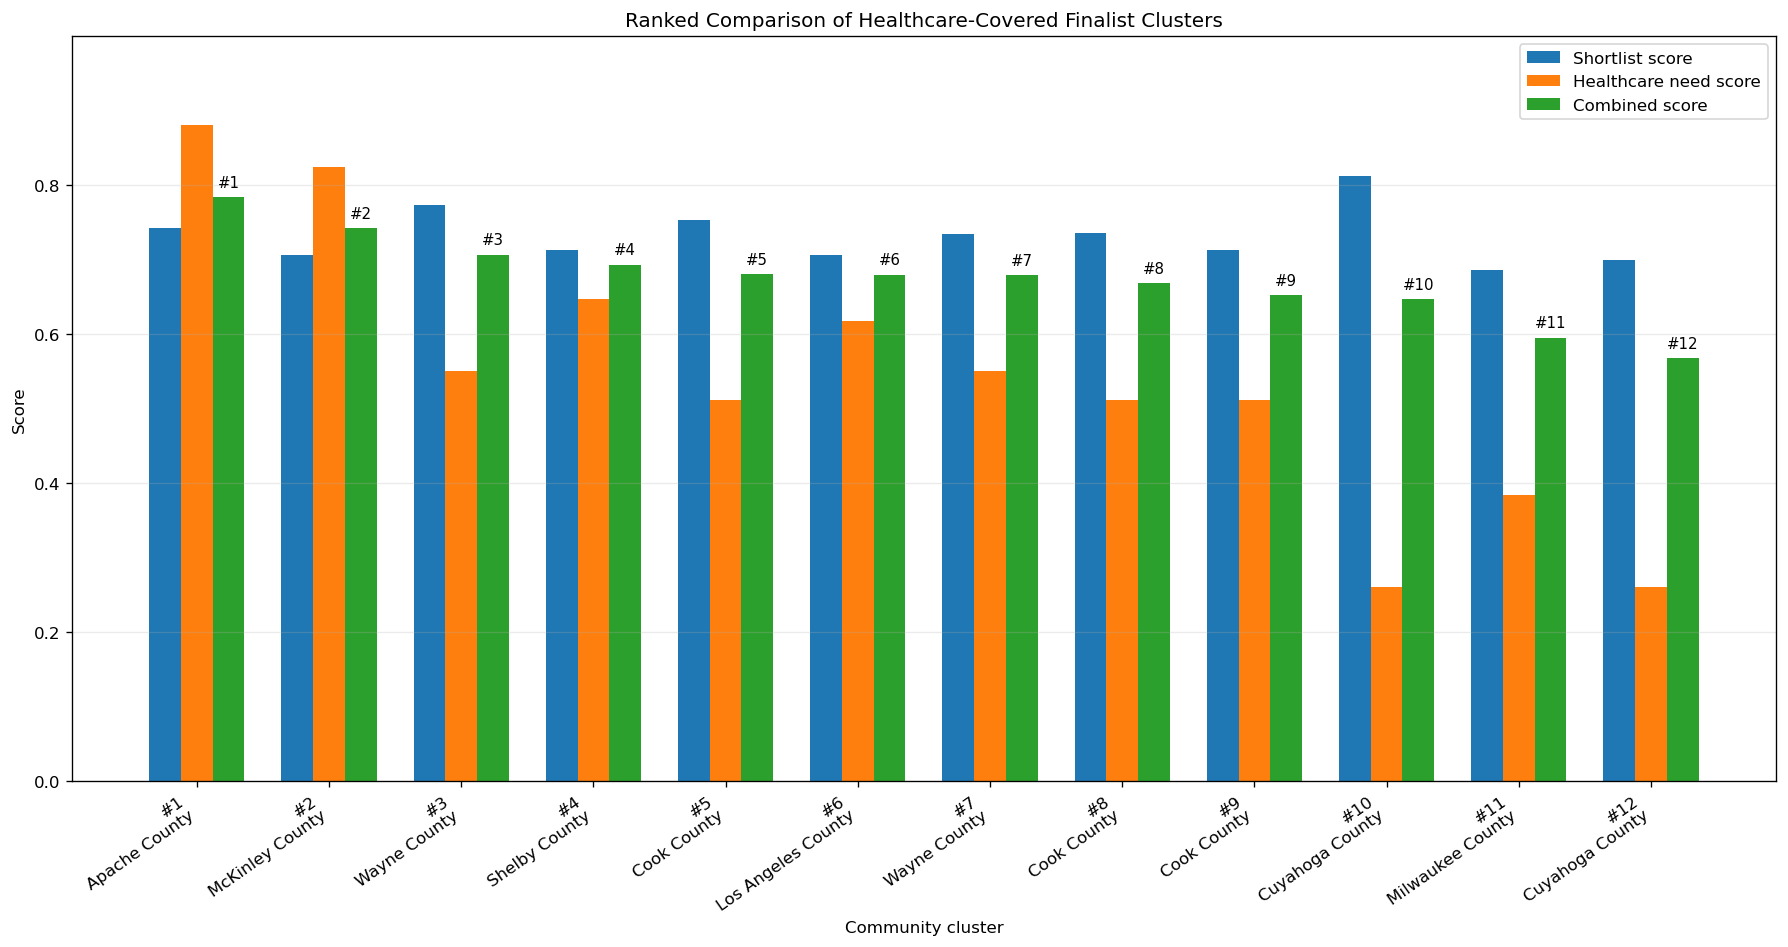


Saved:
- data\processed\ranked_score_comparison_chart_data.csv


In [186]:
# Cell 9D (vertical version) — ranked score comparison chart

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# A. Validate inputs
# --------------------------------------------------
if "healthcare_comparison_set" not in globals() or len(healthcare_comparison_set) == 0:
    raise ValueError(
        "healthcare_comparison_set is empty or missing. Run Cell 8 first."
    )

# --------------------------------------------------
# B. Build ranked plotting table
# --------------------------------------------------
ranked_score_df = (
    healthcare_comparison_set[
        [
            "healthcare_comparison_rank",
            "rank",
            "cluster_id",
            "display_state",
            "display_county",
            "n_cluster_tracts",
            "latest_cluster_pop_total",
            "cluster_shortlist_score",
            "healthcare_need_score",
            "preliminary_combined_score",
        ]
    ]
    .copy()
    .sort_values(
        ["preliminary_combined_score", "healthcare_need_score", "cluster_shortlist_score"],
        ascending=[False, False, False]
    )
    .reset_index(drop=True)
)

ranked_score_df["final_rank"] = np.arange(1, len(ranked_score_df) + 1)

ranked_score_df["cluster_label"] = (
    "#" + ranked_score_df["final_rank"].astype(str)
    + "\n"
    + ranked_score_df["display_county"].astype(str)
)

print("Ranked healthcare-covered comparison set:")
display(
    ranked_score_df[
        [
            "final_rank",
            "rank",
            "healthcare_comparison_rank",
            "display_county",
            "display_state",
            "n_cluster_tracts",
            "latest_cluster_pop_total",
            "cluster_shortlist_score",
            "healthcare_need_score",
            "preliminary_combined_score",
        ]
    ]
)

# --------------------------------------------------
# C. Plot ranked vertical grouped bar chart
# --------------------------------------------------
plot_df = ranked_score_df.copy()
x = np.arange(len(plot_df))
bar_w = 0.24

fig, ax = plt.subplots(figsize=(15, 8))

ax.bar(
    x - bar_w,
    plot_df["cluster_shortlist_score"],
    width=bar_w,
    label="Shortlist score"
)

ax.bar(
    x,
    plot_df["healthcare_need_score"],
    width=bar_w,
    label="Healthcare need score"
)

ax.bar(
    x + bar_w,
    plot_df["preliminary_combined_score"],
    width=bar_w,
    label="Combined score"
)

# rank labels above combined bars
for xi, val, rank in zip(x, plot_df["preliminary_combined_score"], plot_df["final_rank"]):
    ax.text(xi + bar_w, val + 0.01, f"#{rank}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["cluster_label"], rotation=35, ha="right")
ax.set_ylabel("Score")
ax.set_xlabel("Community cluster")
ax.set_title("Ranked Comparison of Healthcare-Covered Finalist Clusters")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=True, loc="upper right")

ymax = max(
    plot_df["cluster_shortlist_score"].max(),
    plot_df["healthcare_need_score"].max(),
    plot_df["preliminary_combined_score"].max()
)
ax.set_ylim(0, ymax + 0.12)

plt.tight_layout()
plt.show()

# --------------------------------------------------
# D. Optional save
# --------------------------------------------------
OUT_DIR.mkdir(parents=True, exist_ok=True)
ranked_score_df.to_csv(OUT_DIR / "ranked_score_comparison_chart_data.csv", index=False)

print("\nSaved:")
print("-", OUT_DIR / "ranked_score_comparison_chart_data.csv")

### Cell 9E — small-multiples trend view for finalist clusters


Top finalists used in the trend view:


,final_trend_rank,display_county,display_state,cluster_shortlist_score,healthcare_need_score,preliminary_combined_score
0,1,Apache County,Arizona,0.742122,0.879167,0.783235
1,2,McKinley County,New Mexico,0.705959,0.822917,0.741047
2,3,Wayne County,Michigan,0.772703,0.550000,0.705892
3,4,Shelby County,Tennessee,0.712122,0.645833,0.692235


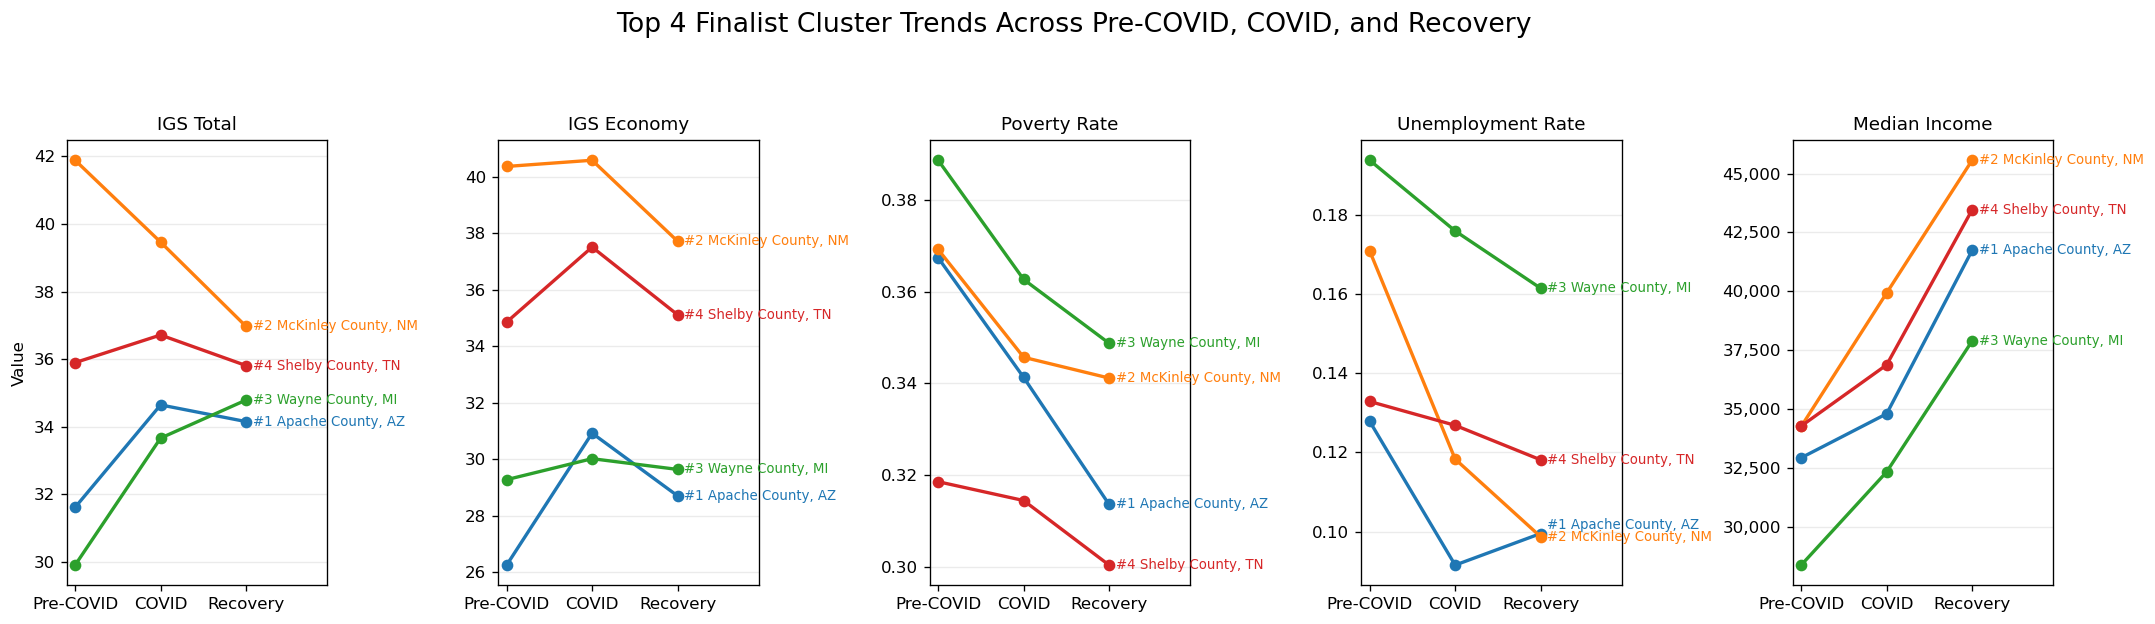

Saved:
- data\processed\top4_finalist_metric_first_trends.csv


In [187]:
# Cell 9E (refined) — top-4 finalist trend view with direct line-end labels
# Changes:
# - only top 4 finalists
# - no legend
# - direct labels at the recovery end of each line
# - cleaner, more slide-ready layout

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# A. Validate inputs
# --------------------------------------------------
if "healthcare_comparison_set" not in globals() or len(healthcare_comparison_set) == 0:
    raise ValueError("healthcare_comparison_set is empty or missing. Run Cell 8 first.")

if "cluster_period_summary" not in globals() or len(cluster_period_summary) == 0:
    raise ValueError("cluster_period_summary is empty or missing. Run Cell 4 first.")

# --------------------------------------------------
# B. Settings
# --------------------------------------------------
N_FINALISTS_FOR_TRENDS = min(4, len(healthcare_comparison_set))

PERIOD_ORDER = ["pre_covid", "covid", "recovery"]
PERIOD_LABELS = ["Pre-COVID", "COVID", "Recovery"]

trend_metric_map = {
    "igs_total": "IGS Total",
    "igs_economy": "IGS Economy",
    "poverty_rate": "Poverty Rate",
    "unemp_rate": "Unemployment Rate",
    "median_household_income": "Median Income",
}

# Shorter labels for direct annotation
def short_cluster_label(rank, county, state):
    state_short = {
        "Arizona": "AZ",
        "New Mexico": "NM",
        "Michigan": "MI",
        "Tennessee": "TN",
        "Illinois": "IL",
        "California": "CA",
        "Ohio": "OH",
        "Wisconsin": "WI",
    }.get(state, state)
    return f"#{int(rank)} {county}, {state_short}"

# --------------------------------------------------
# C. Select top finalists
# --------------------------------------------------
finalists_for_trends = (
    healthcare_comparison_set
    .sort_values(
        ["preliminary_combined_score", "healthcare_need_score", "cluster_shortlist_score"],
        ascending=[False, False, False]
    )
    .head(N_FINALISTS_FOR_TRENDS)
    .copy()
    .reset_index(drop=True)
)

finalists_for_trends["final_trend_rank"] = np.arange(1, len(finalists_for_trends) + 1)
finalists_for_trends["cluster_label"] = finalists_for_trends.apply(
    lambda r: short_cluster_label(r["final_trend_rank"], r["display_county"], r["display_state"]),
    axis=1
)

print("Top finalists used in the trend view:")
display(
    finalists_for_trends[
        [
            "final_trend_rank",
            "display_county",
            "display_state",
            "cluster_shortlist_score",
            "healthcare_need_score",
            "preliminary_combined_score",
        ]
    ]
)

# --------------------------------------------------
# D. Build long table
# --------------------------------------------------
trend_rows = []

for _, finalist in finalists_for_trends.iterrows():
    cluster_id = finalist["cluster_id"]
    cluster_label = finalist["cluster_label"]

    row = cluster_period_summary.loc[cluster_period_summary["cluster_id"] == cluster_id]
    if len(row) == 0:
        continue

    row = row.iloc[0]

    for metric, metric_label in trend_metric_map.items():
        vals = []
        for period in PERIOD_ORDER:
            col = f"{metric}_{period}"
            vals.append(pd.to_numeric(row.get(col, np.nan), errors="coerce"))

        for i, period in enumerate(PERIOD_ORDER):
            trend_rows.append({
                "cluster_id": cluster_id,
                "cluster_label": cluster_label,
                "metric": metric,
                "metric_label": metric_label,
                "period": period,
                "period_label": PERIOD_LABELS[i],
                "value": vals[i],
            })

trend_long_df = pd.DataFrame(trend_rows)

if len(trend_long_df) == 0:
    raise ValueError("No trend data was built for plotting.")

# --------------------------------------------------
# E. Plot: one panel per metric, finalists as lines
# --------------------------------------------------
fig, axes = plt.subplots(1, 5, figsize=(18, 5), squeeze=False)
axes = axes[0]
x = np.arange(len(PERIOD_ORDER))

for ax, (metric, metric_label) in zip(axes, trend_metric_map.items()):
    sub = trend_long_df.loc[trend_long_df["metric"] == metric].copy()

    # plot each finalist
    line_data = []
    for cluster_label, grp in sub.groupby("cluster_label", sort=False):
        grp = grp.set_index("period").reindex(PERIOD_ORDER).reset_index()

        line, = ax.plot(
            x,
            grp["value"],
            marker="o",
            linewidth=2
        )

        # store for direct labeling
        y_end = grp.loc[grp["period"] == "recovery", "value"].iloc[0]
        line_data.append({
            "cluster_label": cluster_label,
            "y_end": y_end,
            "color": line.get_color(),
        })

    # direct labels at the recovery end
    # sort by end value so labels are less likely to collide
    line_data = sorted(line_data, key=lambda d: d["y_end"])

    # simple vertical nudging if labels are too close
    adjusted_y = []
    min_gap = 0.03 * (sub["value"].max() - sub["value"].min()) if sub["value"].notna().any() else 0.01
    if min_gap == 0:
        min_gap = 0.01

    for item in line_data:
        y = item["y_end"]
        if adjusted_y and (y - adjusted_y[-1] < min_gap):
            y = adjusted_y[-1] + min_gap
        adjusted_y.append(y)
        item["y_label"] = y

    for item in line_data:
        ax.text(
            2.08,
            item["y_label"],
            item["cluster_label"],
            color=item["color"],
            fontsize=8,
            va="center"
        )

    ax.set_title(metric_label, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(PERIOD_LABELS, rotation=0)
    ax.grid(axis="y", alpha=0.25)
    ax.set_xlim(-0.1, 2.95)

    if metric == "median_household_income":
        ax.ticklabel_format(style="plain", axis="y")
        ax.get_yaxis().set_major_formatter(
            plt.FuncFormatter(lambda v, pos: f"{int(v):,}")
        )

axes[0].set_ylabel("Value")

fig.suptitle(
    "Top 4 Finalist Cluster Trends Across Pre-COVID, COVID, and Recovery",
    fontsize=16,
    y=1.03
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# --------------------------------------------------
# F. Optional save
# --------------------------------------------------
OUT_DIR.mkdir(parents=True, exist_ok=True)
trend_long_df.to_csv(OUT_DIR / "top4_finalist_metric_first_trends.csv", index=False)

print("Saved:")
print("-", OUT_DIR / "top4_finalist_metric_first_trends.csv")

### Cell 9F — healthcare access comparison heatmap across finalist clusters

Preview of healthcare values used in the heatmap:


,cluster_label,healthcare_need_score,uninsured_rate,uninsured_adults_rate,uninsured_children_rate,primary_care_physicians_rate,dentists_rate,mental_health_providers_rate,other_primary_care_providers_rate,preventable_hospital_stays_rate,mammography_screening_rate,flu_vaccinations_rate
0,"#1 — Apache County, Arizona",0.879167,0.198031,0.230315,0.128705,0.000410,0.000751,0.001093,0.000970,3750.0,0.205,0.400
1,"#2 — McKinley County, New Mexico",0.822917,0.188087,0.241622,0.075279,0.000752,0.000722,0.001697,0.000596,3481.0,0.245,0.445
2,"#3 — Wayne County, Michigan",0.550000,0.070757,0.087738,0.026215,0.000755,0.000732,0.003282,0.001036,5730.5,0.360,0.460
3,"#4 — Shelby County, Tennessee",0.645833,0.131008,0.161872,0.055092,0.000878,0.000759,0.001702,0.001595,3897.0,0.335,0.505
4,"#5 — Cook County, Illinois",0.510417,0.105727,0.129626,0.036922,0.000959,0.000955,0.003294,0.001032,4124.0,0.370,0.505
5,"#6 — Los Angeles County, California",0.616667,0.106480,0.130229,0.036193,0.000741,0.000927,0.004129,0.000764,3078.0,0.285,0.410
6,"#7 — Wayne County, Michigan",0.550000,0.070757,0.087738,0.026215,0.000755,0.000732,0.003282,0.001036,5730.5,0.360,0.460
7,"#8 — Cook County, Illinois",0.510417,0.105727,0.129626,0.036922,0.000959,0.000955,0.003294,0.001032,4124.0,0.370,0.505
8,"#9 — Cook County, Illinois",0.510417,0.105727,0.129626,0.036922,0.000959,0.000955,0.003294,0.001032,4124.0,0.370,0.505
9,"#10 — Cuyahoga County, Ohio",0.260417,0.073992,0.087338,0.035996,0.001157,0.001093,0.004431,0.002076,4450.0,0.435,0.530


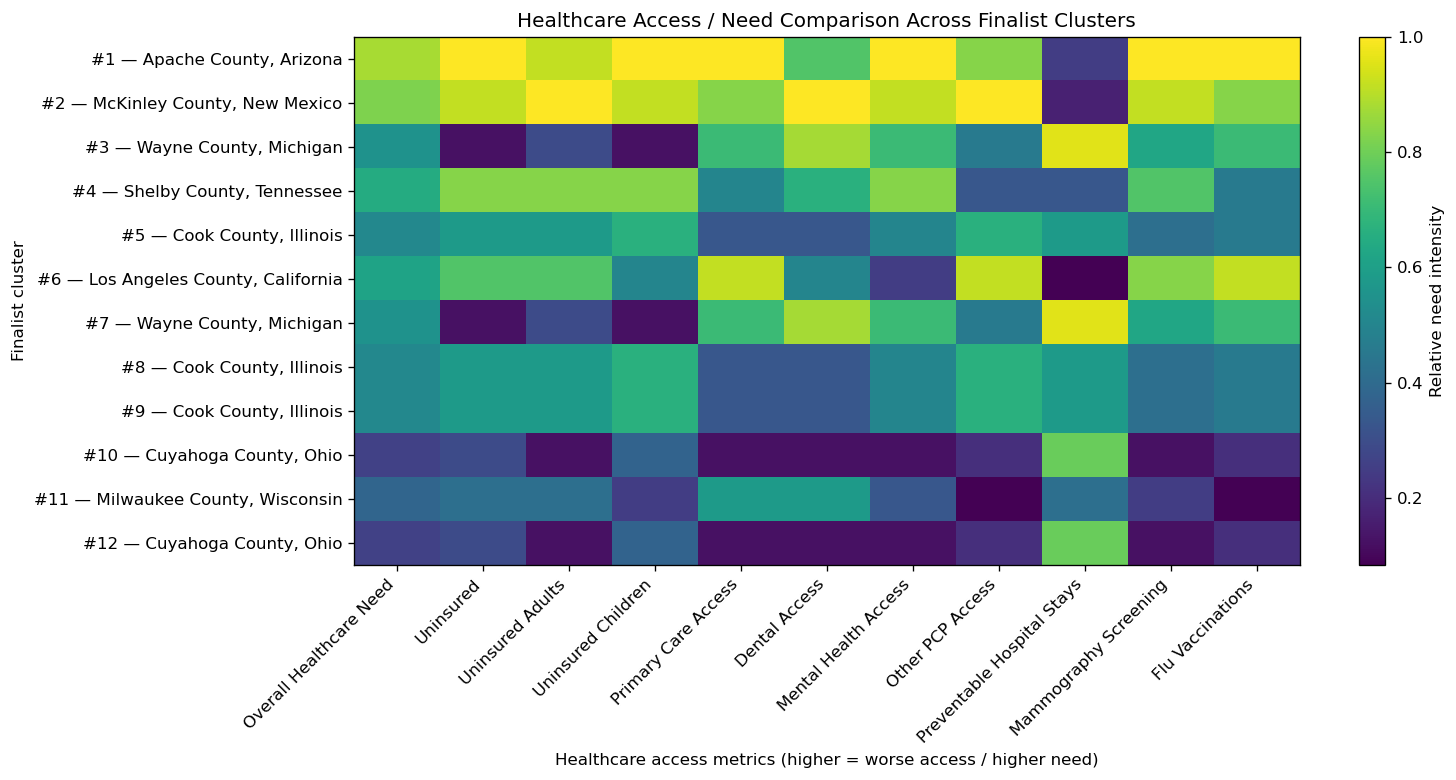

Healthcare access comparison table (relative scores):


,Overall Healthcare Need,Uninsured,Uninsured Adults,Uninsured Children,Primary Care Access,Dental Access,Mental Health Access,Other PCP Access,Preventable Hospital Stays,Mammography Screening,Flu Vaccinations
"#1 — Apache County, Arizona",0.879,1.000,0.917,1.000,1.000,0.750,1.000,0.833,0.250,1.000,1.000
"#2 — McKinley County, New Mexico",0.823,0.917,1.000,0.917,0.833,1.000,0.917,1.000,0.167,0.917,0.833
"#3 — Wayne County, Michigan",0.550,0.125,0.292,0.125,0.708,0.875,0.708,0.458,0.958,0.625,0.708
"#4 — Shelby County, Tennessee",0.646,0.833,0.833,0.833,0.500,0.667,0.833,0.333,0.333,0.750,0.458
"#5 — Cook County, Illinois",0.510,0.583,0.583,0.667,0.333,0.333,0.500,0.667,0.583,0.417,0.458
"#6 — Los Angeles County, California",0.617,0.750,0.750,0.500,0.917,0.500,0.250,0.917,0.083,0.833,0.917
"#7 — Wayne County, Michigan",0.550,0.125,0.292,0.125,0.708,0.875,0.708,0.458,0.958,0.625,0.708
"#8 — Cook County, Illinois",0.510,0.583,0.583,0.667,0.333,0.333,0.500,0.667,0.583,0.417,0.458
"#9 — Cook County, Illinois",0.510,0.583,0.583,0.667,0.333,0.333,0.500,0.667,0.583,0.417,0.458
"#10 — Cuyahoga County, Ohio",0.260,0.292,0.125,0.375,0.125,0.125,0.125,0.208,0.792,0.125,0.208



Saved:
- data\processed\healthcare_access_heatmap_table.csv


In [188]:
# Cell 9F — healthcare access comparison heatmap across finalist clusters
# FIXED:
# avoid pandas index-alignment NaNs by assigning numpy arrays directly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# A. Validate inputs
# --------------------------------------------------
if "healthcare_cluster_scored" not in globals() or len(healthcare_cluster_scored) == 0:
    raise ValueError("healthcare_cluster_scored is empty or missing. Run Cell 8 first.")

if "healthcare_comparison_set" not in globals() or len(healthcare_comparison_set) == 0:
    raise ValueError("healthcare_comparison_set is empty or missing. Run Cell 8 first.")

# --------------------------------------------------
# B. Metric setup
# higher = worse access / higher need
# --------------------------------------------------
healthcare_access_metrics = [
    "uninsured_rate",
    "uninsured_adults_rate",
    "uninsured_children_rate",
    "primary_care_physicians_rate",
    "dentists_rate",
    "mental_health_providers_rate",
    "other_primary_care_providers_rate",
    "preventable_hospital_stays_rate",
    "mammography_screening_rate",
    "flu_vaccinations_rate",
]

metric_label_map = {
    "uninsured_rate": "Uninsured",
    "uninsured_adults_rate": "Uninsured Adults",
    "uninsured_children_rate": "Uninsured Children",
    "primary_care_physicians_rate": "Primary Care Access",
    "dentists_rate": "Dental Access",
    "mental_health_providers_rate": "Mental Health Access",
    "other_primary_care_providers_rate": "Other PCP Access",
    "preventable_hospital_stays_rate": "Preventable Hospital Stays",
    "mammography_screening_rate": "Mammography Screening",
    "flu_vaccinations_rate": "Flu Vaccinations",
}

high_is_bad = {
    "uninsured_rate",
    "uninsured_adults_rate",
    "uninsured_children_rate",
    "preventable_hospital_stays_rate",
}

low_is_bad = {
    "primary_care_physicians_rate",
    "dentists_rate",
    "mental_health_providers_rate",
    "other_primary_care_providers_rate",
    "mammography_screening_rate",
    "flu_vaccinations_rate",
}

# --------------------------------------------------
# C. Build finalist healthcare table
# --------------------------------------------------
heatmap_df = (
    healthcare_cluster_scored
    .merge(
        healthcare_comparison_set[
            ["cluster_id", "healthcare_comparison_rank", "preliminary_combined_score"]
        ].drop_duplicates(),
        on="cluster_id",
        how="inner",
        validate="1:1"
    )
    .copy()
)

heatmap_df = heatmap_df.sort_values(
    ["healthcare_comparison_rank", "healthcare_need_score"],
    ascending=[True, False]
).reset_index(drop=True)

heatmap_df["cluster_label"] = (
    "#" + heatmap_df["healthcare_comparison_rank"].astype(int).astype(str)
    + " — "
    + heatmap_df["display_county"].astype(str)
    + ", "
    + heatmap_df["display_state"].astype(str)
)

print("Preview of healthcare values used in the heatmap:")
display(
    heatmap_df[
        ["cluster_label", "healthcare_need_score"] + healthcare_access_metrics
    ].head(12)
)

# --------------------------------------------------
# D. Convert all metrics so higher = worse access / higher need
# then percentile-rank them across finalists
# --------------------------------------------------
oriented = pd.DataFrame(index=heatmap_df["cluster_label"].tolist())

for metric in healthcare_access_metrics:
    vals = pd.to_numeric(heatmap_df[metric], errors="coerce")

    if metric in high_is_bad:
        ranked = vals.rank(pct=True, method="average")
    elif metric in low_is_bad:
        ranked = (-vals).rank(pct=True, method="average")
    else:
        ranked = pd.Series(np.nan, index=vals.index)

    # IMPORTANT FIX: assign raw values, not index-aligned series
    oriented[metric_label_map[metric]] = ranked.to_numpy()

# keep healthcare need score as summary column
oriented["Overall Healthcare Need"] = pd.to_numeric(
    heatmap_df["healthcare_need_score"], errors="coerce"
).to_numpy()

# move summary column first
ordered_cols = ["Overall Healthcare Need"] + [
    c for c in oriented.columns if c != "Overall Healthcare Need"
]
oriented = oriented[ordered_cols]

# --------------------------------------------------
# E. Plot heatmap
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(13, max(6, len(oriented) * 0.55)))

im = ax.imshow(oriented.values, aspect="auto")

ax.set_xticks(np.arange(oriented.shape[1]))
ax.set_xticklabels(oriented.columns, rotation=45, ha="right")

ax.set_yticks(np.arange(oriented.shape[0]))
ax.set_yticklabels(oriented.index)

ax.set_title("Healthcare Access / Need Comparison Across Finalist Clusters")
ax.set_xlabel("Healthcare access metrics (higher = worse access / higher need)")
ax.set_ylabel("Finalist cluster")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Relative need intensity")

plt.tight_layout()
plt.show()

# --------------------------------------------------
# F. Printed table
# --------------------------------------------------
print("Healthcare access comparison table (relative scores):")
display(oriented.round(3))

# --------------------------------------------------
# G. Optional save
# --------------------------------------------------
OUT_DIR.mkdir(parents=True, exist_ok=True)
oriented.to_csv(OUT_DIR / "healthcare_access_heatmap_table.csv")

print("\nSaved:")
print("-", OUT_DIR / "healthcare_access_heatmap_table.csv")

Preview of healthcare values used in the heatmap:


,cluster_label,healthcare_need_score,uninsured_rate,uninsured_adults_rate,uninsured_children_rate,primary_care_physicians_rate,dentists_rate,mental_health_providers_rate,other_primary_care_providers_rate,preventable_hospital_stays_rate,mammography_screening_rate,flu_vaccinations_rate
0,"#1 — Apache County, Arizona",0.879167,0.198031,0.230315,0.128705,0.000410,0.000751,0.001093,0.000970,3750.0,0.205,0.400
1,"#2 — McKinley County, New Mexico",0.822917,0.188087,0.241622,0.075279,0.000752,0.000722,0.001697,0.000596,3481.0,0.245,0.445
2,"#3 — Wayne County, Michigan",0.550000,0.070757,0.087738,0.026215,0.000755,0.000732,0.003282,0.001036,5730.5,0.360,0.460
3,"#4 — Shelby County, Tennessee",0.645833,0.131008,0.161872,0.055092,0.000878,0.000759,0.001702,0.001595,3897.0,0.335,0.505
4,"#5 — Cook County, Illinois",0.510417,0.105727,0.129626,0.036922,0.000959,0.000955,0.003294,0.001032,4124.0,0.370,0.505
5,"#6 — Los Angeles County, California",0.616667,0.106480,0.130229,0.036193,0.000741,0.000927,0.004129,0.000764,3078.0,0.285,0.410
6,"#7 — Wayne County, Michigan",0.550000,0.070757,0.087738,0.026215,0.000755,0.000732,0.003282,0.001036,5730.5,0.360,0.460
7,"#8 — Cook County, Illinois",0.510417,0.105727,0.129626,0.036922,0.000959,0.000955,0.003294,0.001032,4124.0,0.370,0.505
8,"#9 — Cook County, Illinois",0.510417,0.105727,0.129626,0.036922,0.000959,0.000955,0.003294,0.001032,4124.0,0.370,0.505
9,"#10 — Cuyahoga County, Ohio",0.260417,0.073992,0.087338,0.035996,0.001157,0.001093,0.004431,0.002076,4450.0,0.435,0.530


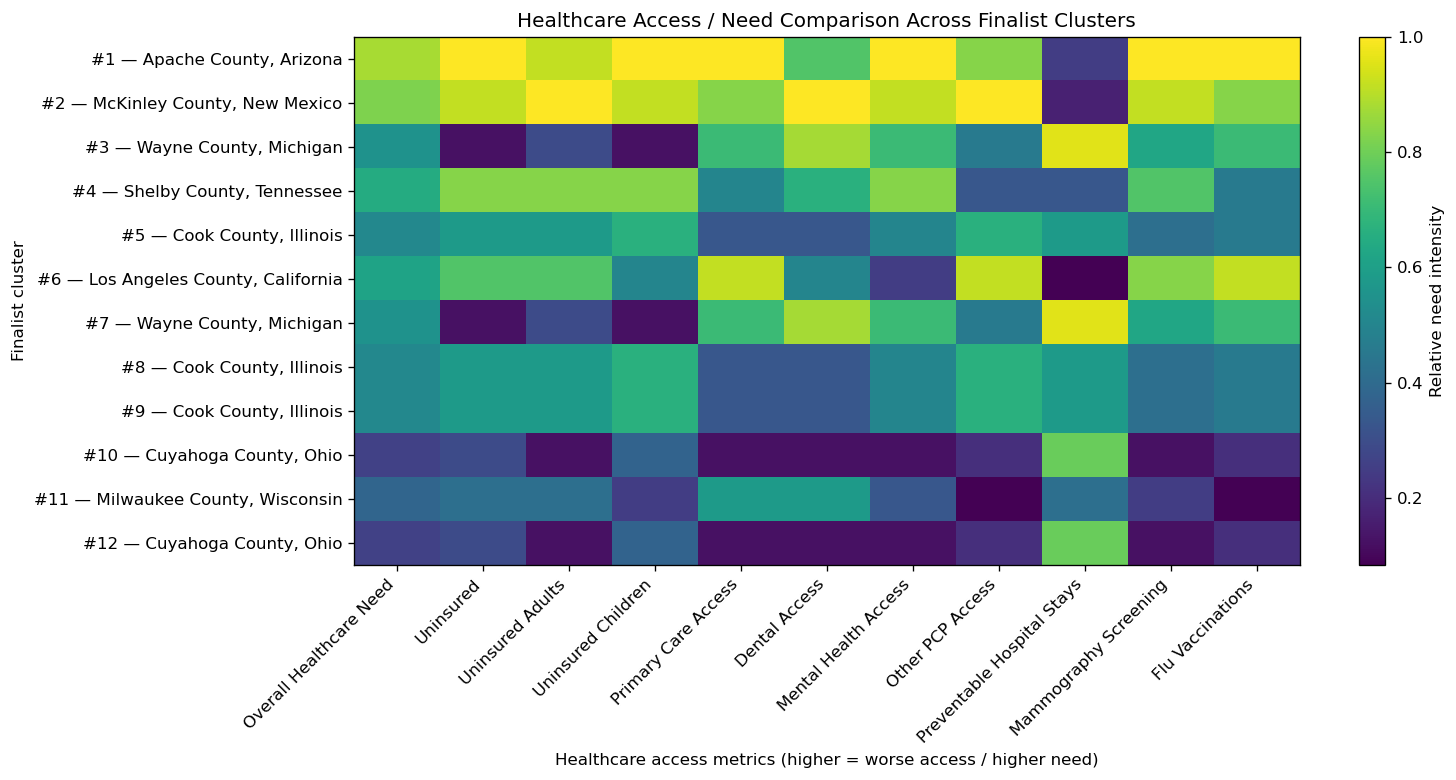

Healthcare access comparison table (relative scores):


,Overall Healthcare Need,Uninsured,Uninsured Adults,Uninsured Children,Primary Care Access,Dental Access,Mental Health Access,Other PCP Access,Preventable Hospital Stays,Mammography Screening,Flu Vaccinations
"#1 — Apache County, Arizona",0.879,1.000,0.917,1.000,1.000,0.750,1.000,0.833,0.250,1.000,1.000
"#2 — McKinley County, New Mexico",0.823,0.917,1.000,0.917,0.833,1.000,0.917,1.000,0.167,0.917,0.833
"#3 — Wayne County, Michigan",0.550,0.125,0.292,0.125,0.708,0.875,0.708,0.458,0.958,0.625,0.708
"#4 — Shelby County, Tennessee",0.646,0.833,0.833,0.833,0.500,0.667,0.833,0.333,0.333,0.750,0.458
"#5 — Cook County, Illinois",0.510,0.583,0.583,0.667,0.333,0.333,0.500,0.667,0.583,0.417,0.458
"#6 — Los Angeles County, California",0.617,0.750,0.750,0.500,0.917,0.500,0.250,0.917,0.083,0.833,0.917
"#7 — Wayne County, Michigan",0.550,0.125,0.292,0.125,0.708,0.875,0.708,0.458,0.958,0.625,0.708
"#8 — Cook County, Illinois",0.510,0.583,0.583,0.667,0.333,0.333,0.500,0.667,0.583,0.417,0.458
"#9 — Cook County, Illinois",0.510,0.583,0.583,0.667,0.333,0.333,0.500,0.667,0.583,0.417,0.458
"#10 — Cuyahoga County, Ohio",0.260,0.292,0.125,0.375,0.125,0.125,0.125,0.208,0.792,0.125,0.208



Saved:
- data\processed\healthcare_access_heatmap_table.csv


In [189]:
# Cell 9F — healthcare access comparison heatmap across finalist clusters
# FIXED:
# avoid pandas index-alignment NaNs by assigning numpy arrays directly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# A. Validate inputs
# --------------------------------------------------
if "healthcare_cluster_scored" not in globals() or len(healthcare_cluster_scored) == 0:
    raise ValueError("healthcare_cluster_scored is empty or missing. Run Cell 8 first.")

if "healthcare_comparison_set" not in globals() or len(healthcare_comparison_set) == 0:
    raise ValueError("healthcare_comparison_set is empty or missing. Run Cell 8 first.")

# --------------------------------------------------
# B. Metric setup
# higher = worse access / higher need
# --------------------------------------------------
healthcare_access_metrics = [
    "uninsured_rate",
    "uninsured_adults_rate",
    "uninsured_children_rate",
    "primary_care_physicians_rate",
    "dentists_rate",
    "mental_health_providers_rate",
    "other_primary_care_providers_rate",
    "preventable_hospital_stays_rate",
    "mammography_screening_rate",
    "flu_vaccinations_rate",
]

metric_label_map = {
    "uninsured_rate": "Uninsured",
    "uninsured_adults_rate": "Uninsured Adults",
    "uninsured_children_rate": "Uninsured Children",
    "primary_care_physicians_rate": "Primary Care Access",
    "dentists_rate": "Dental Access",
    "mental_health_providers_rate": "Mental Health Access",
    "other_primary_care_providers_rate": "Other PCP Access",
    "preventable_hospital_stays_rate": "Preventable Hospital Stays",
    "mammography_screening_rate": "Mammography Screening",
    "flu_vaccinations_rate": "Flu Vaccinations",
}

high_is_bad = {
    "uninsured_rate",
    "uninsured_adults_rate",
    "uninsured_children_rate",
    "preventable_hospital_stays_rate",
}

low_is_bad = {
    "primary_care_physicians_rate",
    "dentists_rate",
    "mental_health_providers_rate",
    "other_primary_care_providers_rate",
    "mammography_screening_rate",
    "flu_vaccinations_rate",
}

# --------------------------------------------------
# C. Build finalist healthcare table
# --------------------------------------------------
heatmap_df = (
    healthcare_cluster_scored
    .merge(
        healthcare_comparison_set[
            ["cluster_id", "healthcare_comparison_rank", "preliminary_combined_score"]
        ].drop_duplicates(),
        on="cluster_id",
        how="inner",
        validate="1:1"
    )
    .copy()
)

heatmap_df = heatmap_df.sort_values(
    ["healthcare_comparison_rank", "healthcare_need_score"],
    ascending=[True, False]
).reset_index(drop=True)

heatmap_df["cluster_label"] = (
    "#" + heatmap_df["healthcare_comparison_rank"].astype(int).astype(str)
    + " — "
    + heatmap_df["display_county"].astype(str)
    + ", "
    + heatmap_df["display_state"].astype(str)
)

print("Preview of healthcare values used in the heatmap:")
display(
    heatmap_df[
        ["cluster_label", "healthcare_need_score"] + healthcare_access_metrics
    ].head(12)
)

# --------------------------------------------------
# D. Convert all metrics so higher = worse access / higher need
# then percentile-rank them across finalists
# --------------------------------------------------
oriented = pd.DataFrame(index=heatmap_df["cluster_label"].tolist())

for metric in healthcare_access_metrics:
    vals = pd.to_numeric(heatmap_df[metric], errors="coerce")

    if metric in high_is_bad:
        ranked = vals.rank(pct=True, method="average")
    elif metric in low_is_bad:
        ranked = (-vals).rank(pct=True, method="average")
    else:
        ranked = pd.Series(np.nan, index=vals.index)

    # IMPORTANT FIX: assign raw values, not index-aligned series
    oriented[metric_label_map[metric]] = ranked.to_numpy()

# keep healthcare need score as summary column
oriented["Overall Healthcare Need"] = pd.to_numeric(
    heatmap_df["healthcare_need_score"], errors="coerce"
).to_numpy()

# move summary column first
ordered_cols = ["Overall Healthcare Need"] + [
    c for c in oriented.columns if c != "Overall Healthcare Need"
]
oriented = oriented[ordered_cols]

# --------------------------------------------------
# E. Plot heatmap
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(13, max(6, len(oriented) * 0.55)))

im = ax.imshow(oriented.values, aspect="auto")

ax.set_xticks(np.arange(oriented.shape[1]))
ax.set_xticklabels(oriented.columns, rotation=45, ha="right")

ax.set_yticks(np.arange(oriented.shape[0]))
ax.set_yticklabels(oriented.index)

ax.set_title("Healthcare Access / Need Comparison Across Finalist Clusters")
ax.set_xlabel("Healthcare access metrics (higher = worse access / higher need)")
ax.set_ylabel("Finalist cluster")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Relative need intensity")

plt.tight_layout()
plt.show()

# --------------------------------------------------
# F. Printed table
# --------------------------------------------------
print("Healthcare access comparison table (relative scores):")
display(oriented.round(3))

# --------------------------------------------------
# G. Optional save
# --------------------------------------------------
OUT_DIR.mkdir(parents=True, exist_ok=True)
oriented.to_csv(OUT_DIR / "healthcare_access_heatmap_table.csv")

print("\nSaved:")
print("-", OUT_DIR / "healthcare_access_heatmap_table.csv")

In [190]:
# Cell 10A — shared prep for finalist visuals

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

# -----------------------------
# basic checks
# -----------------------------
required_globals = [
    "healthcare_comparison_set",
    "healthcare_cluster_scored",
    "cluster_period_summary",
    "analysis_panel",
    "healthcare_standardized",
]
for name in required_globals:
    if name not in globals() or len(globals()[name]) == 0:
        raise ValueError(f"{name} is missing or empty. Rerun the earlier cells first.")

# -----------------------------
# helpers
# -----------------------------
def pct_rank_high(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    return s.rank(pct=True, method="average")

def pct_rank_low(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    return (-s).rank(pct=True, method="average")

def safe_weighted_mean(values: pd.Series, weights: pd.Series):
    values = pd.to_numeric(values, errors="coerce")
    weights = pd.to_numeric(weights, errors="coerce")
    mask = values.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        valid = values.notna()
        return values.loc[valid].mean() if valid.sum() > 0 else np.nan
    return np.average(values.loc[mask], weights=weights.loc[mask])

STATE_ABBR = {
    "Alabama":"AL","Alaska":"AK","Arizona":"AZ","Arkansas":"AR","California":"CA","Colorado":"CO",
    "Connecticut":"CT","Delaware":"DE","District of Columbia":"DC","Florida":"FL","Georgia":"GA",
    "Hawaii":"HI","Idaho":"ID","Illinois":"IL","Indiana":"IN","Iowa":"IA","Kansas":"KS",
    "Kentucky":"KY","Louisiana":"LA","Maine":"ME","Maryland":"MD","Massachusetts":"MA",
    "Michigan":"MI","Minnesota":"MN","Mississippi":"MS","Missouri":"MO","Montana":"MT",
    "Nebraska":"NE","Nevada":"NV","New Hampshire":"NH","New Jersey":"NJ","New Mexico":"NM",
    "New York":"NY","North Carolina":"NC","North Dakota":"ND","Ohio":"OH","Oklahoma":"OK",
    "Oregon":"OR","Pennsylvania":"PA","Rhode Island":"RI","South Carolina":"SC","South Dakota":"SD",
    "Tennessee":"TN","Texas":"TX","Utah":"UT","Vermont":"VT","Virginia":"VA","Washington":"WA",
    "West Virginia":"WV","Wisconsin":"WI","Wyoming":"WY","Puerto Rico":"PR"
}

TOP_FINALISTS_N = min(4, len(healthcare_comparison_set))

# -----------------------------
# top finalists
# -----------------------------
finalist_eval_df = (
    healthcare_comparison_set
    .sort_values(
        ["preliminary_combined_score", "healthcare_need_score", "cluster_shortlist_score"],
        ascending=[False, False, False]
    )
    .head(TOP_FINALISTS_N)
    .copy()
    .reset_index(drop=True)
)

finalist_eval_df["final_rank"] = np.arange(1, len(finalist_eval_df) + 1)
finalist_eval_df["cluster_label"] = (
    "#" + finalist_eval_df["final_rank"].astype(str)
    + " — "
    + finalist_eval_df["display_county"].astype(str)
    + ", "
    + finalist_eval_df["display_state"].astype(str)
)

# attach detailed healthcare metrics
health_cols = [
    "cluster_id",
    "uninsured_rate",
    "uninsured_adults_rate",
    "uninsured_children_rate",
    "primary_care_physicians_rate",
    "dentists_rate",
    "mental_health_providers_rate",
    "other_primary_care_providers_rate",
    "preventable_hospital_stays_rate",
    "mammography_screening_rate",
    "flu_vaccinations_rate",
]
finalist_eval_df = finalist_eval_df.merge(
    healthcare_cluster_scored[health_cols],
    on="cluster_id",
    how="left",
    validate="1:1"
)

# -----------------------------
# healthcare composites
# -----------------------------
all_health = healthcare_cluster_scored.copy()

uninsured_burden_all = (
    pct_rank_high(all_health["uninsured_rate"]) +
    pct_rank_high(all_health["uninsured_adults_rate"]) +
    pct_rank_high(all_health["uninsured_children_rate"])
) / 3

provider_gap_all = (
    pct_rank_low(all_health["primary_care_physicians_rate"]) +
    pct_rank_low(all_health["dentists_rate"]) +
    pct_rank_low(all_health["mental_health_providers_rate"]) +
    pct_rank_low(all_health["other_primary_care_providers_rate"])
) / 4

preventive_gap_all = (
    pct_rank_low(all_health["mammography_screening_rate"]) +
    pct_rank_low(all_health["flu_vaccinations_rate"])
) / 2

preventable_stays_all = pct_rank_high(all_health["preventable_hospital_stays_rate"])

health_composites = pd.DataFrame({
    "cluster_id": all_health["cluster_id"],
    "uninsured_burden_score": uninsured_burden_all,
    "provider_access_gap_score": provider_gap_all,
    "preventive_care_gap_score": preventive_gap_all,
    "preventable_stays_score": preventable_stays_all,
})

finalist_eval_df = finalist_eval_df.merge(
    health_composites,
    on="cluster_id",
    how="left",
    validate="1:1"
)

# -----------------------------
# recovery-period economic context
# -----------------------------
recovery_cols = [
    "cluster_id",
    "igs_total_recovery",
    "igs_economy_recovery",
    "poverty_rate_recovery",
    "unemp_rate_recovery",
    "median_household_income_recovery",
]
finalist_eval_df = finalist_eval_df.merge(
    cluster_period_summary[recovery_cols],
    on="cluster_id",
    how="left",
    validate="1:1"
)

print("Prepared finalist_eval_df:")
display(
    finalist_eval_df[
        [
            "final_rank", "cluster_label",
            "cluster_shortlist_score", "healthcare_need_score", "preliminary_combined_score",
            "uninsured_burden_score", "provider_access_gap_score",
            "preventive_care_gap_score", "preventable_stays_score"
        ]
    ]
)

Prepared finalist_eval_df:


,final_rank,cluster_label,cluster_shortlist_score,healthcare_need_score,preliminary_combined_score,uninsured_burden_score,provider_access_gap_score,preventive_care_gap_score,preventable_stays_score
0,1,"#1 — Apache County, Arizona",0.742122,0.879167,0.783235,0.972222,0.895833,1.000000,0.250000
1,2,"#2 — McKinley County, New Mexico",0.705959,0.822917,0.741047,0.944444,0.937500,0.875000,0.166667
2,3,"#3 — Wayne County, Michigan",0.772703,0.550000,0.705892,0.180556,0.687500,0.666667,0.958333
3,4,"#4 — Shelby County, Tennessee",0.712122,0.645833,0.692235,0.833333,0.583333,0.604167,0.333333


### Cell 10B — finalist decision matrix

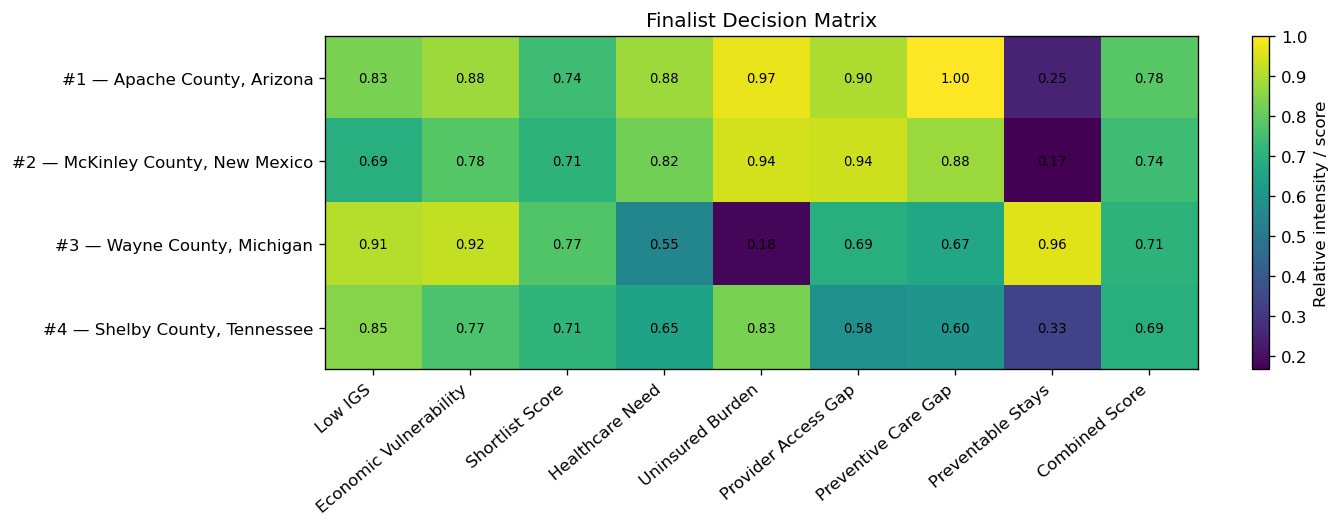

In [191]:
# Cell 10B — finalist decision matrix

matrix_cols = {
    "score_low_igs_recovery": "Low IGS",
    "score_econ_vulnerability_recovery": "Economic Vulnerability",
    "cluster_shortlist_score": "Shortlist Score",
    "healthcare_need_score": "Healthcare Need",
    "uninsured_burden_score": "Uninsured Burden",
    "provider_access_gap_score": "Provider Access Gap",
    "preventive_care_gap_score": "Preventive Care Gap",
    "preventable_stays_score": "Preventable Stays",
    "preliminary_combined_score": "Combined Score",
}

decision_matrix = (
    finalist_eval_df[
        ["cluster_label"] + list(matrix_cols.keys())
    ]
    .rename(columns=matrix_cols)
    .set_index("cluster_label")
    .copy()
)

fig, ax = plt.subplots(figsize=(12, max(4.5, len(decision_matrix) * 0.9)))
im = ax.imshow(decision_matrix.values, aspect="auto")

ax.set_xticks(np.arange(decision_matrix.shape[1]))
ax.set_xticklabels(decision_matrix.columns, rotation=40, ha="right")
ax.set_yticks(np.arange(decision_matrix.shape[0]))
ax.set_yticklabels(decision_matrix.index)

for i in range(decision_matrix.shape[0]):
    for j in range(decision_matrix.shape[1]):
        val = decision_matrix.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

ax.set_title("Finalist Decision Matrix")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Relative intensity / score")

plt.tight_layout()
plt.show()

### Cell 10D — healthcare profile grouped bar chart for the top finalists

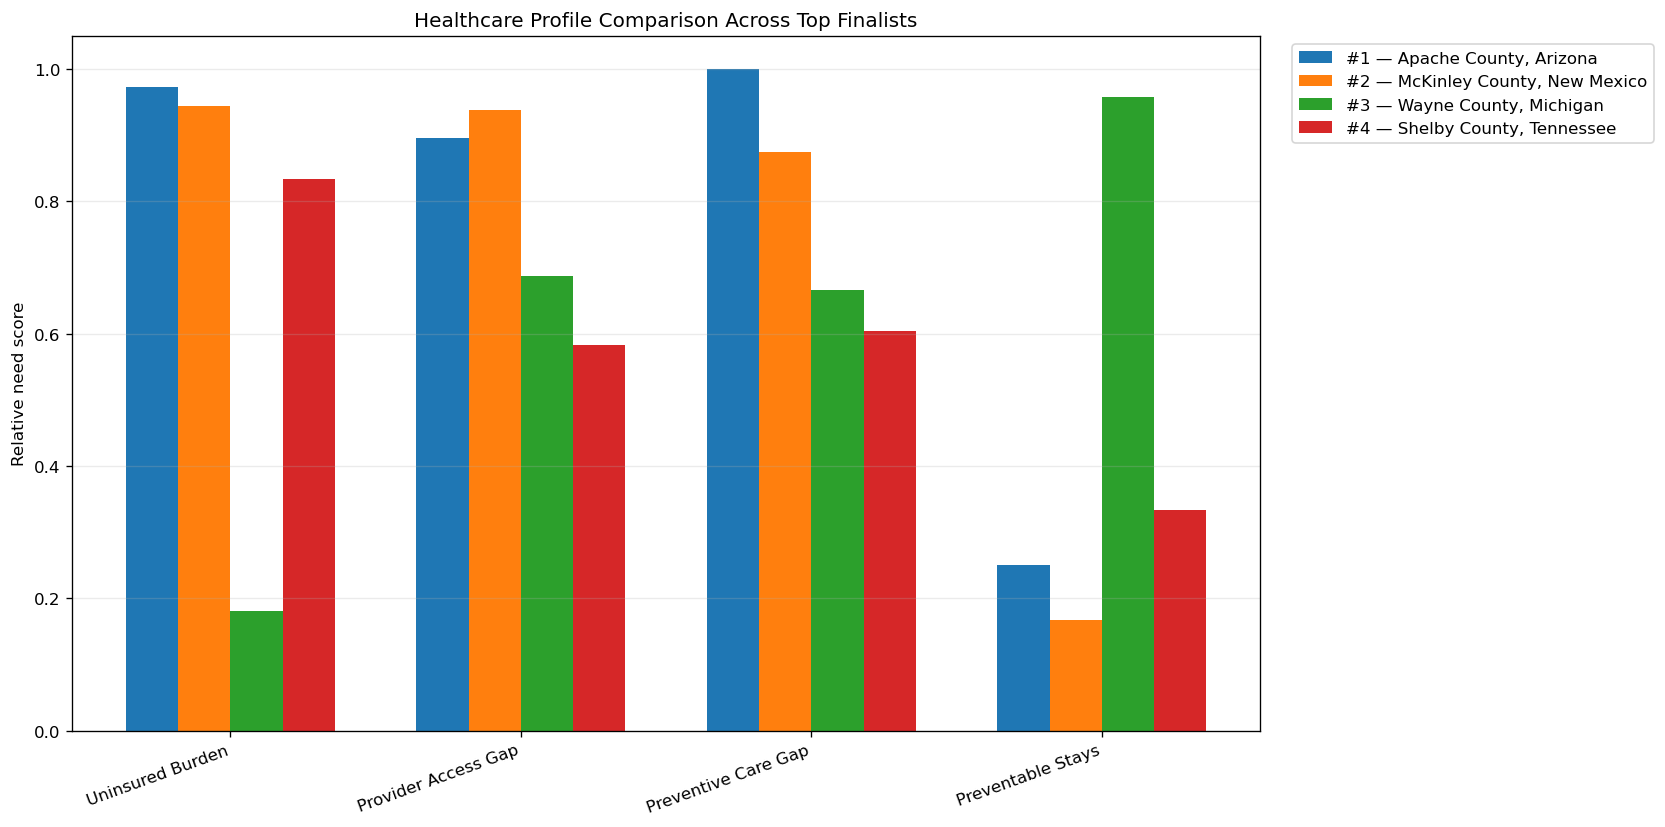

In [192]:
# Cell 10D — healthcare profile grouped bar chart for the top finalists

profile_cols = [
    "uninsured_burden_score",
    "provider_access_gap_score",
    "preventive_care_gap_score",
    "preventable_stays_score",
]

profile_labels = {
    "uninsured_burden_score": "Uninsured Burden",
    "provider_access_gap_score": "Provider Access Gap",
    "preventive_care_gap_score": "Preventive Care Gap",
    "preventable_stays_score": "Preventable Stays",
}

plot_df = finalist_eval_df[["cluster_label"] + profile_cols].copy()

x = np.arange(len(profile_cols))
bar_w = 0.18

fig, ax = plt.subplots(figsize=(14, 7))

for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.bar(
        x + (i - (len(plot_df)-1)/2) * bar_w,
        row[profile_cols].values,
        width=bar_w,
        label=row["cluster_label"]
    )

ax.set_xticks(x)
ax.set_xticklabels([profile_labels[c] for c in profile_cols], rotation=20, ha="right")
ax.set_ylabel("Relative need score")
ax.set_title("Healthcare Profile Comparison Across Top Finalists")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=True, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

### Cell 10E — "Why here?" place-based slide for the top 2 candidates

### Cell 10F — provisional solution-fit visual

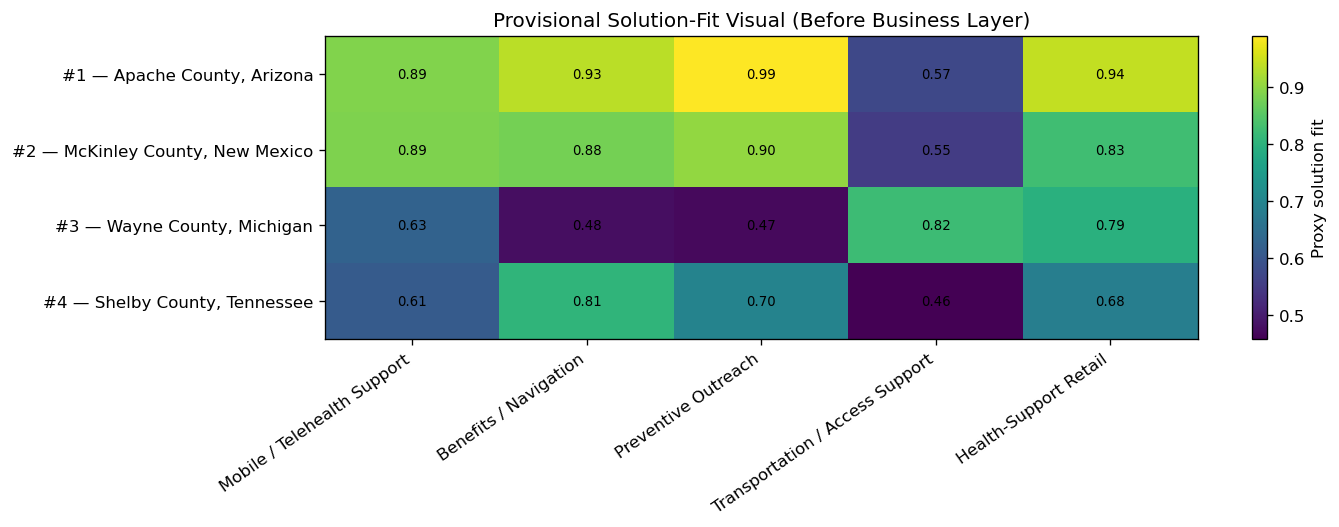

In [193]:
# Cell 10F — provisional solution-fit visual
# IMPORTANT:
# this is a proxy-based fit view using current econ + healthcare patterns only.
# it should be updated once the business layer is added.

solution_fit = finalist_eval_df[["cluster_label"]].copy()

solution_fit["Mobile / Telehealth Support"] = (
    0.55 * finalist_eval_df["provider_access_gap_score"] +
    0.45 * finalist_eval_df["healthcare_need_score"]
)

solution_fit["Benefits / Navigation"] = (
    0.60 * finalist_eval_df["uninsured_burden_score"] +
    0.40 * finalist_eval_df["score_econ_vulnerability_recovery"]
)

solution_fit["Preventive Outreach"] = (
    0.60 * finalist_eval_df["preventive_care_gap_score"] +
    0.40 * finalist_eval_df["uninsured_burden_score"]
)

solution_fit["Transportation / Access Support"] = (
    0.50 * finalist_eval_df["provider_access_gap_score"] +
    0.50 * finalist_eval_df["preventable_stays_score"]
)

solution_fit["Health-Support Retail"] = (
    0.50 * finalist_eval_df["preventive_care_gap_score"] +
    0.50 * finalist_eval_df["score_econ_vulnerability_recovery"]
)

solution_fit = solution_fit.set_index("cluster_label")

fig, ax = plt.subplots(figsize=(12, max(4.5, len(solution_fit) * 0.9)))
im = ax.imshow(solution_fit.values, aspect="auto")

ax.set_xticks(np.arange(solution_fit.shape[1]))
ax.set_xticklabels(solution_fit.columns, rotation=35, ha="right")
ax.set_yticks(np.arange(solution_fit.shape[0]))
ax.set_yticklabels(solution_fit.index)

for i in range(solution_fit.shape[0]):
    for j in range(solution_fit.shape[1]):
        ax.text(j, i, f"{solution_fit.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

ax.set_title("Provisional Solution-Fit Visual (Before Business Layer)")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Proxy solution fit")

plt.tight_layout()
plt.show()

In [194]:
# ============================================================
# SETUP CELL — load processed data + shared helpers
# Run this once before the 4 slide cells below.
# ============================================================

from pathlib import Path
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 160

# -----------------------------
# Locate processed directory
# -----------------------------
PROC_CANDIDATES = [
    Path("src/data/processed"),
    Path("data/processed"),
    Path.cwd() / "src/data/processed",
    Path.cwd() / "data/processed",
]

PROCESSED_DIR = next((p for p in PROC_CANDIDATES if p.exists()), None)
if PROCESSED_DIR is None:
    raise FileNotFoundError("Could not find src/data/processed or data/processed.")

OUT_DIR = PROCESSED_DIR / "presentation_ready"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Load core files
# -----------------------------
analysis_panel = pd.read_parquet(PROCESSED_DIR / "eda_panel_clean.parquet").copy()
cluster_period_summary = pd.read_parquet(PROCESSED_DIR / "cluster_period_summary.parquet").copy()
healthcare_standardized = pd.read_parquet(PROCESSED_DIR / "healthcare_standardized.parquet").copy()
healthcare_cluster_scored = pd.read_parquet(PROCESSED_DIR / "healthcare_cluster_scored.parquet").copy()

# -----------------------------
# Add analysis_period if missing
# -----------------------------
def assign_period(year):
    year = int(year)
    if year in [2017, 2018, 2019]:
        return "pre_covid"
    if year in [2020, 2021]:
        return "covid"
    if year in [2022, 2023, 2024]:
        return "recovery"
    return np.nan

if "analysis_period" not in analysis_panel.columns:
    analysis_panel["analysis_period"] = analysis_panel["year"].map(assign_period)

analysis_panel["geoid"] = analysis_panel["geoid"].astype(str).str.zfill(11)
analysis_panel["state_fips"] = analysis_panel["geoid"].str[:2]

healthcare_standardized["county_fips"] = (
    healthcare_standardized["county_fips"].astype(str).str.zfill(5)
)
healthcare_standardized["state_fips"] = healthcare_standardized["county_fips"].str[:2]

# -----------------------------
# Ensure healthcare rows have labels
# -----------------------------
if ("display_state" not in healthcare_cluster_scored.columns) or ("display_county" not in healthcare_cluster_scored.columns):
    healthcare_cluster_scored = healthcare_cluster_scored.merge(
        cluster_period_summary[["cluster_id", "display_state", "display_county"]].drop_duplicates(),
        on="cluster_id",
        how="left",
        validate="1:1",
    )

# -----------------------------
# Helper functions
# -----------------------------
def bad_when_high(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    return s.rank(pct=True, method="average")

def bad_when_low(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    return (-s).rank(pct=True, method="average")

def weighted_avg(df: pd.DataFrame, value_col: str, weight_col: str = "pop_total") -> float:
    tmp = df[[value_col, weight_col]].copy()
    tmp[value_col] = pd.to_numeric(tmp[value_col], errors="coerce")
    tmp[weight_col] = pd.to_numeric(tmp[weight_col], errors="coerce")
    tmp = tmp.dropna()
    tmp = tmp[tmp[weight_col] > 0]
    if tmp.empty:
        return np.nan
    return np.average(tmp[value_col], weights=tmp[weight_col])

def percentile_of_value(series: pd.Series, value: float, high_is_bad: bool = True) -> float:
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty or pd.isna(value):
        return np.nan
    return float((s <= value).mean()) if high_is_bad else float((s >= value).mean())

def mean_of_cols(df: pd.DataFrame, cols: list[str]) -> float:
    vals = df[cols].apply(pd.to_numeric, errors="coerce")
    vals = vals.stack(dropna=True)
    if len(vals) == 0:
        return np.nan
    return float(vals.mean())

def wrap(text, width=34):
    return "\n".join(textwrap.wrap(str(text), width=width))

def draw_box(ax, x, y, w, h, title, body, face="#f7f7f7", edge="#999999", title_color="black", body_fs=11):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.012,rounding_size=0.02",
        linewidth=1.2, edgecolor=edge, facecolor=face
    )
    ax.add_patch(patch)
    ax.text(x + 0.02*w, y + h - 0.08*h, title, fontsize=13, weight="bold", color=title_color, va="top")
    ax.text(x + 0.02*w, y + h - 0.20*h, body, fontsize=body_fs, va="top")

def find_cluster(summary_df, state_name, county_name):
    tmp = summary_df.loc[
        (summary_df["display_state"] == state_name) &
        (summary_df["display_county"] == county_name)
    ].copy()
    if tmp.empty:
        raise ValueError(f"Could not find cluster row for {county_name}, {state_name}.")
    # choose the lowest recovery IGS row if duplicates ever exist
    sort_cols = [c for c in ["igs_total_recovery", "cluster_id"] if c in tmp.columns]
    if sort_cols:
        tmp = tmp.sort_values(sort_cols, ascending=[True] * len(sort_cols))
    return tmp.iloc[0]

# -----------------------------
# Finalist anchors
# -----------------------------
apache_row = find_cluster(cluster_period_summary, "Arizona", "Apache County")
mck_row = find_cluster(cluster_period_summary, "New Mexico", "McKinley County")

APACHE_CLUSTER_ID = apache_row["cluster_id"]
MCK_CLUSTER_ID = mck_row["cluster_id"]

# -----------------------------
# Build cluster health composites
# -----------------------------
provider_cols = [
    "primary_care_physicians_rate",
    "dentists_rate",
    "mental_health_providers_rate",
    "other_primary_care_providers_rate",
]
uninsured_cols = [
    "uninsured_rate",
    "uninsured_adults_rate",
    "uninsured_children_rate",
]
preventive_cols = [
    "mammography_screening_rate",
    "flu_vaccinations_rate",
]

cluster_health_composites = pd.DataFrame({
    "cluster_id": healthcare_cluster_scored["cluster_id"],
    "uninsured_burden_score": (
        bad_when_high(healthcare_cluster_scored["uninsured_rate"]) +
        bad_when_high(healthcare_cluster_scored["uninsured_adults_rate"]) +
        bad_when_high(healthcare_cluster_scored["uninsured_children_rate"])
    ) / 3,
    "provider_access_gap_score": (
        bad_when_low(healthcare_cluster_scored["primary_care_physicians_rate"]) +
        bad_when_low(healthcare_cluster_scored["dentists_rate"]) +
        bad_when_low(healthcare_cluster_scored["mental_health_providers_rate"]) +
        bad_when_low(healthcare_cluster_scored["other_primary_care_providers_rate"])
    ) / 4,
    "preventive_care_gap_score": (
        bad_when_low(healthcare_cluster_scored["mammography_screening_rate"]) +
        bad_when_low(healthcare_cluster_scored["flu_vaccinations_rate"])
    ) / 2,
    "preventable_stays_score": bad_when_high(healthcare_cluster_scored["preventable_hospital_stays_rate"]),
})

healthcare_cluster_scored = healthcare_cluster_scored.merge(
    cluster_health_composites,
    on="cluster_id",
    how="left",
    validate="1:1",
)

apache_health = healthcare_cluster_scored.loc[
    healthcare_cluster_scored["cluster_id"] == APACHE_CLUSTER_ID
].iloc[0]

mck_health = healthcare_cluster_scored.loc[
    healthcare_cluster_scored["cluster_id"] == MCK_CLUSTER_ID
].iloc[0]

# -----------------------------
# Optional sourced Apache context
# Replace only if you want different sourced values
# -----------------------------
PLACE_CONTEXT = {
    "population_2024": 64800,
    "land_area_sq_miles": 11198.31,
    "population_density_2020": 5.9,
    "broadband_subscription_pct": 60.0,
    "under65_uninsured_pct": 13.0,
    "labor_force_pct": 41.7,
    "poverty_pct": 29.3,
    "employer_establishments_2023": 442,
}

print("Loaded from:", PROCESSED_DIR)
print("Will save outputs to:", OUT_DIR)
print("Apache cluster:", APACHE_CLUSTER_ID)
print("McKinley cluster:", MCK_CLUSTER_ID)

Loaded from: data\processed
Will save outputs to: data\processed\presentation_ready
Apache cluster: Arizona | Apache County | cluster_3
McKinley cluster: New Mexico | McKinley County | cluster_49


C:\Users\jabba\AppData\Local\Temp\ipykernel_15884\4057870243.py:105: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  vals = vals.stack(dropna=True)
C:\Users\jabba\AppData\Local\Temp\ipykernel_15884\4057870243.py:105: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  vals = vals.stack(dropna=True)
C:\Users\jabba\AppData\Local\Temp\ipykernel_15884\4057870243.py:105: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new 

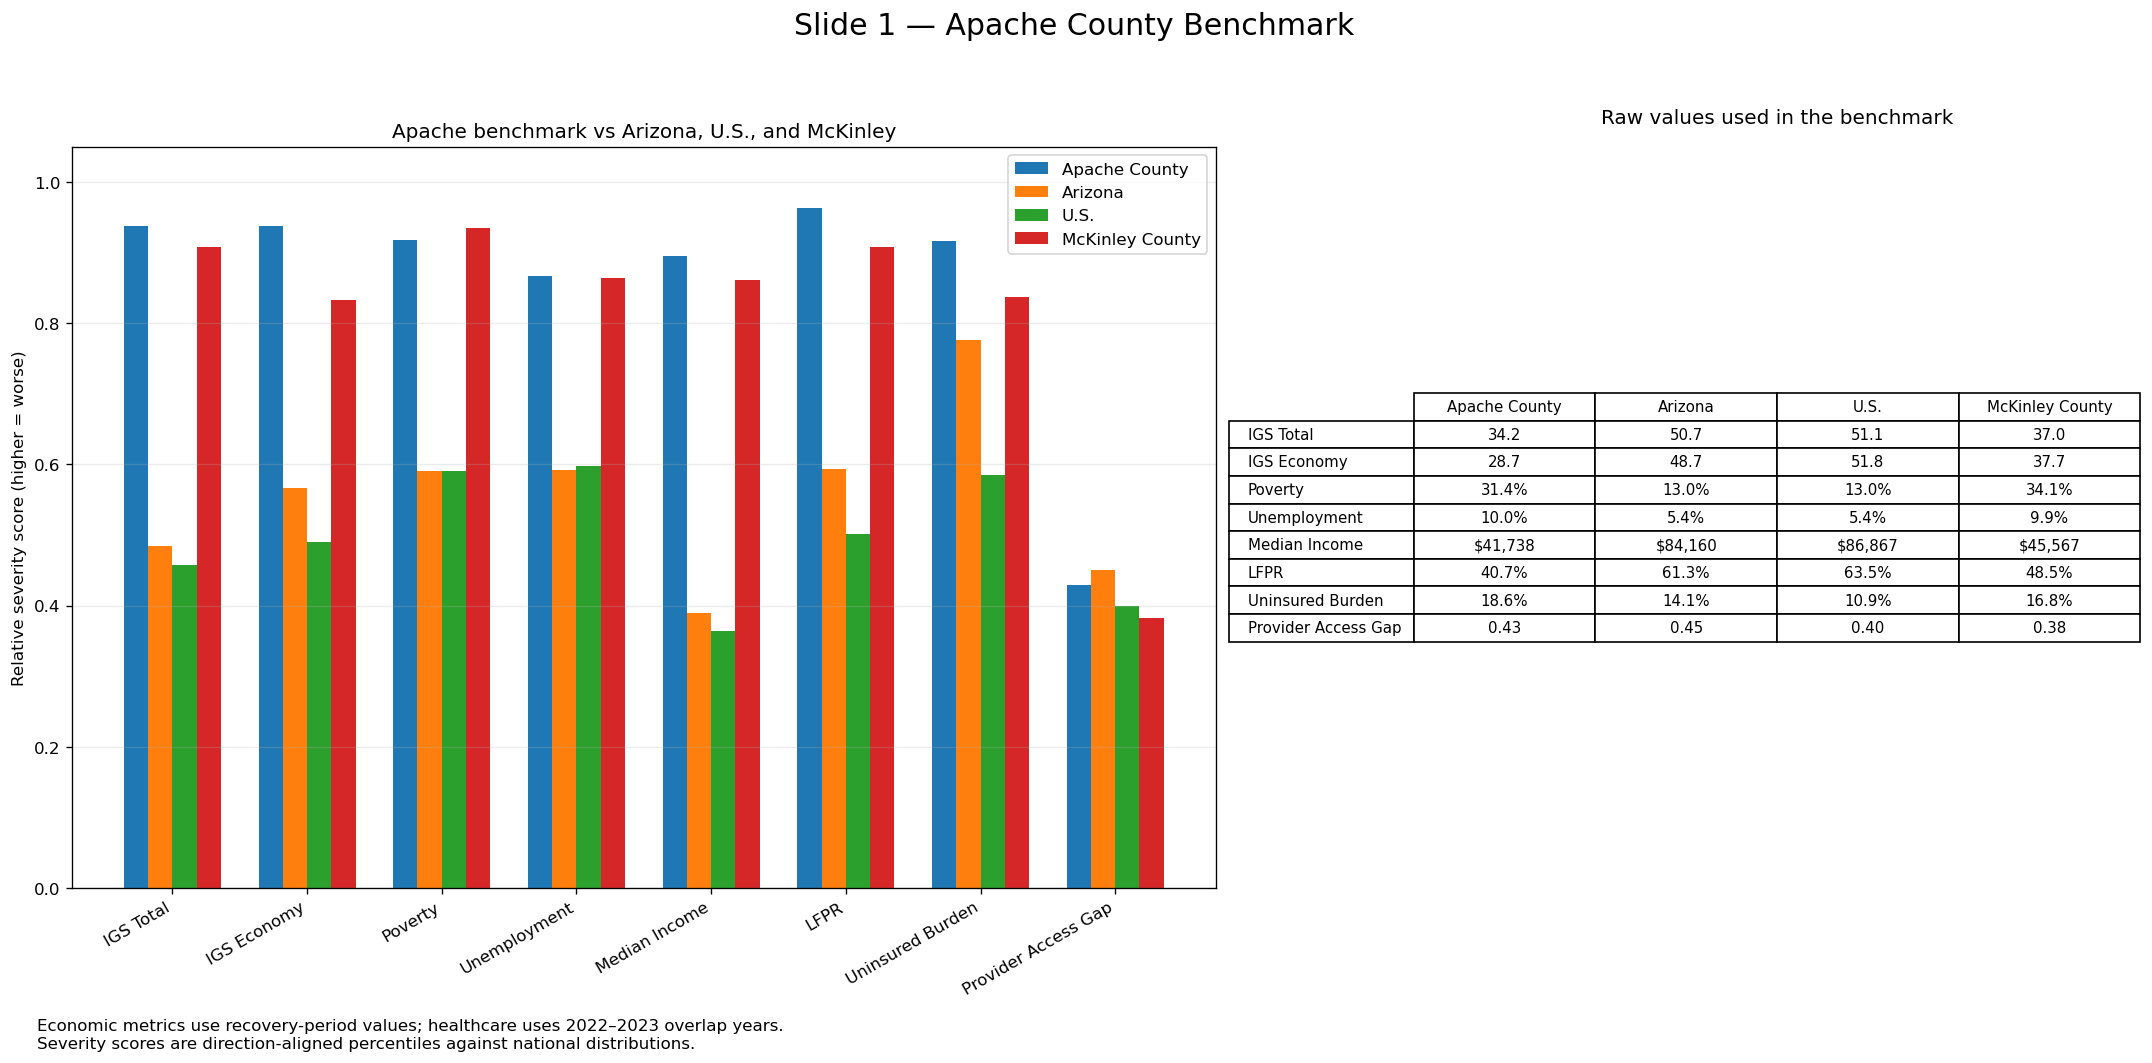

In [199]:
# ============================================================
# 1) APACHE-SPECIFIC BENCHMARK SLIDE
# Apache vs Arizona vs U.S. vs McKinley
# ============================================================

# -----------------------------
# A. Recovery-period economic raw values
# -----------------------------
econ_metric_map = {
    "igs_total_recovery": "IGS Total",
    "igs_economy_recovery": "IGS Economy",
    "poverty_rate_recovery": "Poverty",
    "unemp_rate_recovery": "Unemployment",
    "median_household_income_recovery": "Median Income",
    "lfpr_16p_recovery": "LFPR",
}

recovery_panel = analysis_panel.loc[analysis_panel["analysis_period"] == "recovery"].copy()
az_recovery = recovery_panel.loc[recovery_panel["state_fips"] == "04"].copy()

apache_econ_raw = pd.Series({
    "IGS Total": apache_row["igs_total_recovery"],
    "IGS Economy": apache_row["igs_economy_recovery"],
    "Poverty": apache_row["poverty_rate_recovery"],
    "Unemployment": apache_row["unemp_rate_recovery"],
    "Median Income": apache_row["median_household_income_recovery"],
    "LFPR": apache_row["lfpr_16p_recovery"],
})

mck_econ_raw = pd.Series({
    "IGS Total": mck_row["igs_total_recovery"],
    "IGS Economy": mck_row["igs_economy_recovery"],
    "Poverty": mck_row["poverty_rate_recovery"],
    "Unemployment": mck_row["unemp_rate_recovery"],
    "Median Income": mck_row["median_household_income_recovery"],
    "LFPR": mck_row["lfpr_16p_recovery"],
})

az_econ_raw = pd.Series({
    "IGS Total": weighted_avg(az_recovery, "igs_total"),
    "IGS Economy": weighted_avg(az_recovery, "igs_economy"),
    "Poverty": weighted_avg(az_recovery, "poverty_rate"),
    "Unemployment": weighted_avg(az_recovery, "unemp_rate"),
    "Median Income": weighted_avg(az_recovery, "median_household_income"),
    "LFPR": weighted_avg(az_recovery, "lfpr_16p"),
})

us_econ_raw = pd.Series({
    "IGS Total": weighted_avg(recovery_panel, "igs_total"),
    "IGS Economy": weighted_avg(recovery_panel, "igs_economy"),
    "Poverty": weighted_avg(recovery_panel, "poverty_rate"),
    "Unemployment": weighted_avg(recovery_panel, "unemp_rate"),
    "Median Income": weighted_avg(recovery_panel, "median_household_income"),
    "LFPR": weighted_avg(recovery_panel, "lfpr_16p"),
})

# -----------------------------
# B. Healthcare benchmark raw values
# 2022–2023 overlap years only
# -----------------------------
health_bench = healthcare_standardized.loc[
    healthcare_standardized["year"].isin([2022, 2023])
].copy()

apache_chr = health_bench.loc[health_bench["county_fips"] == "04001"].copy()
mck_chr = health_bench.loc[health_bench["county_fips"] == "35031"].copy()
az_chr = health_bench.loc[health_bench["state_fips"] == "04"].copy()
us_chr = health_bench.copy()

def uninsured_burden_raw(df):
    return mean_of_cols(df, uninsured_cols)

def provider_access_gap_index(df, ref_df):
    scores = []
    for col in provider_cols:
        v = mean_of_cols(df, [col])
        scores.append(percentile_of_value(ref_df[col], v, high_is_bad=False))
    return float(np.nanmean(scores))

apache_health_raw = pd.Series({
    "Uninsured Burden": uninsured_burden_raw(apache_chr),
    "Provider Access Gap": provider_access_gap_index(apache_chr, health_bench),
})

mck_health_raw = pd.Series({
    "Uninsured Burden": uninsured_burden_raw(mck_chr),
    "Provider Access Gap": provider_access_gap_index(mck_chr, health_bench),
})

az_health_raw = pd.Series({
    "Uninsured Burden": uninsured_burden_raw(az_chr),
    "Provider Access Gap": provider_access_gap_index(az_chr, health_bench),
})

us_health_raw = pd.Series({
    "Uninsured Burden": uninsured_burden_raw(us_chr),
    "Provider Access Gap": provider_access_gap_index(us_chr, health_bench),
})

# -----------------------------
# C. Combined raw benchmark table
# -----------------------------
benchmark_raw = pd.concat(
    [
        pd.concat([apache_econ_raw, apache_health_raw]).rename("Apache County"),
        pd.concat([az_econ_raw, az_health_raw]).rename("Arizona"),
        pd.concat([us_econ_raw, us_health_raw]).rename("U.S."),
        pd.concat([mck_econ_raw, mck_health_raw]).rename("McKinley County"),
    ],
    axis=1,
)

# -----------------------------
# D. Severity-score benchmark (higher = worse)
# Uses national distributions as reference
# -----------------------------
benchmark_scores = pd.DataFrame(index=benchmark_raw.index)

for group_name, raw_series in benchmark_raw.items():
    out = {}
    out["IGS Total"] = percentile_of_value(recovery_panel["igs_total"], raw_series["IGS Total"], high_is_bad=False)
    out["IGS Economy"] = percentile_of_value(recovery_panel["igs_economy"], raw_series["IGS Economy"], high_is_bad=False)
    out["Poverty"] = percentile_of_value(recovery_panel["poverty_rate"], raw_series["Poverty"], high_is_bad=True)
    out["Unemployment"] = percentile_of_value(recovery_panel["unemp_rate"], raw_series["Unemployment"], high_is_bad=True)
    out["Median Income"] = percentile_of_value(recovery_panel["median_household_income"], raw_series["Median Income"], high_is_bad=False)
    out["LFPR"] = percentile_of_value(recovery_panel["lfpr_16p"], raw_series["LFPR"], high_is_bad=False)

    if group_name == "Apache County":
        src = apache_chr
    elif group_name == "Arizona":
        src = az_chr
    elif group_name == "U.S.":
        src = us_chr
    else:
        src = mck_chr

    uninsured_parts = []
    for col in uninsured_cols:
        uninsured_parts.append(
            percentile_of_value(health_bench[col], mean_of_cols(src, [col]), high_is_bad=True)
        )
    out["Uninsured Burden"] = float(np.nanmean(uninsured_parts))

    provider_parts = []
    for col in provider_cols:
        provider_parts.append(
            percentile_of_value(health_bench[col], mean_of_cols(src, [col]), high_is_bad=False)
        )
    out["Provider Access Gap"] = float(np.nanmean(provider_parts))

    benchmark_scores[group_name] = pd.Series(out)

# -----------------------------
# E. Pretty formatting
# -----------------------------
def fmt_metric(metric, v):
    if pd.isna(v):
        return "NA"
    if metric in ["Poverty", "Unemployment", "LFPR", "Uninsured Burden"]:
        return f"{100*v:.1f}%"
    if metric == "Median Income":
        return f"${v:,.0f}"
    if metric == "Provider Access Gap":
        return f"{v:.2f}"
    return f"{v:.1f}"

benchmark_raw_fmt = benchmark_raw.copy()
for r in benchmark_raw_fmt.index:
    for c in benchmark_raw_fmt.columns:
        benchmark_raw_fmt.loc[r, c] = fmt_metric(r, benchmark_raw_fmt.loc[r, c])

# -----------------------------
# F. Plot (VERTICAL VERSION)
# -----------------------------
plot_df = benchmark_scores.loc[
    [
        "IGS Total", "IGS Economy", "Poverty", "Unemployment",
        "Median Income", "LFPR", "Uninsured Burden", "Provider Access Gap"
    ]
].copy()

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(18, 9),
    gridspec_kw={"width_ratios": [1.7, 1.0]}
)

# left: grouped vertical bars
groups = ["Apache County", "Arizona", "U.S.", "McKinley County"]
x = np.arange(len(plot_df.index))
bar_w = 0.18
offsets = np.array([-1.5, -0.5, 0.5, 1.5]) * bar_w

for i, g in enumerate(groups):
    ax1.bar(x + offsets[i], plot_df[g].values, width=bar_w, label=g)

ax1.set_xticks(x)
ax1.set_xticklabels(plot_df.index, rotation=30, ha="right")
ax1.set_ylim(0, 1.05)
ax1.set_ylabel("Relative severity score (higher = worse)")
ax1.set_title("Apache benchmark vs Arizona, U.S., and McKinley")
ax1.grid(axis="y", alpha=0.25)
ax1.legend(loc="upper right", frameon=True)

# right: raw-value table
ax2.axis("off")
tbl = ax2.table(
    cellText=benchmark_raw_fmt.values,
    rowLabels=benchmark_raw_fmt.index,
    colLabels=benchmark_raw_fmt.columns,
    loc="center",
    cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.08, 1.55)
ax2.set_title("Raw values used in the benchmark", pad=14)

fig.suptitle("Slide 1 — Apache County Benchmark", fontsize=18, y=0.98)
fig.text(
    0.02, 0.02,
    "Economic metrics use recovery-period values; healthcare uses 2022–2023 overlap years.\n"
    "Severity scores are direction-aligned percentiles against national distributions.",
    fontsize=10
)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

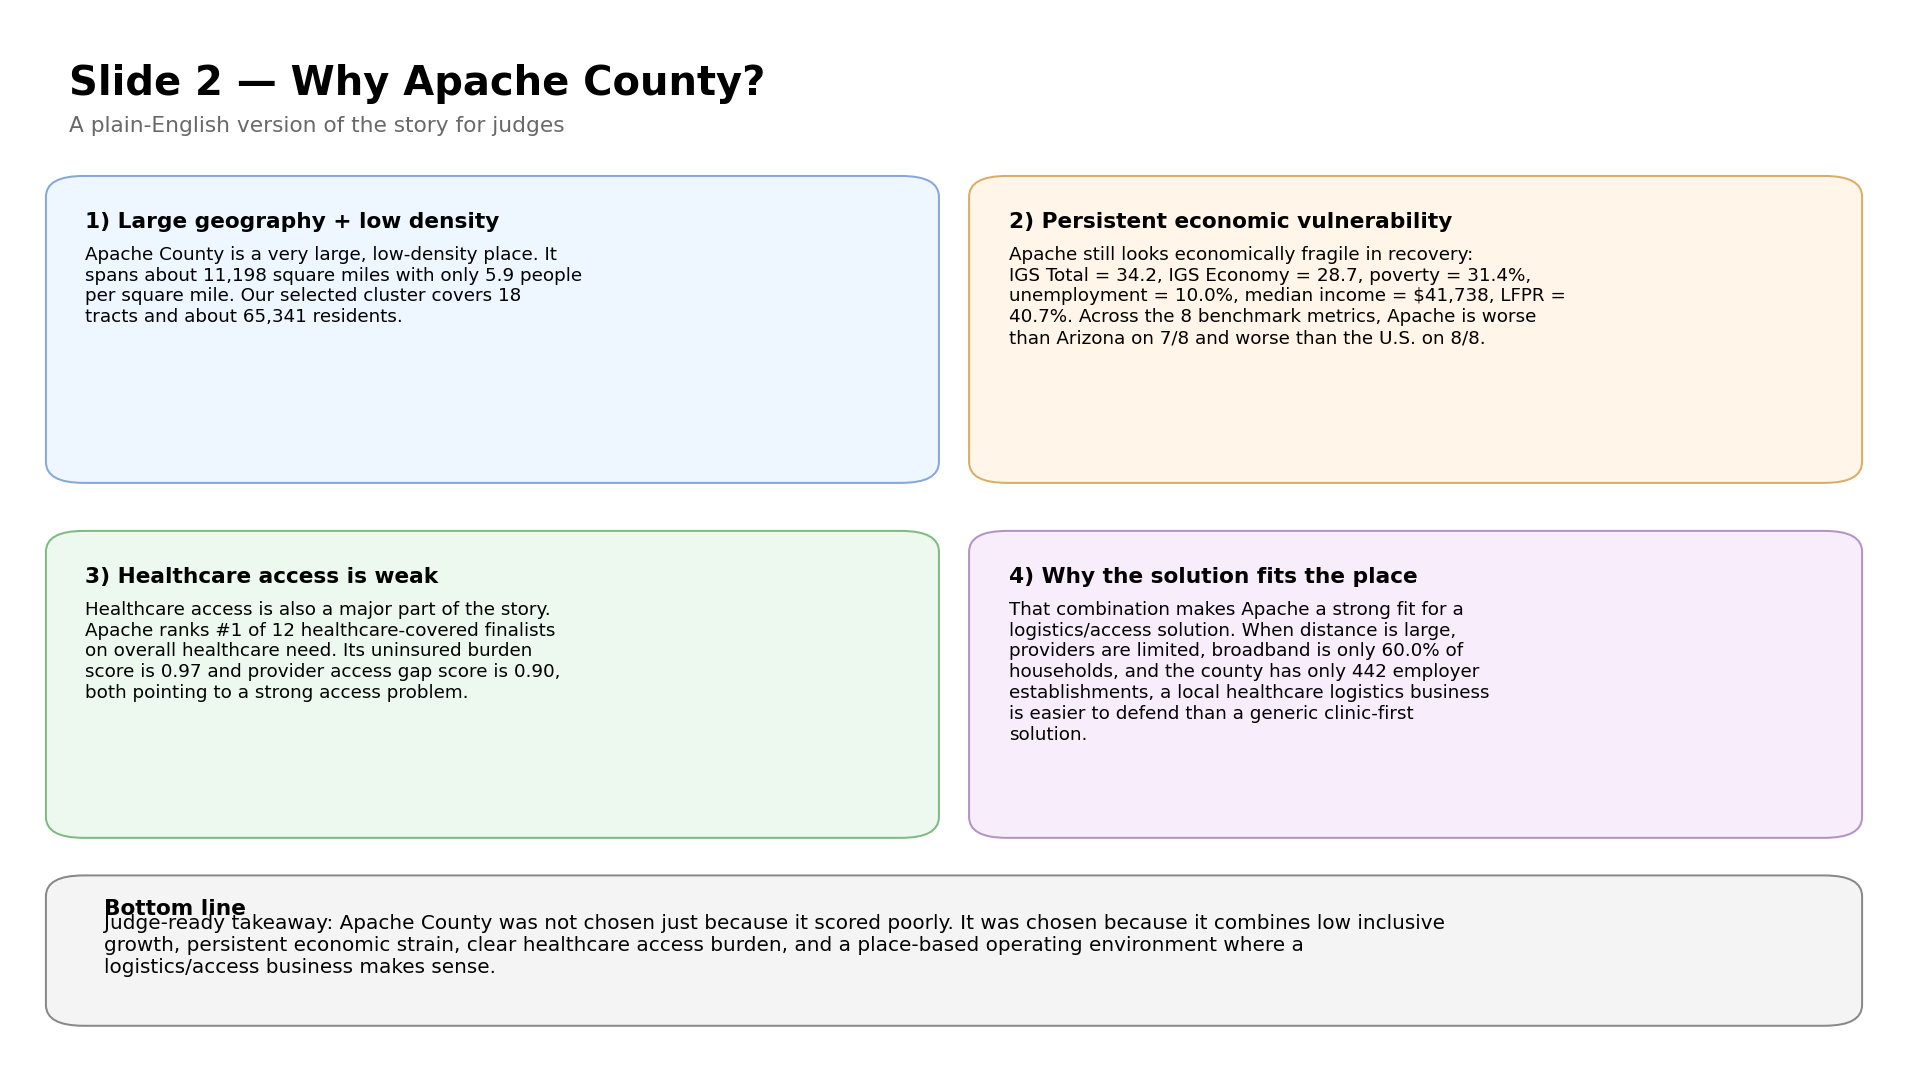

Saved:
- data\processed\presentation_ready\slide_02_why_apache_story.png


In [200]:
# ============================================================
# 2) CLEAN "WHY APACHE?" STORY SLIDE
# Plain-English, judge-facing summary
# ============================================================

if "benchmark_scores" not in globals():
    raise RuntimeError("Run the benchmark cell first.")

# -----------------------------
# A. Useful story signals
# -----------------------------
apache_vs_az_worse = int((benchmark_scores["Apache County"] > benchmark_scores["Arizona"]).sum())
apache_vs_us_worse = int((benchmark_scores["Apache County"] > benchmark_scores["U.S."]).sum())

health_rank = healthcare_cluster_scored["healthcare_need_score"].rank(ascending=False, method="min")
apache_health_rank = int(
    health_rank.loc[healthcare_cluster_scored["cluster_id"] == APACHE_CLUSTER_ID].iloc[0]
)
n_healthcare_finalists = int(len(healthcare_cluster_scored))

geo_text = (
    f"Apache County is a very large, low-density place. "
    f"It spans about {PLACE_CONTEXT['land_area_sq_miles']:,.0f} square miles "
    f"with only {PLACE_CONTEXT['population_density_2020']:.1f} people per square mile. "
    f"Our selected cluster covers {int(apache_row['n_cluster_tracts'])} tracts "
    f"and about {int(apache_row['latest_cluster_pop_total']):,} residents."
)

econ_text = (
    f"Apache still looks economically fragile in recovery: "
    f"IGS Total = {apache_row['igs_total_recovery']:.1f}, "
    f"IGS Economy = {apache_row['igs_economy_recovery']:.1f}, "
    f"poverty = {apache_row['poverty_rate_recovery']:.1%}, "
    f"unemployment = {apache_row['unemp_rate_recovery']:.1%}, "
    f"median income = ${apache_row['median_household_income_recovery']:,.0f}, "
    f"LFPR = {apache_row['lfpr_16p_recovery']:.1%}. "
    f"Across the 8 benchmark metrics, Apache is worse than Arizona on "
    f"{apache_vs_az_worse}/8 and worse than the U.S. on {apache_vs_us_worse}/8."
)

health_text = (
    f"Healthcare access is also a major part of the story. "
    f"Apache ranks #{apache_health_rank} of {n_healthcare_finalists} healthcare-covered finalists "
    f"on overall healthcare need. Its uninsured burden score is "
    f"{apache_health['uninsured_burden_score']:.2f} and provider access gap score is "
    f"{apache_health['provider_access_gap_score']:.2f}, both pointing to a strong access problem."
)

fit_text = (
    f"That combination makes Apache a strong fit for a logistics/access solution. "
    f"When distance is large, providers are limited, broadband is only "
    f"{PLACE_CONTEXT['broadband_subscription_pct']:.1f}% of households, "
    f"and the county has only {PLACE_CONTEXT['employer_establishments_2023']:,} employer establishments, "
    f"a local healthcare logistics business is easier to defend than a generic clinic-first solution."
)

# -----------------------------
# B. Plot story slide
# -----------------------------
fig, ax = plt.subplots(figsize=(16, 9))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

ax.text(0.03, 0.95, "Slide 2 — Why Apache County?", fontsize=24, weight="bold", va="top")
ax.text(
    0.03, 0.90,
    "A plain-English version of the story for judges",
    fontsize=13, color="dimgray", va="top"
)

draw_box(
    ax, 0.03, 0.56, 0.45, 0.27,
    "1) Large geography + low density",
    wrap(geo_text, 52),
    face="#eef6ff", edge="#86a8d8"
)

draw_box(
    ax, 0.52, 0.56, 0.45, 0.27,
    "2) Persistent economic vulnerability",
    wrap(econ_text, 54),
    face="#fff5e8", edge="#d9ad65"
)

draw_box(
    ax, 0.03, 0.22, 0.45, 0.27,
    "3) Healthcare access is weak",
    wrap(health_text, 52),
    face="#edf9ef", edge="#7dbb83"
)

draw_box(
    ax, 0.52, 0.22, 0.45, 0.27,
    "4) Why the solution fits the place",
    wrap(fit_text, 54),
    face="#f8eefb", edge="#b392c6"
)

bottom_callout = (
    "Judge-ready takeaway:\n"
    "Apache County was not chosen just because it scored poorly. "
    "It was chosen because it combines low inclusive growth, persistent economic strain, "
    "clear healthcare access burden, and a place-based operating environment where a logistics/access business makes sense."
)

draw_box(
    ax, 0.03, 0.04, 0.94, 0.12,
    "Bottom line",
    wrap(bottom_callout, 130),
    face="#f4f4f4", edge="#888888", body_fs=12
)

plt.tight_layout()
plt.show()

fig.savefig(OUT_DIR / "slide_02_why_apache_story.png", bbox_inches="tight")
print("Saved:")
print("-", OUT_DIR / "slide_02_why_apache_story.png")

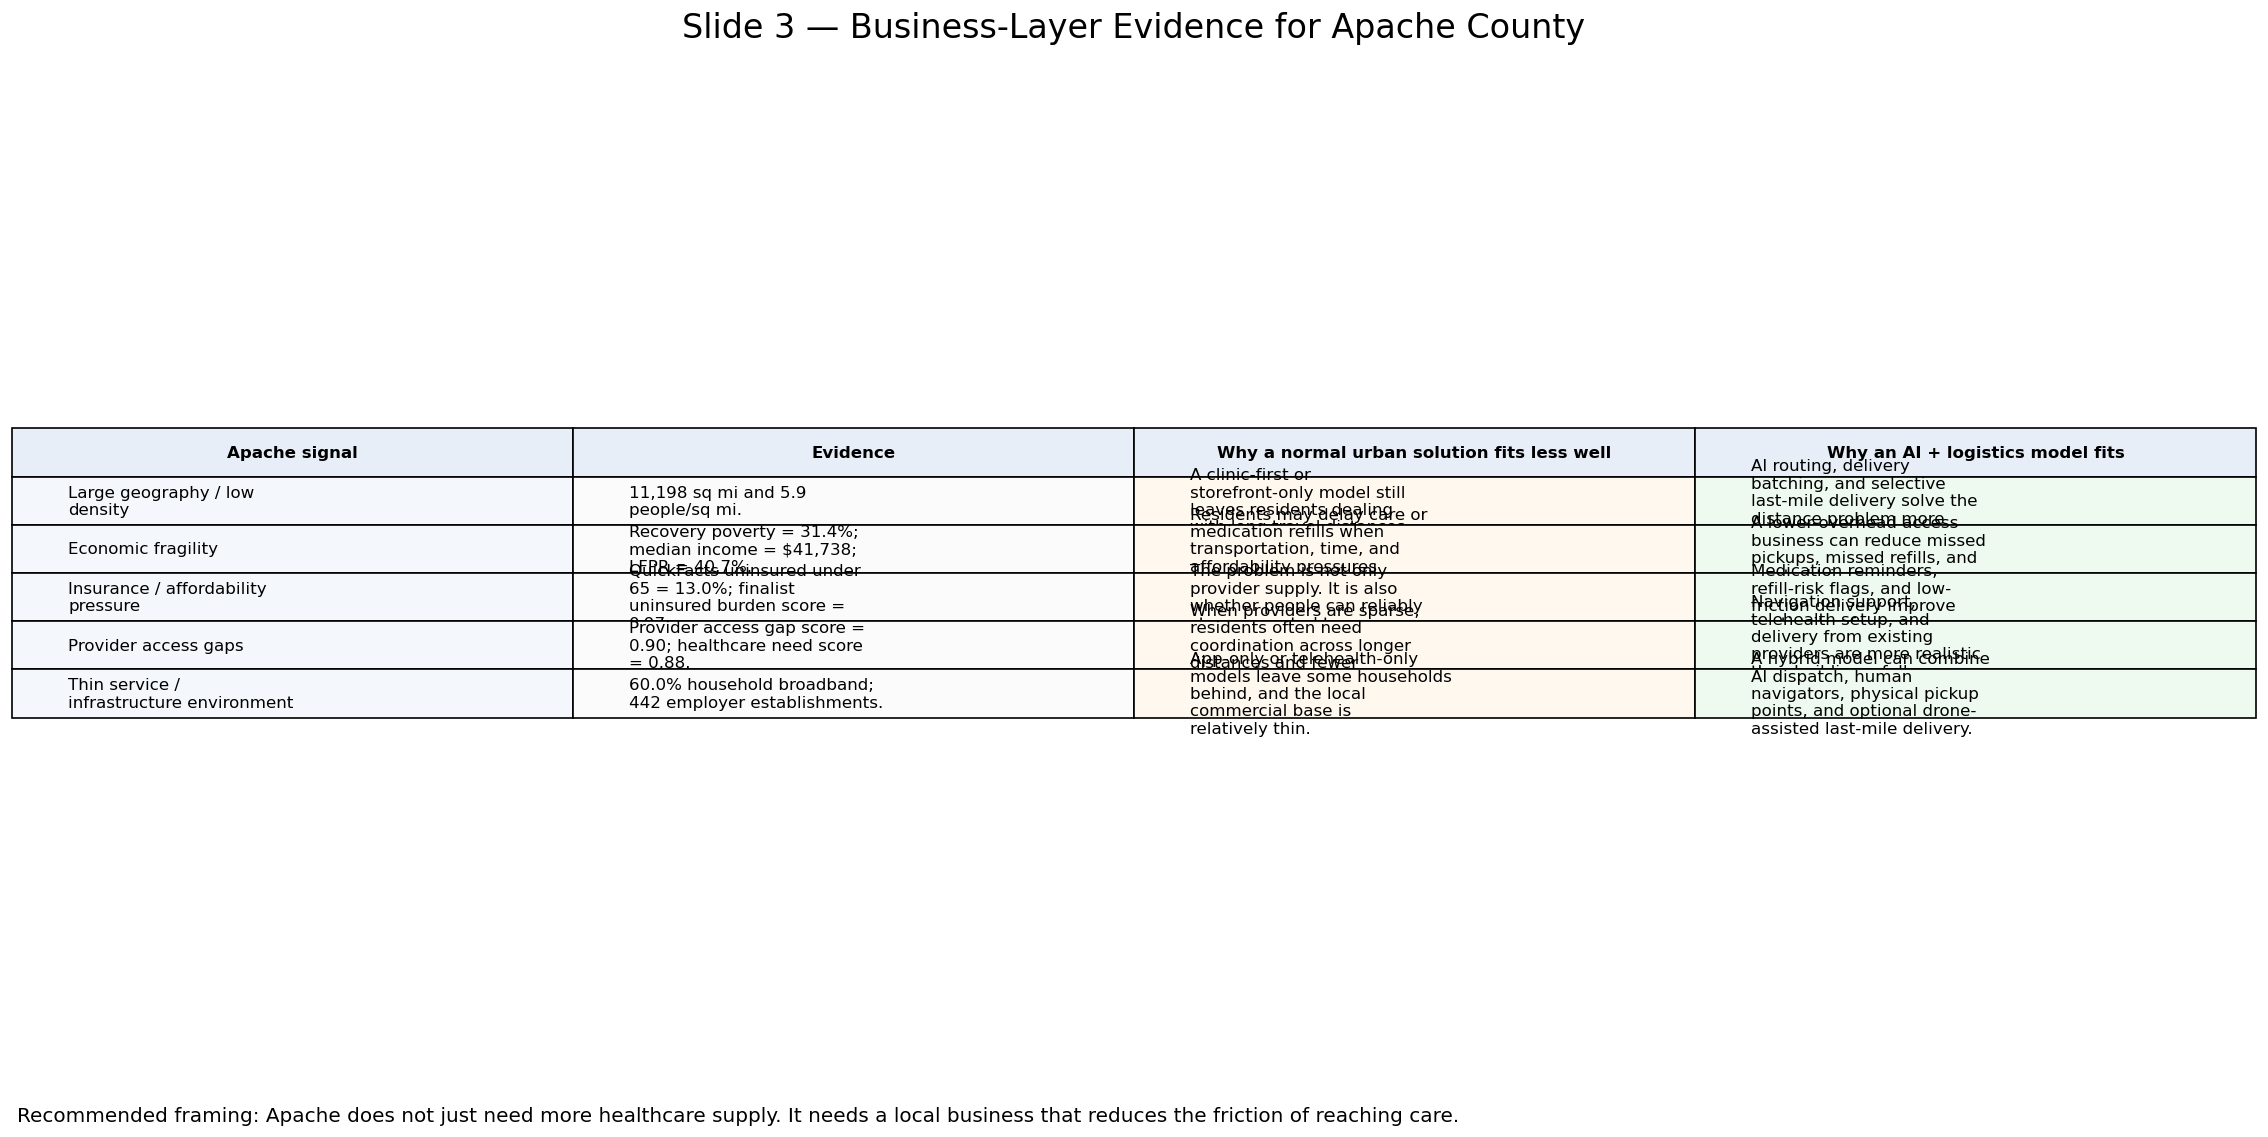

Saved:
- data\processed\presentation_ready\apache_business_layer_evidence.csv
- data\processed\presentation_ready\slide_03_business_layer_evidence.png


In [197]:
# ============================================================
# 3) BUSINESS-LAYER EVIDENCE SLIDE
# Why AI + rural healthcare logistics / drone-assisted delivery fits Apache
# ============================================================

# -----------------------------
# A. Build evidence rows
# -----------------------------
biz_evidence_df = pd.DataFrame([
    {
        "Apache signal": "Large geography / low density",
        "Evidence": (
            f"{PLACE_CONTEXT['land_area_sq_miles']:,.0f} sq mi and "
            f"{PLACE_CONTEXT['population_density_2020']:.1f} people/sq mi."
        ),
        "Why a normal urban solution fits less well": (
            "A clinic-first or storefront-only model still leaves residents dealing with long travel distances."
        ),
        "Why an AI + logistics model fits": (
            "AI routing, delivery batching, and selective last-mile delivery solve the distance problem more directly."
        ),
    },
    {
        "Apache signal": "Economic fragility",
        "Evidence": (
            f"Recovery poverty = {apache_row['poverty_rate_recovery']:.1%}; "
            f"median income = ${apache_row['median_household_income_recovery']:,.0f}; "
            f"LFPR = {apache_row['lfpr_16p_recovery']:.1%}."
        ),
        "Why a normal urban solution fits less well": (
            "Residents may delay care or medication refills when transportation, time, and affordability pressures stack up."
        ),
        "Why an AI + logistics model fits": (
            "A lower-overhead access business can reduce missed pickups, missed refills, and wasted trips."
        ),
    },
    {
        "Apache signal": "Insurance / affordability pressure",
        "Evidence": (
            f"QuickFacts uninsured under 65 = {PLACE_CONTEXT['under65_uninsured_pct']:.1f}%; "
            f"finalist uninsured burden score = {apache_health['uninsured_burden_score']:.2f}."
        ),
        "Why a normal urban solution fits less well": (
            "The problem is not only provider supply. It is also whether people can reliably stay connected to care."
        ),
        "Why an AI + logistics model fits": (
            "Medication reminders, refill-risk flags, and low-friction delivery improve continuity of care."
        ),
    },
    {
        "Apache signal": "Provider access gaps",
        "Evidence": (
            f"Provider access gap score = {apache_health['provider_access_gap_score']:.2f}; "
            f"healthcare need score = {apache_health['healthcare_need_score']:.2f}."
        ),
        "Why a normal urban solution fits less well": (
            "When providers are sparse, residents often need coordination across longer distances and fewer touchpoints."
        ),
        "Why an AI + logistics model fits": (
            "Navigation support, telehealth setup, and delivery from existing providers are more realistic than building a full new care network."
        ),
    },
    {
        "Apache signal": "Thin service / infrastructure environment",
        "Evidence": (
            f"{PLACE_CONTEXT['broadband_subscription_pct']:.1f}% household broadband; "
            f"{PLACE_CONTEXT['employer_establishments_2023']:,} employer establishments."
        ),
        "Why a normal urban solution fits less well": (
            "App-only or telehealth-only models leave some households behind, and the local commercial base is relatively thin."
        ),
        "Why an AI + logistics model fits": (
            "A hybrid model can combine AI dispatch, human navigators, physical pickup points, and optional drone-assisted last-mile delivery."
        ),
    },
])

# Wrap text for display
display_df = biz_evidence_df.copy()
for col in display_df.columns:
    display_df[col] = display_df[col].map(lambda x: wrap(x, 28))

# -----------------------------
# B. Plot as a judge-facing evidence table
# -----------------------------
fig, ax = plt.subplots(figsize=(19, 10))
ax.axis("off")
ax.set_title(
    "Slide 3 — Business-Layer Evidence for Apache County",
    fontsize=20, pad=18
)

tbl = ax.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    loc="center",
    cellLoc="left",
    colLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.0, 2.2)

# Header styling
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#e8eef7")
    else:
        if c == 0:
            cell.set_facecolor("#f4f8fc")
        elif c == 1:
            cell.set_facecolor("#fbfbfb")
        elif c == 2:
            cell.set_facecolor("#fff8ef")
        elif c == 3:
            cell.set_facecolor("#eef9f0")

fig.text(
    0.01, 0.02,
    "Recommended framing: Apache does not just need more healthcare supply. "
    "It needs a local business that reduces the friction of reaching care.",
    fontsize=12
)

plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.show()

biz_evidence_df.to_csv(OUT_DIR / "apache_business_layer_evidence.csv", index=False)
fig.savefig(OUT_DIR / "slide_03_business_layer_evidence.png", bbox_inches="tight")

print("Saved:")
print("-", OUT_DIR / "apache_business_layer_evidence.csv")
print("-", OUT_DIR / "slide_03_business_layer_evidence.png")

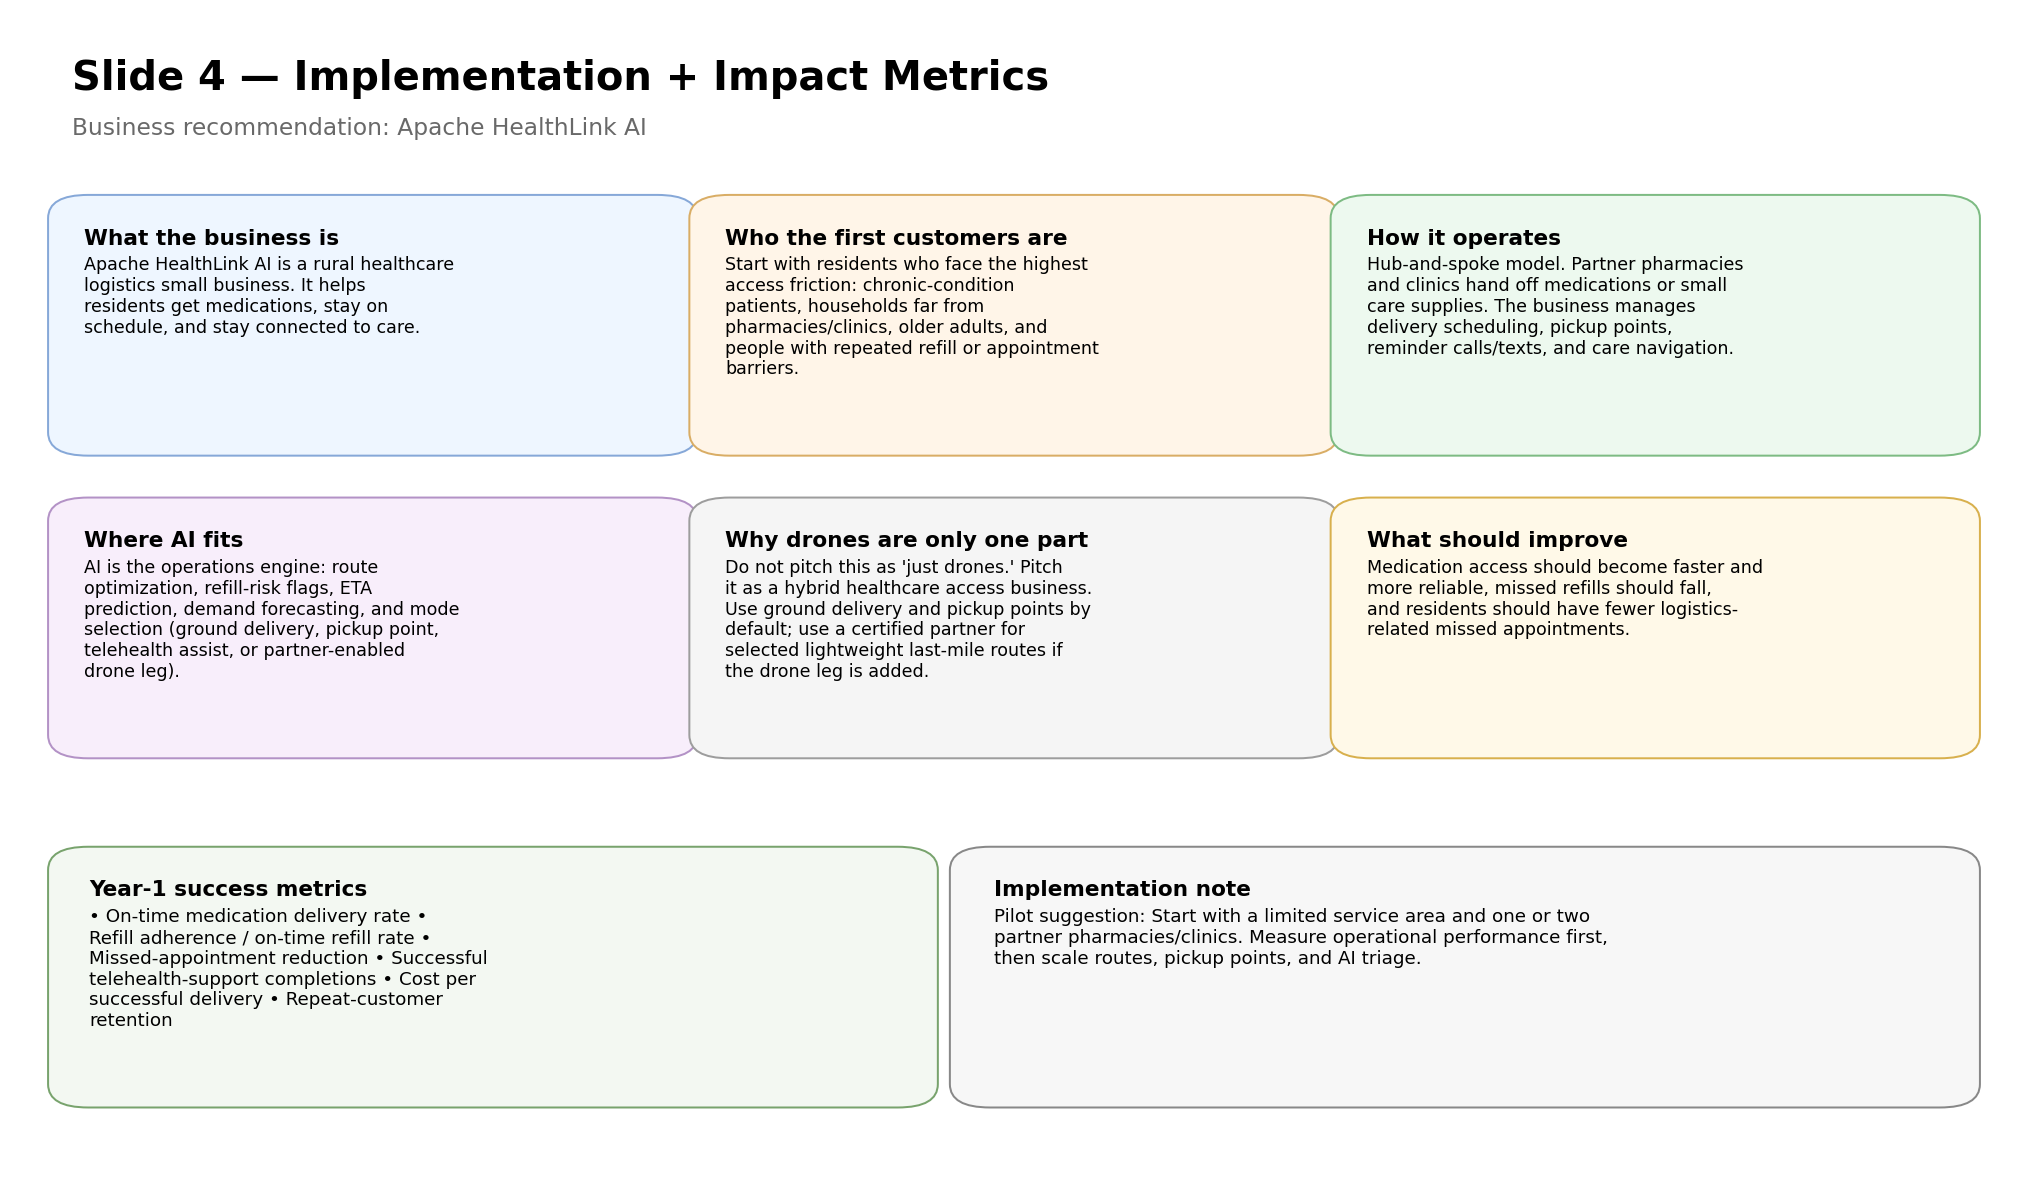

Saved:
- data\processed\presentation_ready\apache_business_kpis.csv
- data\processed\presentation_ready\slide_04_implementation_and_metrics.png


In [198]:
# ============================================================
# 4) IMPLEMENTATION + IMPACT METRICS SLIDE
# What the business is, who it serves, how it works, AI role, KPIs
# ============================================================

BUSINESS_NAME = "Apache HealthLink AI"

slide_sections = {
    "What the business is": (
        f"{BUSINESS_NAME} is a rural healthcare logistics small business. "
        f"It helps residents get medications, stay on schedule, and stay connected to care."
    ),
    "Who the first customers are": (
        "Start with residents who face the highest access friction: "
        "chronic-condition patients, households far from pharmacies/clinics, older adults, "
        "and people with repeated refill or appointment barriers."
    ),
    "How it operates": (
        "Hub-and-spoke model. Partner pharmacies and clinics hand off medications or small care supplies. "
        "The business manages delivery scheduling, pickup points, reminder calls/texts, and care navigation."
    ),
    "Where AI fits": (
        "AI is the operations engine: route optimization, refill-risk flags, ETA prediction, demand forecasting, "
        "and mode selection (ground delivery, pickup point, telehealth assist, or partner-enabled drone leg)."
    ),
    "Why drones are only one part": (
        "Do not pitch this as 'just drones.' Pitch it as a hybrid healthcare access business. "
        "Use ground delivery and pickup points by default; use a certified partner for selected lightweight last-mile routes if the drone leg is added."
    ),
    "What should improve": (
        "Medication access should become faster and more reliable, missed refills should fall, "
        "and residents should have fewer logistics-related missed appointments."
    ),
}

kpis = pd.DataFrame({
    "Metric": [
        "On-time medication delivery rate",
        "Refill adherence / on-time refill rate",
        "Missed-appointment reduction",
        "Successful telehealth-support completions",
        "Cost per successful delivery",
        "Repeat-customer retention",
    ],
    "How to measure it": [
        "Completed on schedule / total scheduled deliveries",
        "Share of targeted refills delivered or picked up on time",
        "Before-vs-after comparison for customers enrolled in the service",
        "Completed assisted telehealth visits / scheduled assisted visits",
        "Total operating cost / completed deliveries",
        "Share of customers using the service again within 90 days",
    ]
})

# -----------------------------
# Plot slide
# -----------------------------
fig, ax = plt.subplots(figsize=(17, 10))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

ax.text(0.03, 0.96, "Slide 4 — Implementation + Impact Metrics", fontsize=24, weight="bold", va="top")
ax.text(0.03, 0.91, f"Business recommendation: {BUSINESS_NAME}", fontsize=14, color="dimgray", va="top")

# 2 x 3 grid of boxes
positions = [
    (0.03, 0.63, 0.30, 0.20, "What the business is"),
    (0.35, 0.63, 0.30, 0.20, "Who the first customers are"),
    (0.67, 0.63, 0.30, 0.20, "How it operates"),
    (0.03, 0.37, 0.30, 0.20, "Where AI fits"),
    (0.35, 0.37, 0.30, 0.20, "Why drones are only one part"),
    (0.67, 0.37, 0.30, 0.20, "What should improve"),
]

box_colors = ["#eef6ff", "#fff5e8", "#edf9ef", "#f8eefb", "#f5f5f5", "#fff9e8"]
box_edges = ["#86a8d8", "#d9ad65", "#7dbb83", "#b392c6", "#9d9d9d", "#d8b04d"]

for i, (x, y, w, h, key) in enumerate(positions):
    draw_box(
        ax, x, y, w, h,
        key,
        wrap(slide_sections[key], 42),
        face=box_colors[i],
        edge=box_edges[i],
        body_fs=10.5
    )

# KPI box
kpi_text = "\n".join(
    [f"• {m}" for m in kpis["Metric"].tolist()]
)
draw_box(
    ax, 0.03, 0.07, 0.42, 0.20,
    "Year-1 success metrics",
    wrap(kpi_text, 42),
    face="#f3f8f2", edge="#78a36d", body_fs=11
)

impact_text = (
    "Pilot suggestion:\n"
    "Start with a limited service area and one or two partner pharmacies/clinics.\n"
    "Measure operational performance first, then scale routes, pickup points, and AI triage."
)
draw_box(
    ax, 0.48, 0.07, 0.49, 0.20,
    "Implementation note",
    wrap(impact_text, 70),
    face="#f7f7f7", edge="#888888", body_fs=11
)

plt.tight_layout()
plt.show()

kpis.to_csv(OUT_DIR / "apache_business_kpis.csv", index=False)
fig.savefig(OUT_DIR / "slide_04_implementation_and_metrics.png", bbox_inches="tight")

print("Saved:")
print("-", OUT_DIR / "apache_business_kpis.csv")
print("-", OUT_DIR / "slide_04_implementation_and_metrics.png")